In [1]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from importlib import reload
from astropy.coordinates import SkyCoord
import seaborn as sns
from copy import copy

import corner
import legwork as lw
import gala.potential as gp
import cogsworth

import sys
sys.path.append("../helpers")

import detections
import const
import plotting
import uncertainties as unc

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

%config InlineBackend.figure_format = 'retina'

# Load data

In [2]:
pops = {
    dco_type: cogsworth.pop.load(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/{dco_type}_pessimistic_in_band.h5") for dco_type in const.DCO_TYPES
}

In [3]:
detectable_pops = {}
for dco_type in const.DCO_TYPES:
    pop = pops[dco_type]
    print(dco_type)
    pop.final_pos, pop.final_vel
    
    mask = (
        (pops[dco_type].bpp["snr_lisa_8yr_final_pos"] > 12)
        | (pops[dco_type].bpp["snr_lisa_8yr_initial_pos"] > 12)
        | (pops[dco_type].bpp["snr_decigo_8yr_final_pos"] > 12)
        | (pops[dco_type].bpp["snr_decigo_8yr_initial_pos"] > 12)
    )
    detectable_pops[dco_type] = pops[dco_type][mask]

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


BHBH


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


BHNS


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


BHWD


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


NSNS


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


NSWD


In [4]:
lisa_pops = {dco_type: pops[dco_type][pops[dco_type].bpp["snr_lisa_8yr_final_pos"] > 12] for dco_type in const.DCO_TYPES}

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If y

In [5]:
detectable_sources = {}
for dco_type in const.DCO_TYPES:
    print(dco_type)
    path = f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/{dco_type}_pessimistic_detectable_sources.h5"
    if os.path.isfile(path):
        detectable_sources[dco_type] = lw.source.Source.from_file(path)
    else:
        # turn them into a LEGWORK source class
        detectable_sources[dco_type] = detectable_pops[dco_type].to_legwork_sources(assume_mw_galactocentric=True)
        detectable_sources[dco_type].n_proc = 30

        # find those that haven't reached RLOF yet evolve them via GWs until present day
        if "rlof_time" not in detectable_pops[dco_type].bpp.columns:
             detectable_pops[dco_type].bpp["rlof_time"] = 1e20

        reached_rlof = detectable_pops[dco_type].initial_galaxy.tau > detectable_pops[dco_type].bpp["rlof_time"].values * u.Myr

        non_rlof_sources = detectable_sources[dco_type][~reached_rlof]
        non_rlof_sources.evolve_sources(t_evol=detectable_pops[dco_type].initial_galaxy.tau[~reached_rlof] - detectable_pops[dco_type].bpp["tphys"].values[~reached_rlof] * u.Myr)

        # recombine into a single source class
        detectable_sources[dco_type].m_1[~reached_rlof] = non_rlof_sources.m_1
        detectable_sources[dco_type].m_2[~reached_rlof] = non_rlof_sources.m_2
        detectable_sources[dco_type].dist[~reached_rlof] = non_rlof_sources.dist
        detectable_sources[dco_type].ecc[~reached_rlof] = non_rlof_sources.ecc
        detectable_sources[dco_type].f_orb[~reached_rlof] = non_rlof_sources.f_orb
        detectable_sources[dco_type].merged[~reached_rlof] = non_rlof_sources.merged

        detectable_sources[dco_type].save(path, overwrite=True)

BHBH
BHNS
BHWD
NSNS
NSWD


In [6]:
lisa_sources = {dco_type: detectable_sources[dco_type][detectable_pops[dco_type].bpp["snr_lisa_8yr_final_pos"] > 12] for dco_type in const.DCO_TYPES}

In [7]:
wdwd_dist = cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential(version="v2"))
wdwd_dist.sample(500_000)

In [26]:
unc_data = unc.get_unc_data(lisa_sources, lisa_pops, dur=8, snr_lim=12, snr_harm_lim=12)

# Measurement plots

## All together

In [ ]:
reload(plotting)

# counts = {"BHBH": 42, "BHNS": 17, "BHWD": 10, "NSNS": 6, "NSWD": 169}
counts = {"BHBH": 13, "BHNS": 8, "BHWD": 1, "NSNS": 1, "NSWD": 110}
N_BOOT = 20

height_where_exceeds_wdwds = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 11), layout="tight")

_, _, _, _, wdwd_med, _, _ = bootstrap_cdf(
    np.abs(wdwd_dist[wdwd_dist.tau < 100 * u.Gyr].z.value), n_samples=25_000, n_bootstraps=N_BOOT, norm=False,
    colour=const.STAR_COLOUR, fig=fig, ax=axes[1, 1], label="Star formation\n(WDWD)", xlim=(0, 10)
);

for dco_type in const.DCO_TYPES:
    w = lisa_pops[dco_type].bpp["weights"]

    max_measured_forb = lisa_sources[dco_type].f_orb + unc_data[dco_type]["delta_forb"]
    bootstrap_cdf(np.log10(max_measured_forb.value), n_samples=counts[dco_type], n_bootstraps=N_BOOT, n_bins=1000,
                  norm=True, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=axes[0, 0], label=dco_type, xlim=(-4.5, -2),
                  reversed_cdf=False)

    min_measured_mass = lisa_sources[dco_type].m_c - unc_data[dco_type]["delta_m_c_over_m_c"] * lisa_sources[dco_type].m_c
    min_measured_mass[min_measured_mass < 0] = min(abs(min_measured_mass))

    bootstrap_cdf(np.log10(min_measured_mass.value), n_samples=counts[dco_type], n_bootstraps=N_BOOT, n_bins=1000,
                  norm=True, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=axes[0, 1], label=dco_type, xlim=(-1.5, 1.1))
        # bootstrap_cdf(min_measured_mass.value, n_samples=counts[dco_type], n_bootstraps=10000, norm=False, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=ax, label=dco_type, xlim=(0, 12))
        # plt.hist(np.log10(min_measured_mass.value), bins=np.linspace(-2, 1.5, 50), weights=w, histtype="step", lw=2, color=const.DCO_COLOURS[dco_type], label=dco_type, cumulative=True)


    _, _, _, bin_centres, dco_med, _, _ = bootstrap_cdf(
        np.abs(detectable_pops[dco_type].final_pos[:, 2].value), n_samples=counts[dco_type], n_bootstraps=N_BOOT,
        norm=False, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=axes[1, 1], xlim=(0, 10)
    );
    above = bin_centres[dco_med > wdwd_med]
    if len(above) > 0:
        first_crossing = above[0]
        height_where_exceeds_wdwds[dco_type] = first_crossing
        print(f"{dco_type} first crosses WDWD at {first_crossing:1.2f} kpc")

        # ax.axvline(first_crossing, 0.7, 1, color=const.DCO_COLOURS[dco_type], ls="--", lw=1.5)
        axes[1, 1].plot([first_crossing, first_crossing], [dco_med[dco_med > wdwd_med][0], 2e3], color=const.DCO_COLOURS[dco_type], ls="--", lw=2)

    else:
        height_where_exceeds_wdwds[dco_type] = np.inf
        print(f"{dco_type} never crosses WDWD")

axes[0, 0].axvline(np.log10(3e-4), color='k', ls="--", lw=2)
axes[0, 0].axvspan(np.log10(3e-4), -2, color='k', alpha=0.1)
axes[0, 0].set(
    xlim=(-4.5, -2),
    xlabel=r"$f_{\rm orb} + \Delta f_{\rm orb} \, [\rm Hz]$",
    ylabel=r"$N_{\rm LISA, 4yr} (< f_{\rm orb} + \Delta f_{\rm orb})$",
    # ylim=(1, None),
)

axes[1, 1].legend(fontsize=0.65 * fs)
axes[1, 1].set_xlim(0, 10)
axes[1, 1].set_ylim(1e-2, 2e3)

axes[1, 1].xaxis.set_minor_locator(plt.MultipleLocator(0.25))

top_ax = axes[1, 1].secondary_xaxis('top')
top_ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
top_ax.set_xticklabels([])

axes[1, 1].set(
    xlabel="Height above Galactic plane, |z| [kpc]",
    ylabel=r"$N_{\rm LISA, 4yr} (> |z|)$"
)
    
axes[0, 1].set(
    # yscale="linear",
    # ylim=(0, None),
    # ylim=(1e-1, None),
    xlim=(-1.5, 1.1),
    xlabel=r"$\mathcal{M}_c - \Delta \mathcal{M}_c \, [\rm M_\odot]$",
    ylabel=r"$N_{\rm LISA, 4yr} (> \mathcal{M}_c - \Delta \mathcal{M}_c)$"
)
max_wdwd_mass = lw.utils.chirp_mass(1.44, 1.44)
axes[0, 1].axvline(np.log10(max_wdwd_mass), color='k', ls="--", lw=2)
axes[0, 1].axvspan(-1.5, np.log10(max_wdwd_mass), color='k', alpha=0.1)

for ax in [axes[0, 0], axes[0, 1]]:
    plotting.fake_log_axis(ax, axis="x")

handles, labels = axes[0, 1].get_legend_handles_labels()
handles = [copy(h) for h in handles]
for h in handles:
    h.set_linewidth(7)
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=0.85*fs, bbox_to_anchor=(0.5, 0.99))

for letter, ax in zip("abcd", axes.flatten()):
    ax.annotate(letter, xy=(0.94 if letter == "b" else 0.03, 0.94), xycoords="axes fraction", ha='left', va="center_baseline", fontsize=0.9*fs, color="grey", fontweight="bold",
                bbox=dict(boxstyle="circle", facecolor="lightgrey", edgecolor="grey", linewidth=2))

axes[1, 0].annotate("TODO", xy=(0.5, 0.5), xycoords="axes fraction", ha='center', va="center_baseline", fontsize=2*fs, color="red", fontweight="bold")

# plt.savefig("../plots/dco_measured_properties.pdf", bbox_inches="tight")
plt.show()

In [41]:
lw.utils.chirp_mass(1.44, 1.44)

1.2535928111464185

BHBH: 0.098 of sources have measurable eccentricity
BHNS: 0.247 of sources have measurable eccentricity
BHWD: 0.000 of sources have measurable eccentricity
NSNS: 0.408 of sources have measurable eccentricity
NSWD: 0.000 of sources have measurable eccentricity


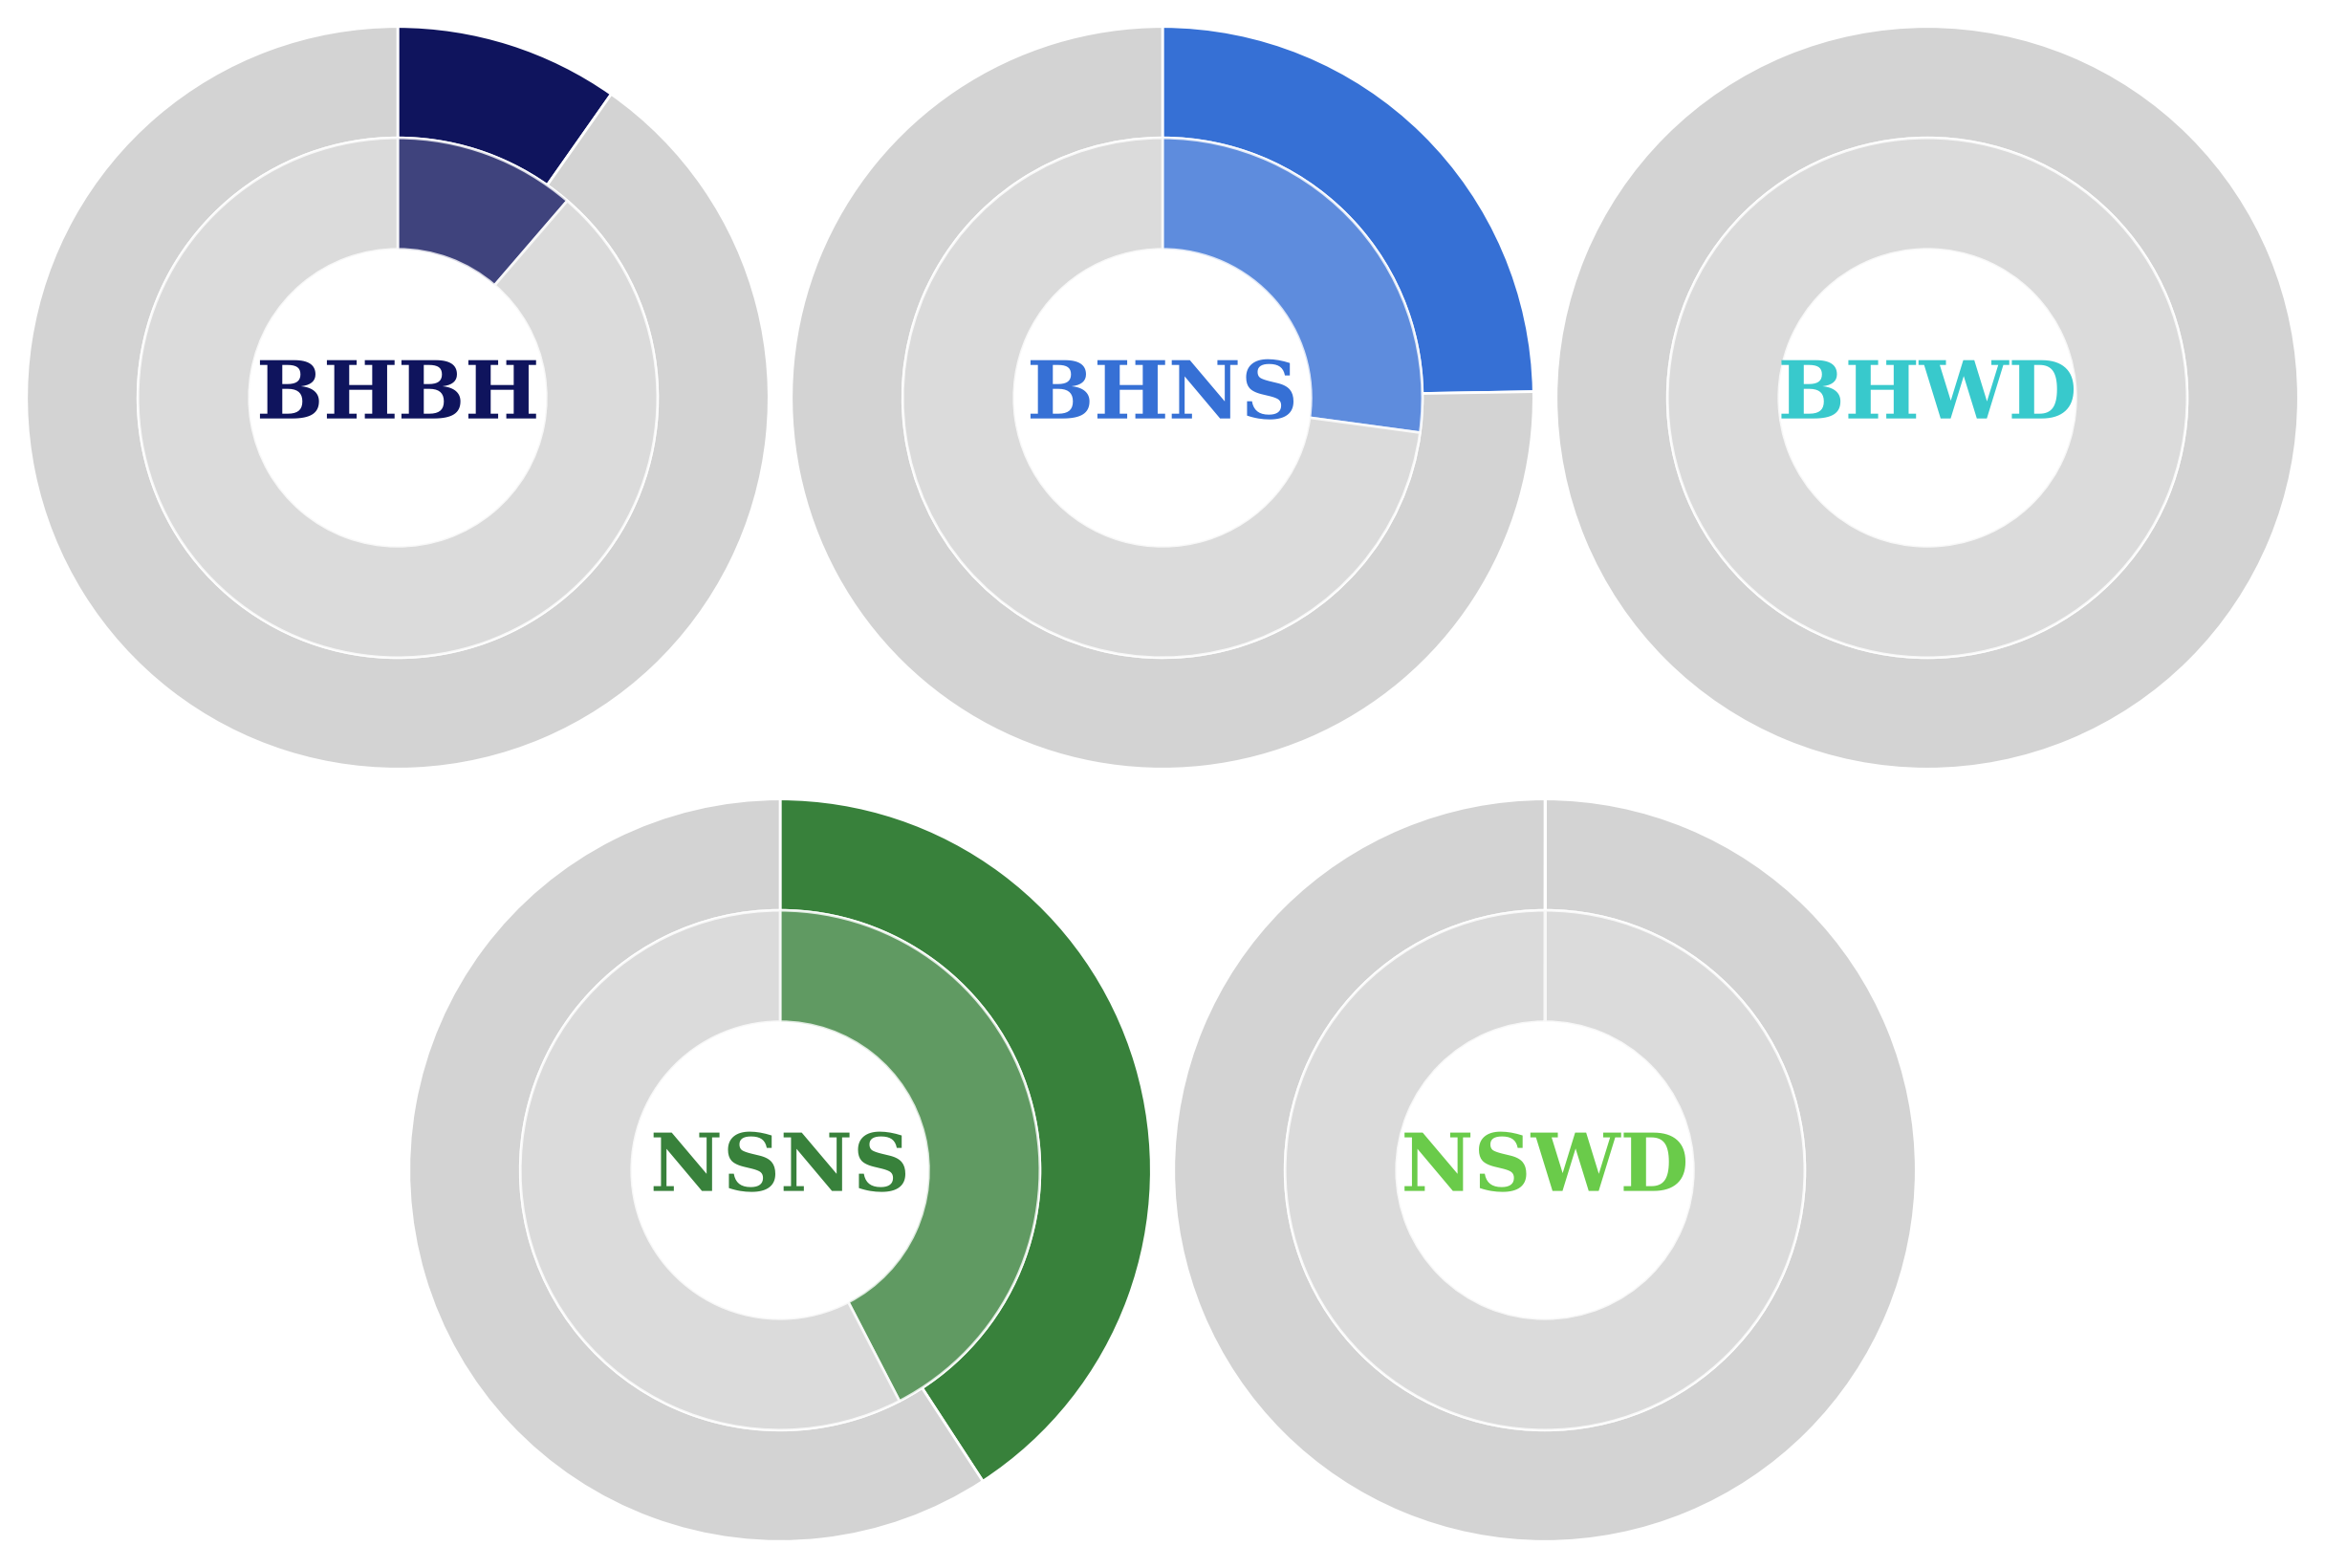

In [52]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 6, left=0, right=1, bottom=0, top=1, wspace=0, hspace=0.02)

# each panel spans two columns so the bottom row can be offset by one to centre it
positions = [gs[0, 0:2], gs[0, 2:4], gs[0, 4:6], gs[1, 1:3], gs[1, 3:5]]

for dco_type, pos in zip(const.DCO_TYPES, positions):
    at_least_two_harmonics = unc_data[dco_type]["detectable_harmonics"] >= 2
    ecc_detectable = lisa_sources[dco_type].ecc >= min_detectable_ecc(lisa_sources[dco_type].snr, lisa_sources[dco_type].f_orb * lisa_sources[dco_type].max_snr_harmonic)
    ecc_detectable_no_fmin = lisa_sources[dco_type].ecc >= min_detectable_ecc(lisa_sources[dco_type].snr, lisa_sources[dco_type].f_orb * lisa_sources[dco_type].max_snr_harmonic, f_min=0 * u.mHz)
    w = lisa_pops[dco_type].bpp["weights"]

    measureable_ecc = w[at_least_two_harmonics | ecc_detectable].sum() / w.sum()
    measureable_ecc_no_fmin = w[at_least_two_harmonics | ecc_detectable_no_fmin].sum() / w.sum()

    print(f"{dco_type}: {measureable_ecc:1.3f} of sources have measurable eccentricity")

    ax = fig.add_subplot(pos)

    # outer ring is with the frequency cut, inner ring is without
    for vals, rad, alpha in zip(
        [[measureable_ecc, 1 - measureable_ecc], [measureable_ecc_no_fmin, 1 - measureable_ecc_no_fmin]],
        [1, 0.7],
        [1, 0.8]
    ):
        ax.pie(
            vals,
            colors=[const.DCO_COLOURS[dco_type], "lightgrey"],
            startangle=90,
            counterclock=False,
            radius=rad,
            wedgeprops=dict(width=0.3, edgecolor='white', alpha=alpha)
        )
    ax.annotate(dco_type, xy=(0, 0), ha='center', va='center', fontsize=1.25*fs,
                fontweight='bold', color=const.DCO_COLOURS[dco_type])

    ax.set_xlim(-1.02, 1.02)
    ax.set_ylim(-1.02, 1.02)

plt.show()

In [23]:
pd.DataFrame(unc_data["BHBH"])

,snr_uncertainty,snr_ratio,detectable_harmonics,max_harmonics,delta_m_c_over_m_c,sigma_theta,delta_d_over_d,sigma_z,delta_forb
0,0.661805,0.184547,1,2,21.080108,22.914832,16.293577,11.066103,1.796040e-09
1,0.781916,0.109402,1,2,0.902778,7.227308,0.582832,9.254389,1.345040e-09
2,6.963075,0.011446,1,2,9.352048,19.624621,7.148748,4.899813,1.376565e-09
3,3.654349,0.024659,1,2,2.003373,11.304287,1.428515,12.749850,1.536315e-09
4,0.918637,0.016091,1,2,0.117657,1.122743,0.071077,0.155205,2.541451e-10
...,...,...,...,...,...,...,...,...,...
34419,0.808799,0.044307,1,2,0.879958,3.661580,0.631771,1.094550,5.993546e-10
34420,2.032377,0.033836,1,2,1.671727,7.568996,1.199388,2.924310,1.161923e-09
34421,0.561860,0.029447,1,2,0.217985,1.396883,0.145968,0.205748,2.807550e-10
34422,1.077764,0.027503,1,2,0.790254,4.126476,0.572357,1.032370,5.039527e-10


BHBH first crosses WDWD at 5.80 kpc
BHNS first crosses WDWD at 5.64 kpc
BHWD never crosses WDWD
NSNS never crosses WDWD
NSWD first crosses WDWD at 4.40 kpc


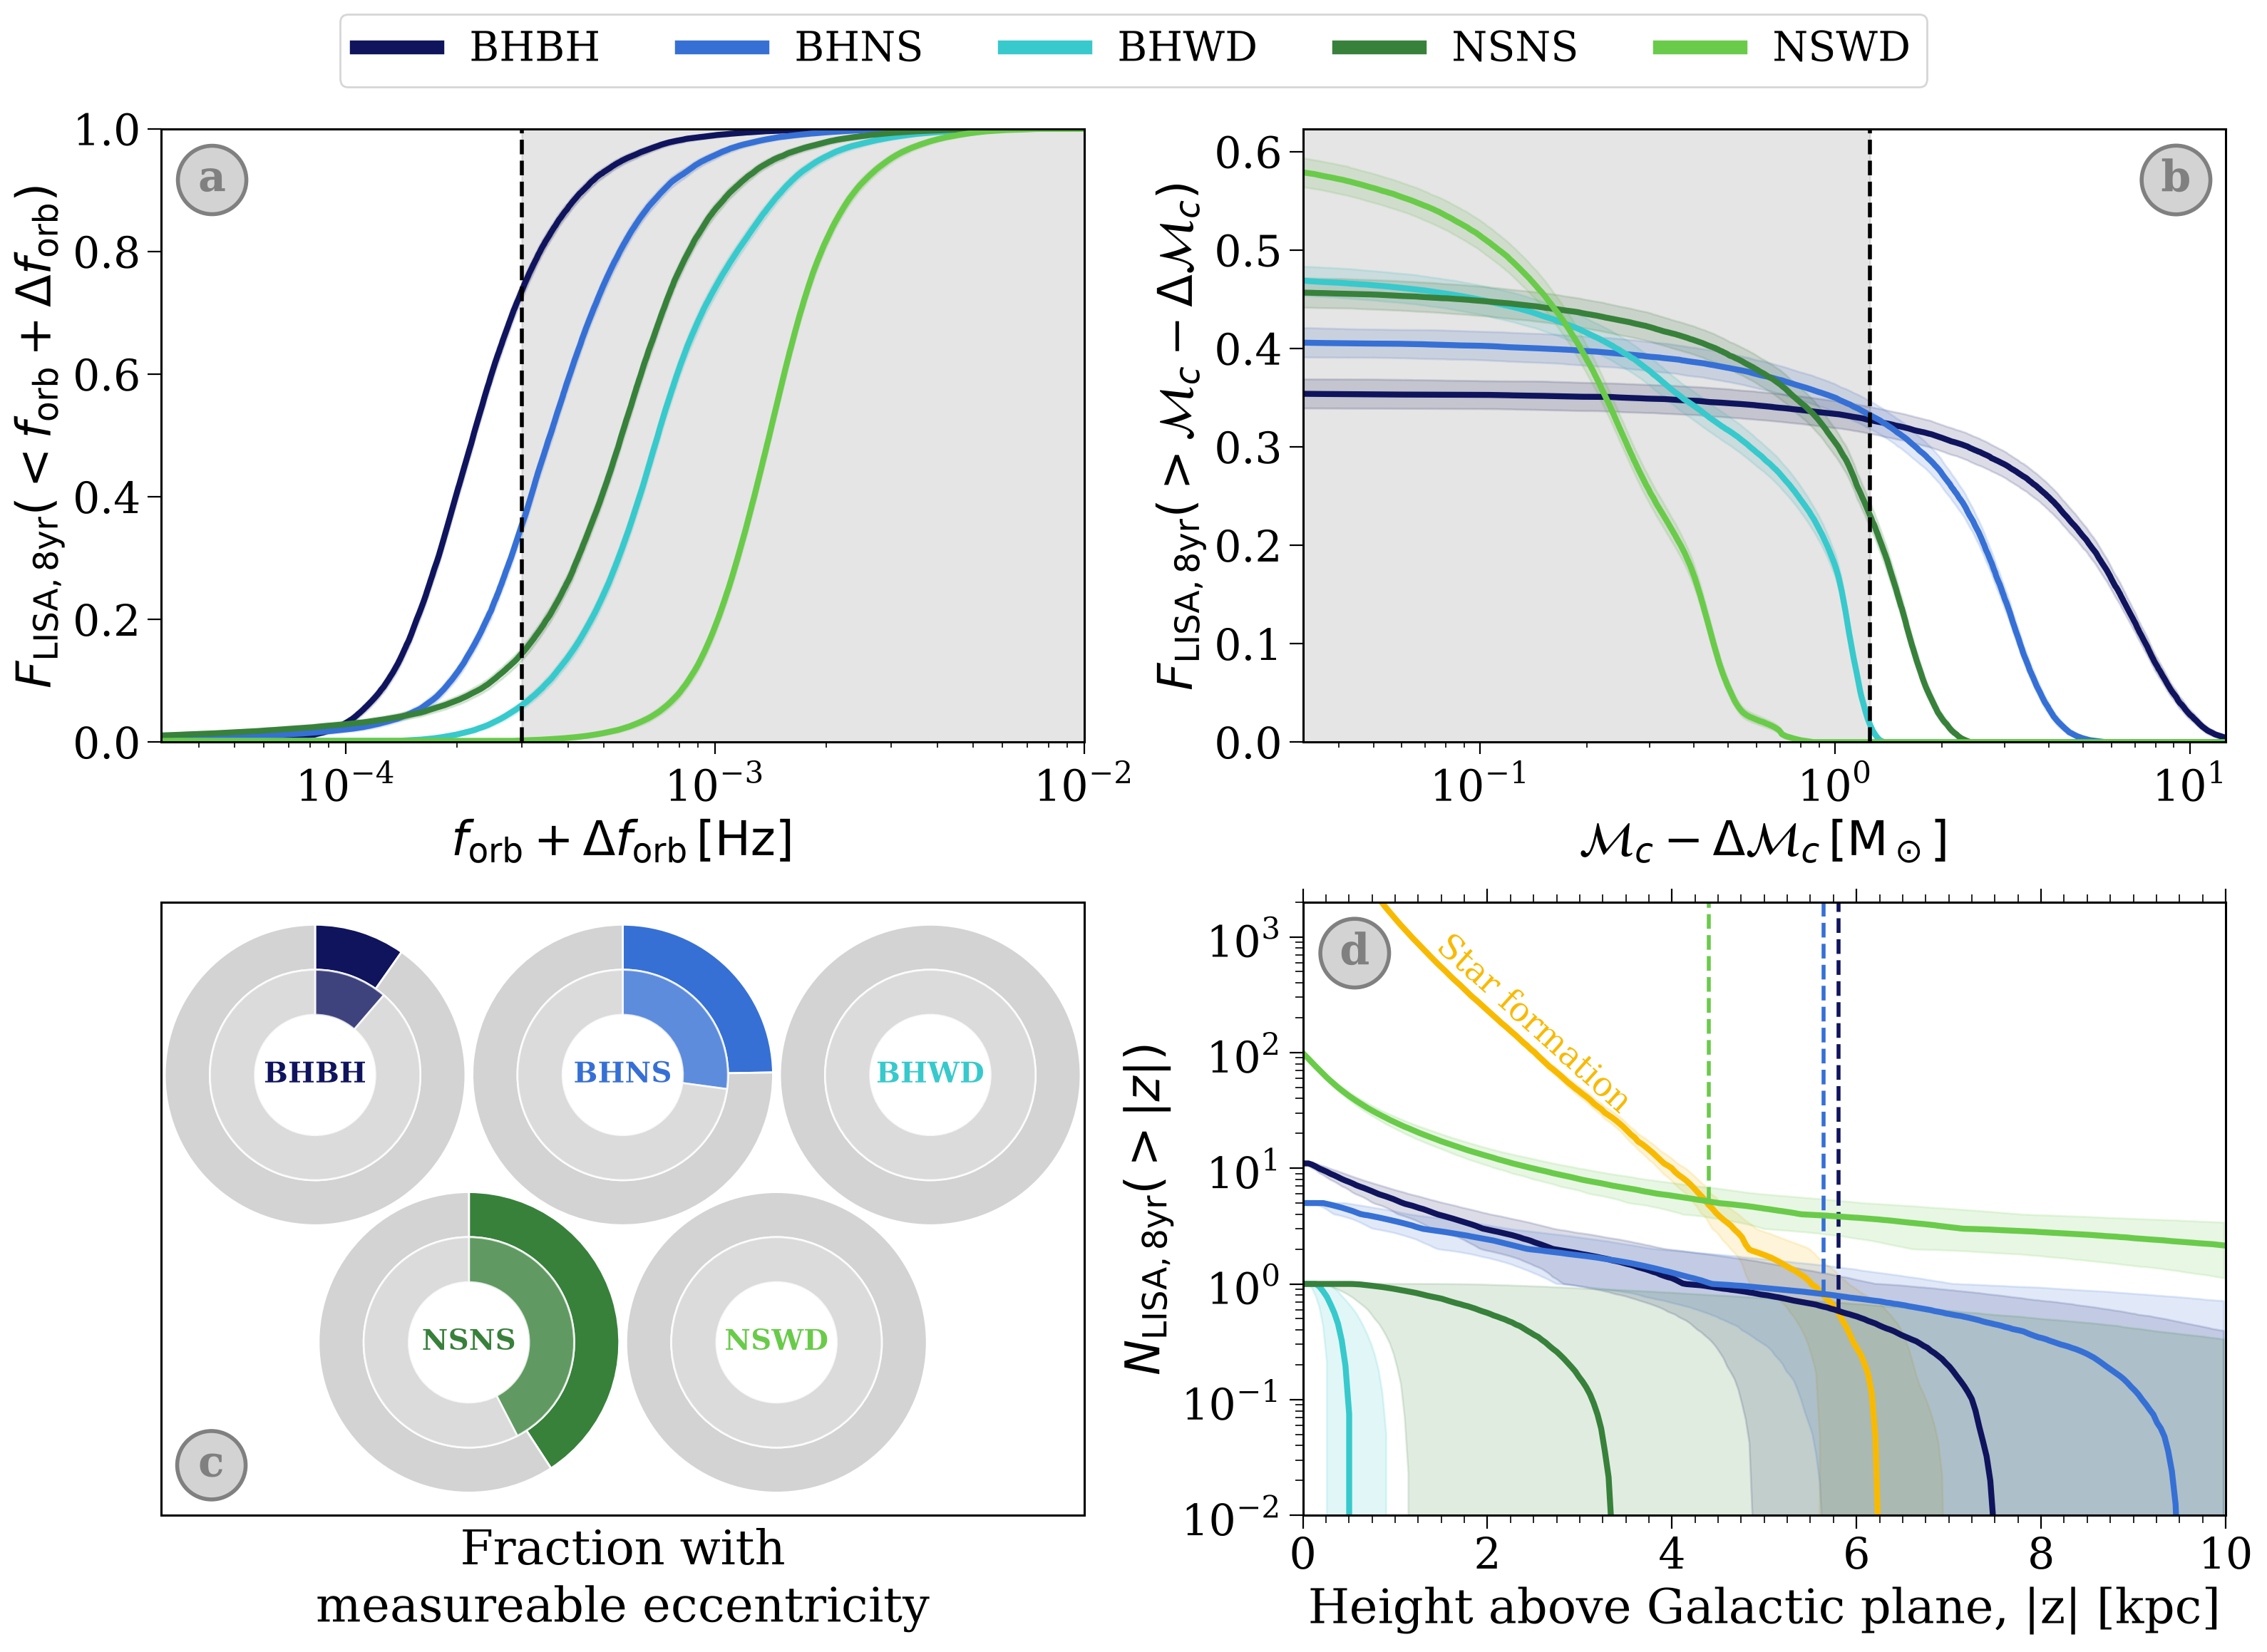

In [24]:
reload(plotting)
reload(unc)
counts = {"BHBH": 13, "BHNS": 8, "BHWD": 2, "NSNS": 2, "NSWD": 110}
counts = {"BHBH": 12, "BHNS": 6, "BHWD": 2, "NSNS": 2, "NSWD": 99}
fig, axes, height_where_exceeds_wdwds = plotting.four_panel_uncertainties(
    lisa_sources, lisa_pops, unc_data, wdwd_dist, detectable_pops, counts,
    n_boot=5000, save="../plots/dco_measured_properties.pdf", show=True
)

BHBH first crosses WDWD at 5.80 kpc
BHNS first crosses WDWD at 5.64 kpc
BHWD never crosses WDWD
NSNS never crosses WDWD
NSWD first crosses WDWD at 4.40 kpc


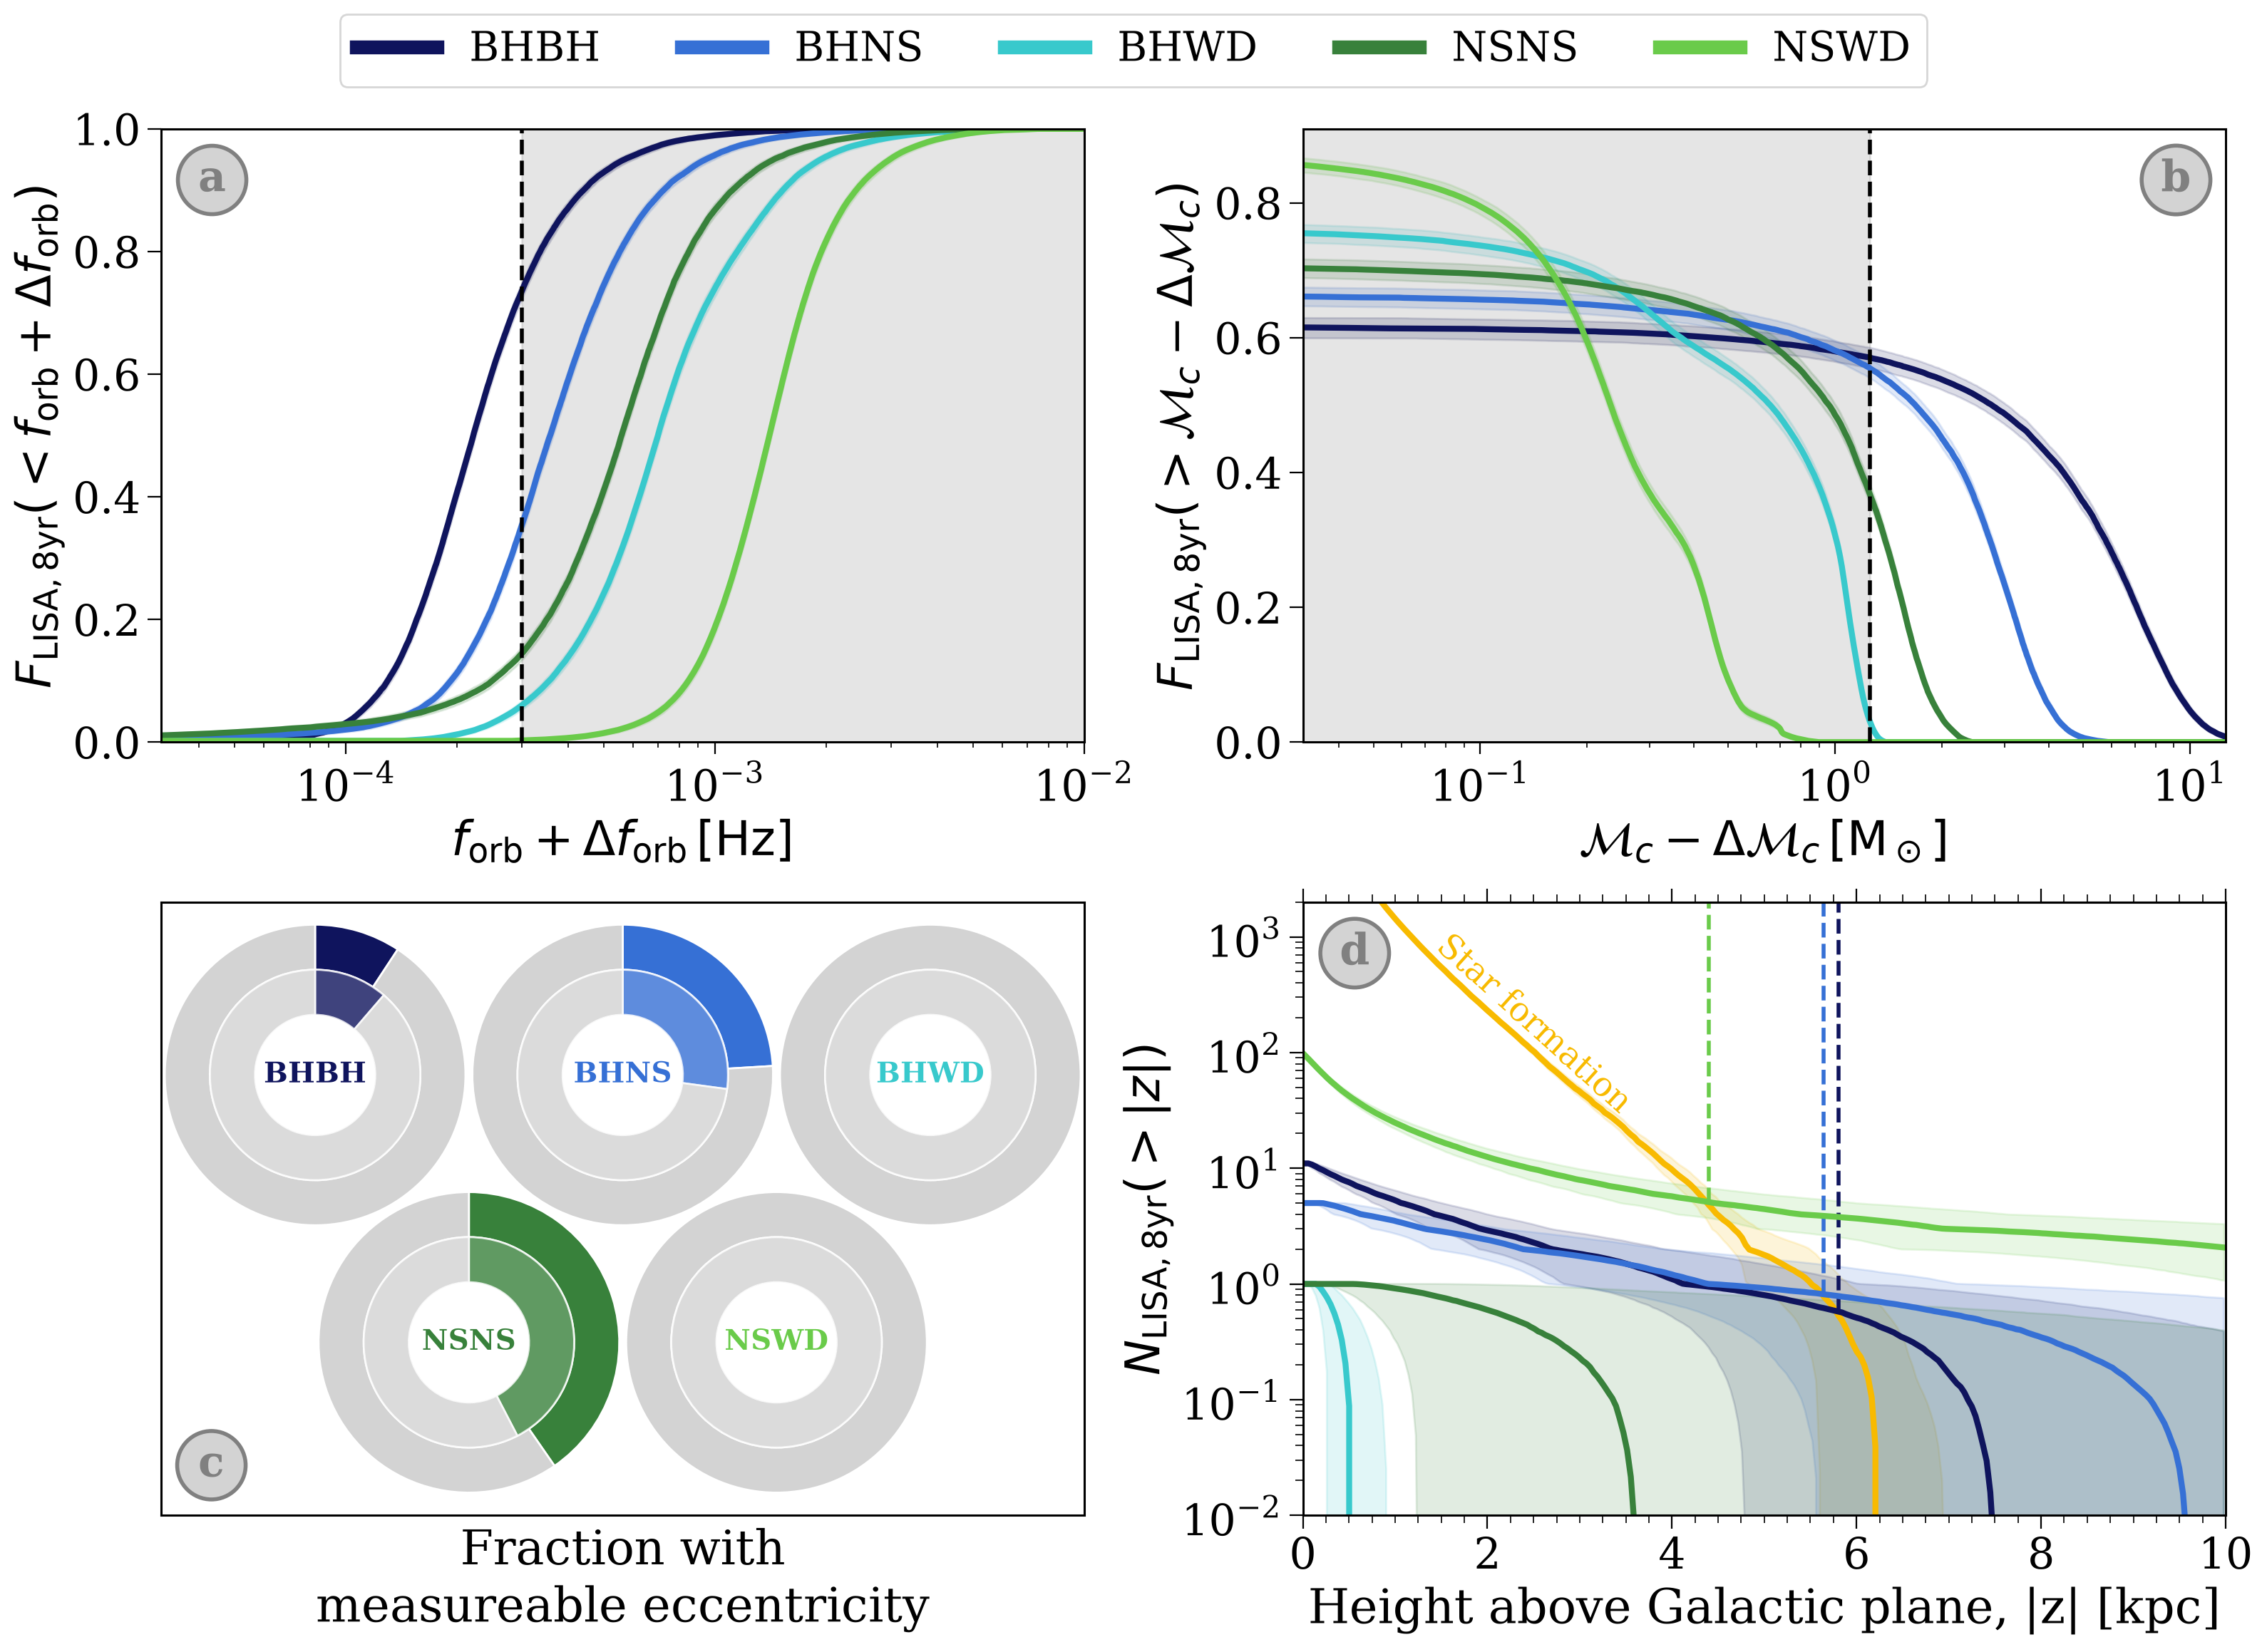

In [27]:
reload(plotting)
reload(unc)
counts = {"BHBH": 12, "BHNS": 6, "BHWD": 2, "NSNS": 2, "NSWD": 99}
fig, axes, height_where_exceeds_wdwds = plotting.four_panel_uncertainties(
    lisa_sources, lisa_pops, unc_data, wdwd_dist, detectable_pops, counts,
    n_boot=5000, save="../plots/dco_measured_properties.pdf", show=True
)

In [40]:
lisa_pops["BHBH"].bpp

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,ecc,bin_num,weights,remove_if_pessimistic,...,ecc_present_day,snr_lisa_8yr_initial_pos,snr_lisa_4yr_initial_pos,snr_lisa_8yr_final_pos,snr_lisa_4yr_final_pos,snr_decigo_8yr_initial_pos,snr_decigo_4yr_initial_pos,snr_decigo_8yr_final_pos,snr_decigo_4yr_final_pos,MW_instance
7242,6.577797,11.689343,8.769088,14,14,7.789378,0.218198,7242,0.037438,False,...,0.034265,2.839488,2.001869,13.797328,9.727266,0.0,0.0,0.0,0.0,0
11070,7.027529,16.389107,5.632334,14,14,9.115847,0.392681,11070,0.021068,False,...,0.024833,91.823069,62.967840,18.941068,12.988872,0.0,0.0,0.0,0.0,0
11339,6.236356,31.279947,10.949866,14,14,15.360486,0.024997,11339,0.041262,False,...,0.002027,7.891740,5.569016,17.984748,12.691414,0.0,0.0,0.0,0.0,0
17191,6.961870,22.583729,6.627213,14,14,16.267139,0.171164,17191,0.036423,False,...,0.005474,21.384063,14.900507,16.319833,11.371730,0.0,0.0,0.0,0.0,0
28108,7.899032,14.779052,4.516522,14,14,13.189022,0.171032,28108,0.034015,False,...,0.003575,98.583912,66.475267,101.946211,68.742470,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241971110,10.274615,11.791740,4.676541,14,14,20.893068,0.493534,1241971110,0.107771,False,...,0.010046,28.588932,19.757833,42.177569,29.148951,0.0,0.0,0.0,0.0,2579
1241999556,7.502187,15.487792,4.943503,14,14,21.312170,0.392833,1241999556,0.024858,False,...,0.007636,22.534713,15.623475,21.687208,15.035895,0.0,0.0,0.0,0.0,2579
1242004386,7.903817,15.062709,3.648706,14,14,19.821141,0.411483,1242004386,0.032060,False,...,0.006652,32.944259,22.461722,91.267455,62.227054,0.0,0.0,0.0,0.0,2579
1242015697,6.148215,27.473076,6.973389,14,14,28.812175,0.325809,1242015697,0.034047,False,...,0.005971,22.934546,16.037026,49.577352,34.667060,0.0,0.0,0.0,0.0,2579


In [37]:
df1 = pd.read_hdf("/mnt/ceph/users/twagg/lisa-dcos/fiducial/uncertainties_pessimistic.h5", key="distinguishers")
df2 = pd.read_hdf("/mnt/ceph/users/twagg/lisa-dcos/fiducial/uncertainties.h5", key="distinguishers")

# combine df1 and df2 with a multiindex where the first level is "pessimistic" or "optimistic" and the second level is the dco_type
df1["model"] = "fiducial"
df2["model"] = "optimistic"
combo_df = pd.concat([df1, df2], axis=0)
combo_df = combo_df.set_index(["model"], append=True).reorder_levels([1, 0] + list(range(2, combo_df.index.nlevels + 1)))
combo_df

too_low_freq  too_massive  measureable_eccentricity  \
model                                                                  
fiducial   BHBH         0.695        0.571                     0.093   
           BHNS         0.370        0.548                     0.240   
           BHWD         0.058        0.032                     0.000   
           NSNS         0.148        0.377                     0.404   
           NSWD         0.002        0.000                     0.000   
optimistic BHBH         0.729        0.504                     0.127   
           BHNS         0.374        0.504                     0.354   
           BHWD         0.033        0.149                     0.000   
           NSNS         0.142        0.136                     0.658   
           NSWD         0.003        0.000                     0.014   

                 too_far_from_plane  m_forb  m_forb_ecc  m_forb_ecc_z  
model                                                                  
fiducial   BHBH               0.026   0.988       0.989         0.989  
           BHNS               0.089   0.883       0.894         0.896  
           BHWD               0.000   0.089       0.089         0.089  
           NSNS               0.000   0.524       0.630         0.630  
           NSWD               0.019   0.002       0.003         0.022  
optimistic BHBH               0.015   0.989       0.990         0.990  
           BHNS               0.055   0.845       0.889         0.891  
           BHWD               0.000   0.182       0.182         0.182  
           NSNS               0.000   0.277       0.723         0.723  
           NSWD               0.014   0.003       0.017         0.031

In [ ]:
df1

,too_low_freq,too_massive,measureable_eccentricity,too_far_from_plane,m_forb,m_forb_ecc,m_forb_ecc_z
BHBH,0.695,0.571,0.093,0.026,0.988,0.989,0.989
BHNS,0.370,0.548,0.240,0.089,0.883,0.894,0.896
BHWD,0.058,0.032,0.000,0.000,0.089,0.089,0.089
NSNS,0.148,0.377,0.404,0.000,0.524,0.630,0.630
NSWD,0.002,0.000,0.000,0.019,0.002,0.003,0.022


In [41]:
import matplotlib as mpl

In [65]:
detectable_sources["BHBH"].get_snr()

array([ 8.49696946, 11.06121015,  6.06673453, ..., 11.86861495,
        3.52626547,  6.15737892], shape=(108838,))

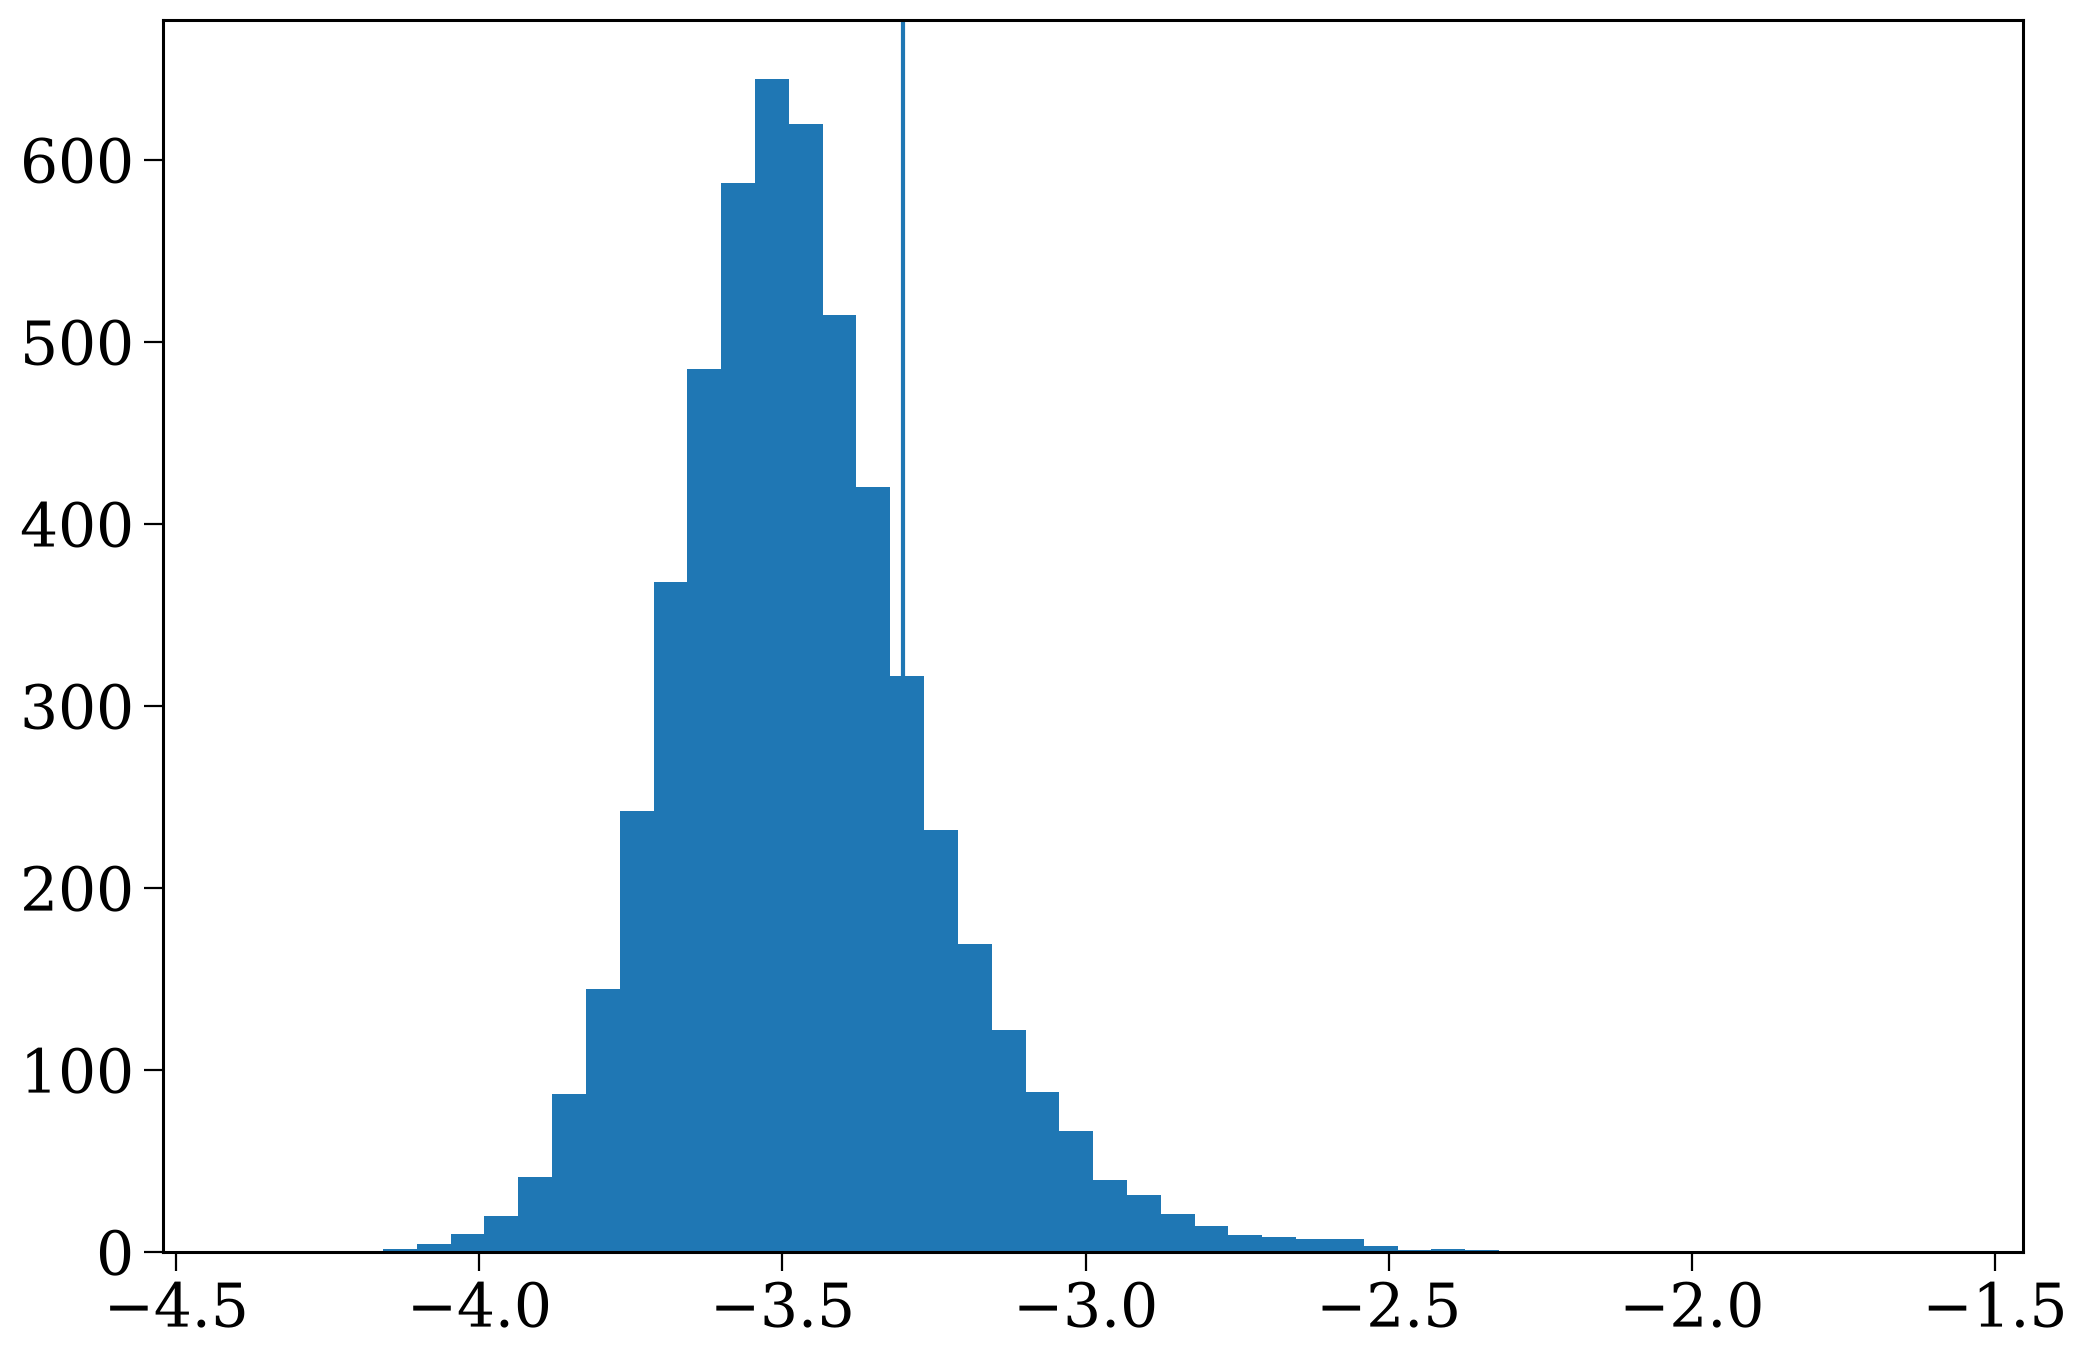

In [72]:
plt.hist(np.log10(detectable_sources["BHBH"].f_orb.value * detectable_sources["BHBH"].max_snr_harmonic), weights=detectable_pops["BHBH"].initC["weights"], bins=50);
plt.axvline(np.log10(0.5e-3))

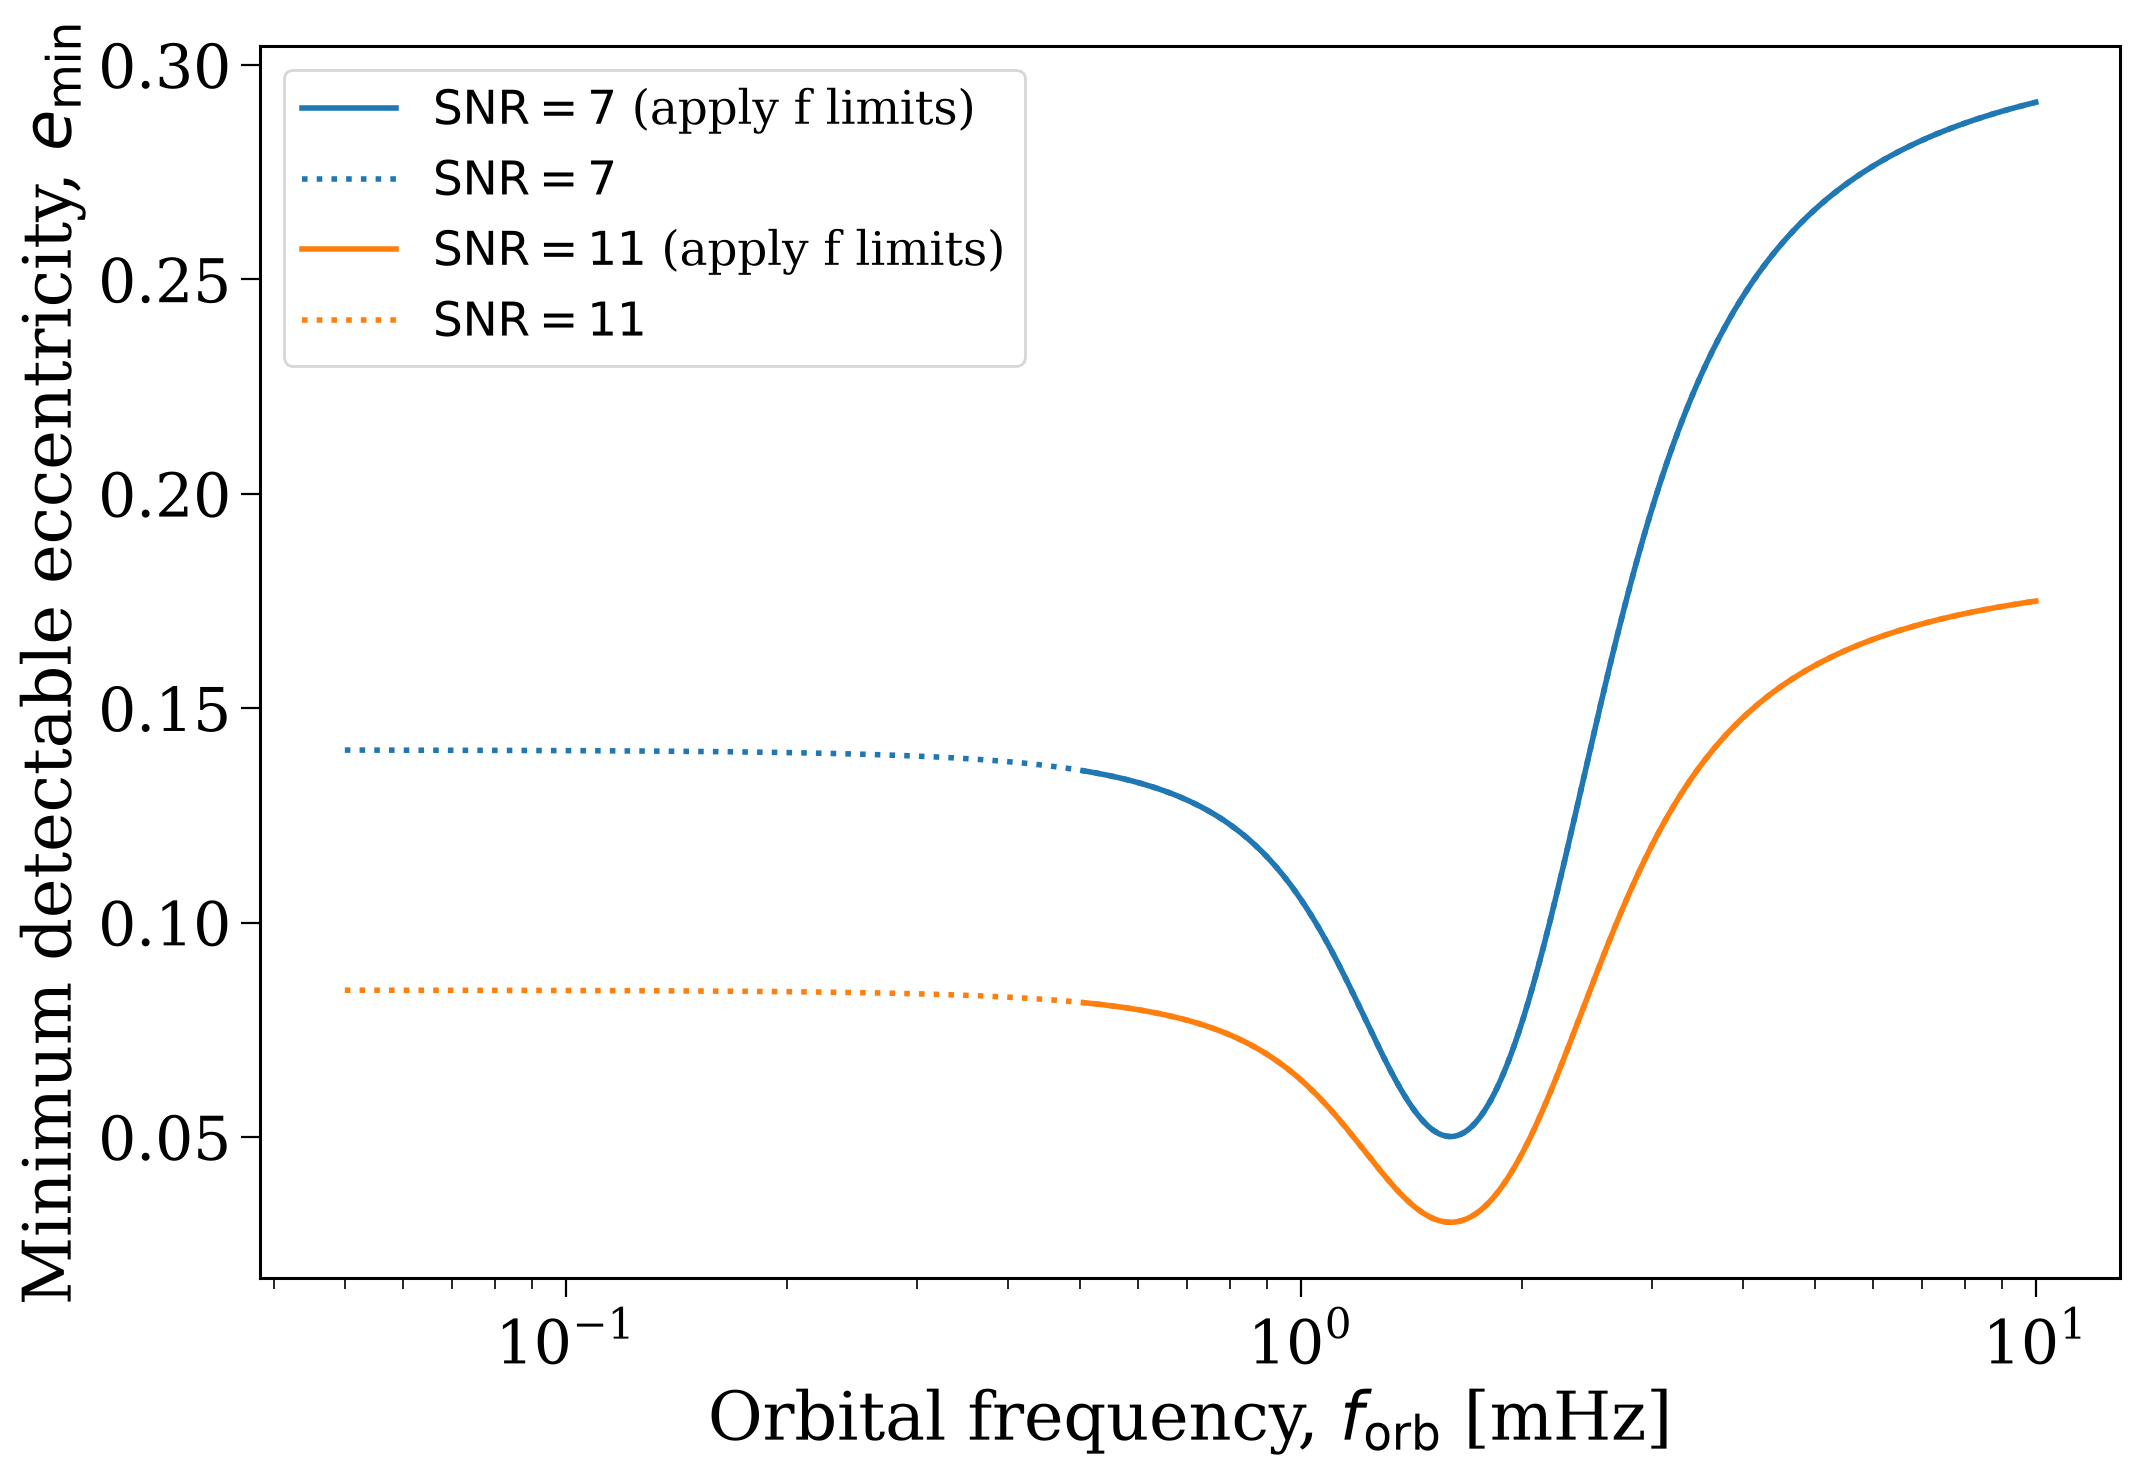

In [86]:
snr_range = np.linspace(7, 100, 100)
f_range = np.linspace(0.05, 10, 1001) * u.mHz

SNR, F = np.meshgrid(snr_range, f_range)

# fig, ax = plt.subplots()

# contourf = ax.contourf(np.log10(SNR), np.log10(F.to(u.mHz).value), np.log10(min_detectable_ecc(SNR, F, f_min=0)), levels=np.linspace(-3, 0, 21), cmap="plasma")
# fig.colorbar(contourf)
# plotting.fake_log_axis(ax, axis="y")
# plotting.fake_log_axis(ax, axis="x")

# plt.show()

for i, snr in enumerate([7, 11]):
    plt.plot(f_range.to(u.mHz).value[f_range > 0.5 * u.mHz], min_detectable_ecc(snr, f_range)[f_range > 0.5 * u.mHz], lw=2, label=rf"$\rm SNR = {snr}$ (apply f limits)", linestyle="-", color=f'C{i}')
    plt.plot(f_range.to(u.mHz).value, min_detectable_ecc(snr, f_range, f_min=0), lw=2, label=rf"$\rm SNR = {snr}$", color=f'C{i}', linestyle=":")
plt.xscale("log")
plt.ylabel(r"Minimum detectable eccentricity, $e_{\rm min}$")
plt.xlabel(r"Orbital frequency, $f_{\rm orb}$ [mHz]")
plt.legend()

In [ ]:
distinguishers = get_wdwd_distinguishing_factors(lisa_sources, unc_data, height_where_exceeds_wdwds)
distinguishers

,too_low_freq,too_massive,measureable_eccentricity,too_far_from_plane,m_forb,m_forb_ecc,m_forb_ecc_z
BHBH,0.770,0.236,0.125,0.010,0.945,0.949,0.949
BHNS,0.420,0.253,0.321,0.036,0.671,0.754,0.756
BHWD,0.047,0.087,0.000,0.000,0.134,0.134,0.134
NSNS,0.158,0.090,0.633,0.020,0.247,0.687,0.698
NSWD,0.005,0.000,0.013,0.012,0.005,0.018,0.029


In [72]:
distinguishers = get_wdwd_distinguishing_factors(lisa_sources, unc_data, height_where_exceeds_wdwds)
distinguishers

,too_low_freq,too_massive,measureable_eccentricity,too_far_from_plane,m_forb,m_forb_ecc,m_forb_ecc_z
BHBH,0.695,0.329,0.098,0.019,0.938,0.941,0.941
BHNS,0.370,0.328,0.247,0.067,0.694,0.725,0.731
BHWD,0.058,0.019,0.000,0.000,0.077,0.077,0.077
NSNS,0.148,0.238,0.408,0.000,0.385,0.546,0.546
NSWD,0.002,0.000,0.000,0.015,0.002,0.003,0.018


(<Figure size 1500x300 with 1 Axes>,
 <Axes: ylabel='Fraction distinguished from WDWDs'>)

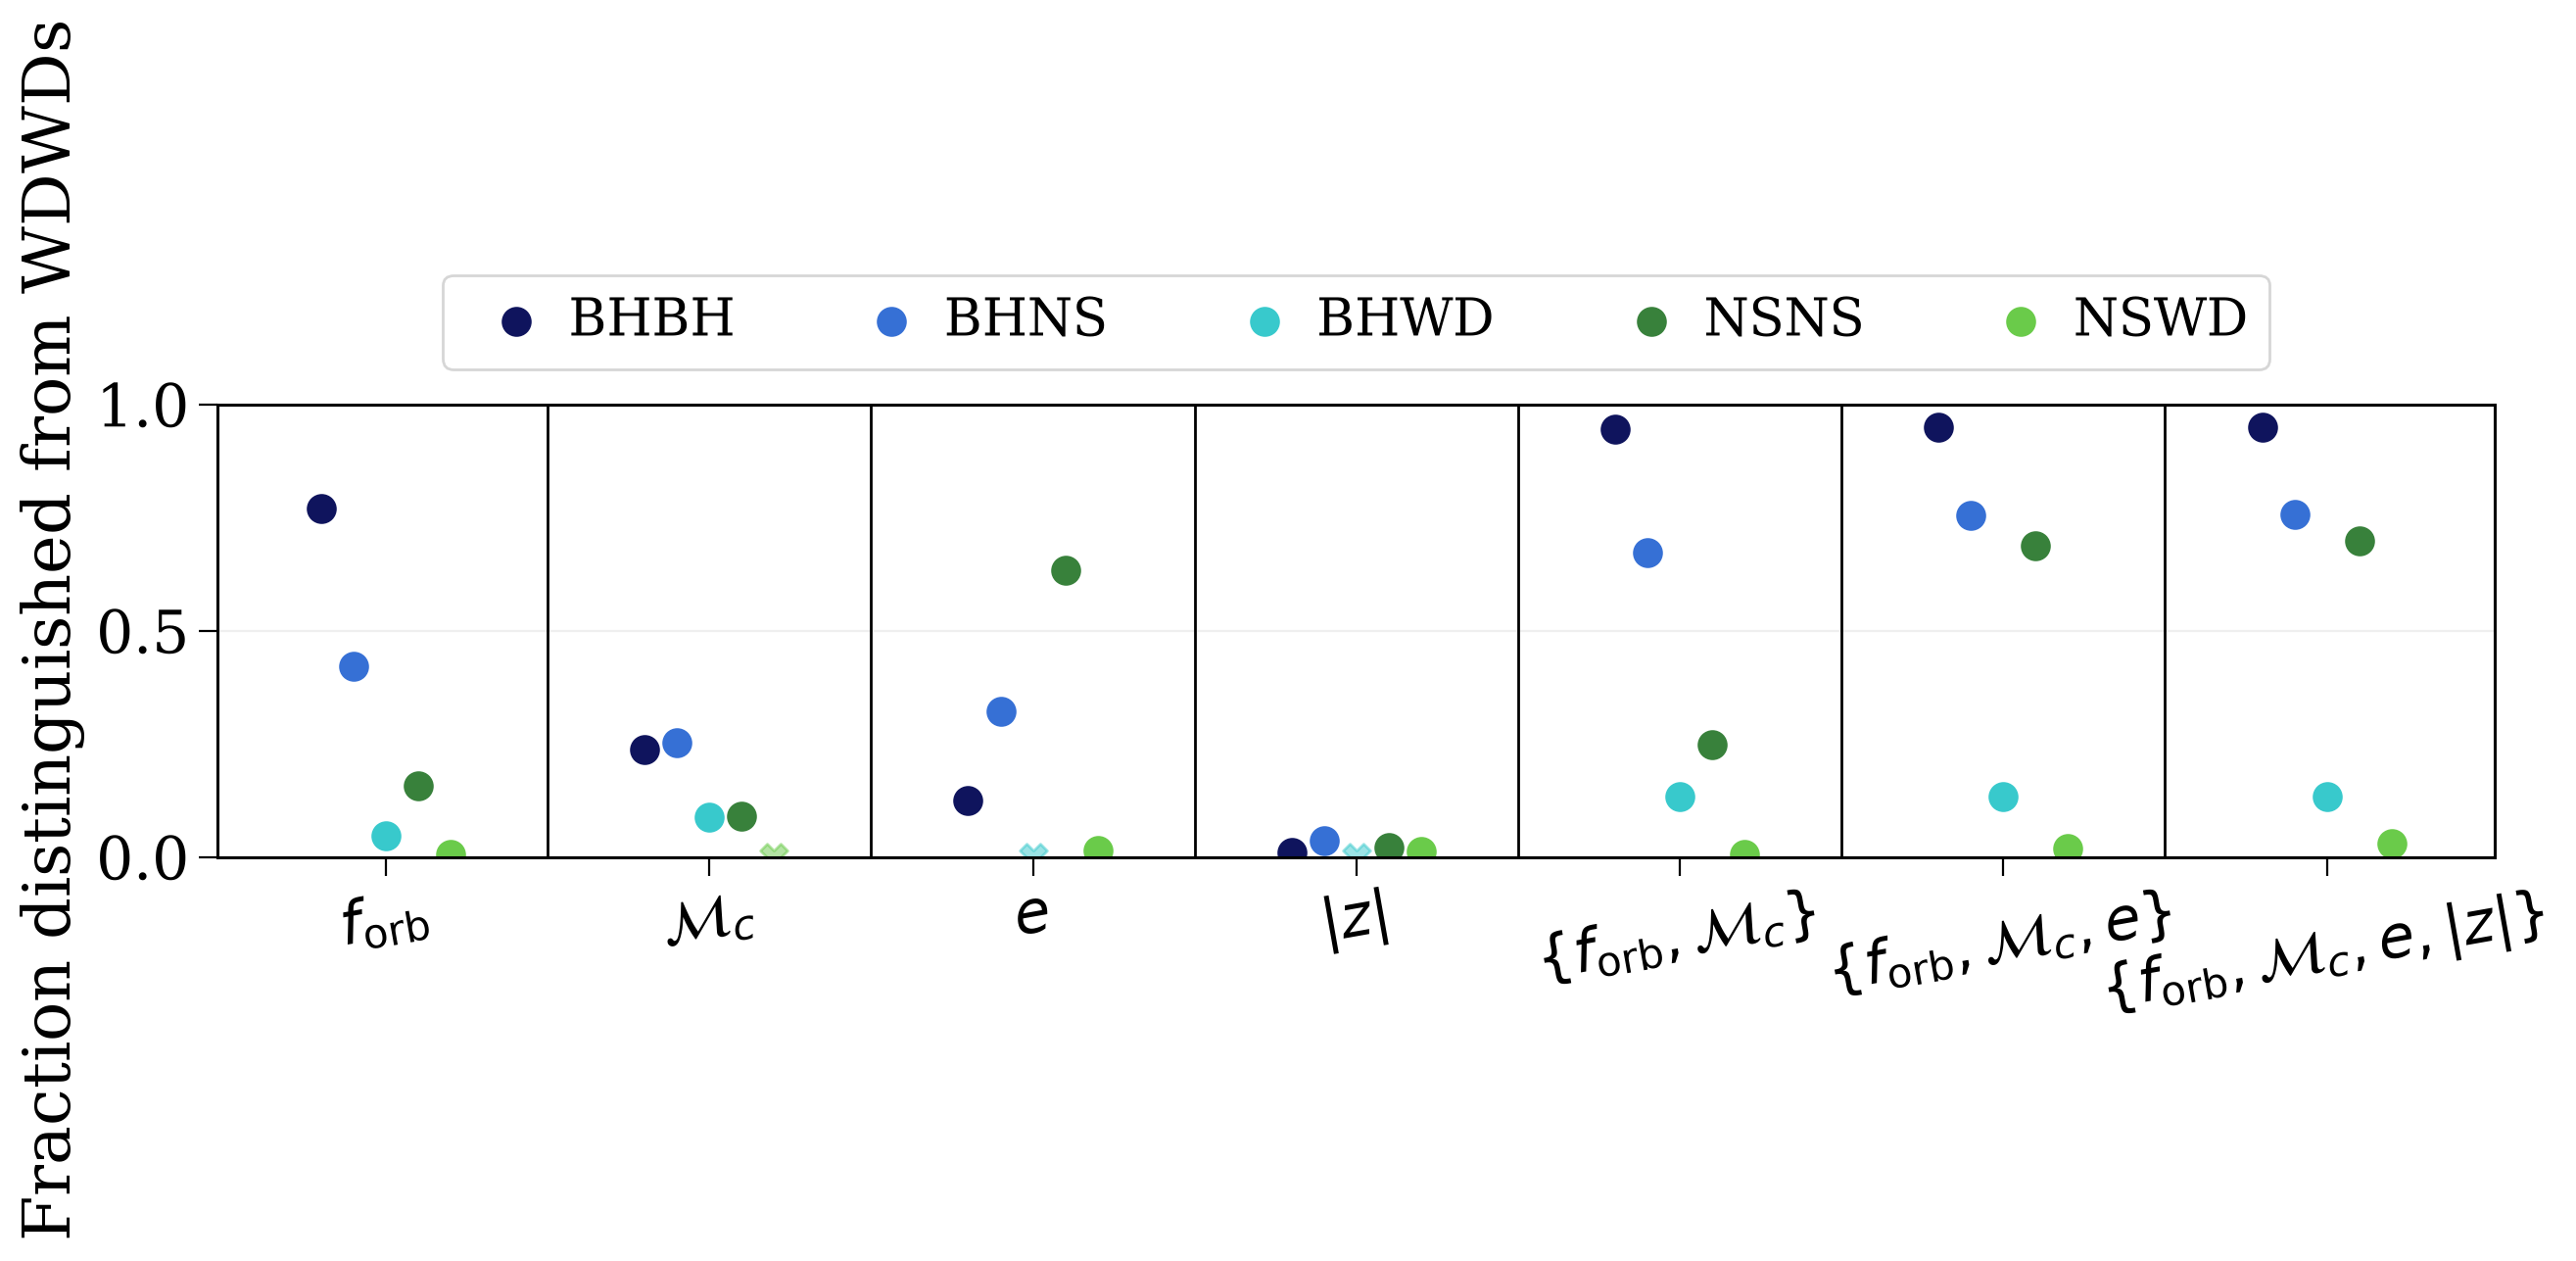

In [97]:
def plot_wdwd_distinguishers(distinguishers, col_labels=[r"$f_{\rm orb}$", r"$\mathcal{M}_c$", r"$e$", r"$|z|$",
                                                         r"$\{f_{\rm orb}, \mathcal{M}_c\}$", r"$\{f_{\rm orb}, \mathcal{M}_c, e\}$",
                                                         r"$\{f_{\rm orb}, \mathcal{M}_c, e, |z|\}$"]):
    fig, ax = plt.subplots(figsize=(15, 3))

    x_vals = np.arange(len(distinguishers.columns))
    x_offset = 0.1

    zeros = []

    for i, col in enumerate(distinguishers.columns):
        for j, dco_type in enumerate(const.DCO_TYPES):
            x_offseted = x_vals[i] + (j - 2) * x_offset
            if distinguishers[col][dco_type] == 0:
                zeros.append((x_offseted, dco_type))
            else:
                ax.scatter(x_offseted, distinguishers[col][dco_type], color=const.DCO_COLOURS[dco_type], s=100, label=dco_type if i == 0 else None)

    ax.set_xticks(x_vals)
    ax.set_xticklabels(distinguishers.columns if col_labels is None else col_labels, rotation=10)
    ax.set_ylabel("Fraction distinguished from WDWDs")

    ax.set_ylim(0, 1)
    # ax.set_yscale("log")

    ax.legend(loc='lower center', ncol=len(const.DCO_TYPES), fontsize=0.8*fs, bbox_to_anchor=(0.5, 1.02), handletextpad=0.0)

    ax.grid(which="both", alpha=0.2, axis='y')

    for x in x_vals[:-1]:
        ax.axvline(x + 0.5, color='k', ls="-", lw=1)

    # put grid below the points
    ax.set_axisbelow(True)

    og_ymin, og_ymax = ax.get_ylim()

    if len(zeros) > 0:
        for x, dco_type in zeros:
            ax.scatter(x, og_ymin, color=const.DCO_COLOURS[dco_type], s=100, marker="X", alpha=0.5)

    ax.set_ylim((og_ymin * 0.9, og_ymax))

    return fig, ax

plot_wdwd_distinguishers(distinguishers)

(<Figure size 1500x300 with 1 Axes>,
 <Axes: ylabel='Fraction distinguished from WDWDs'>)

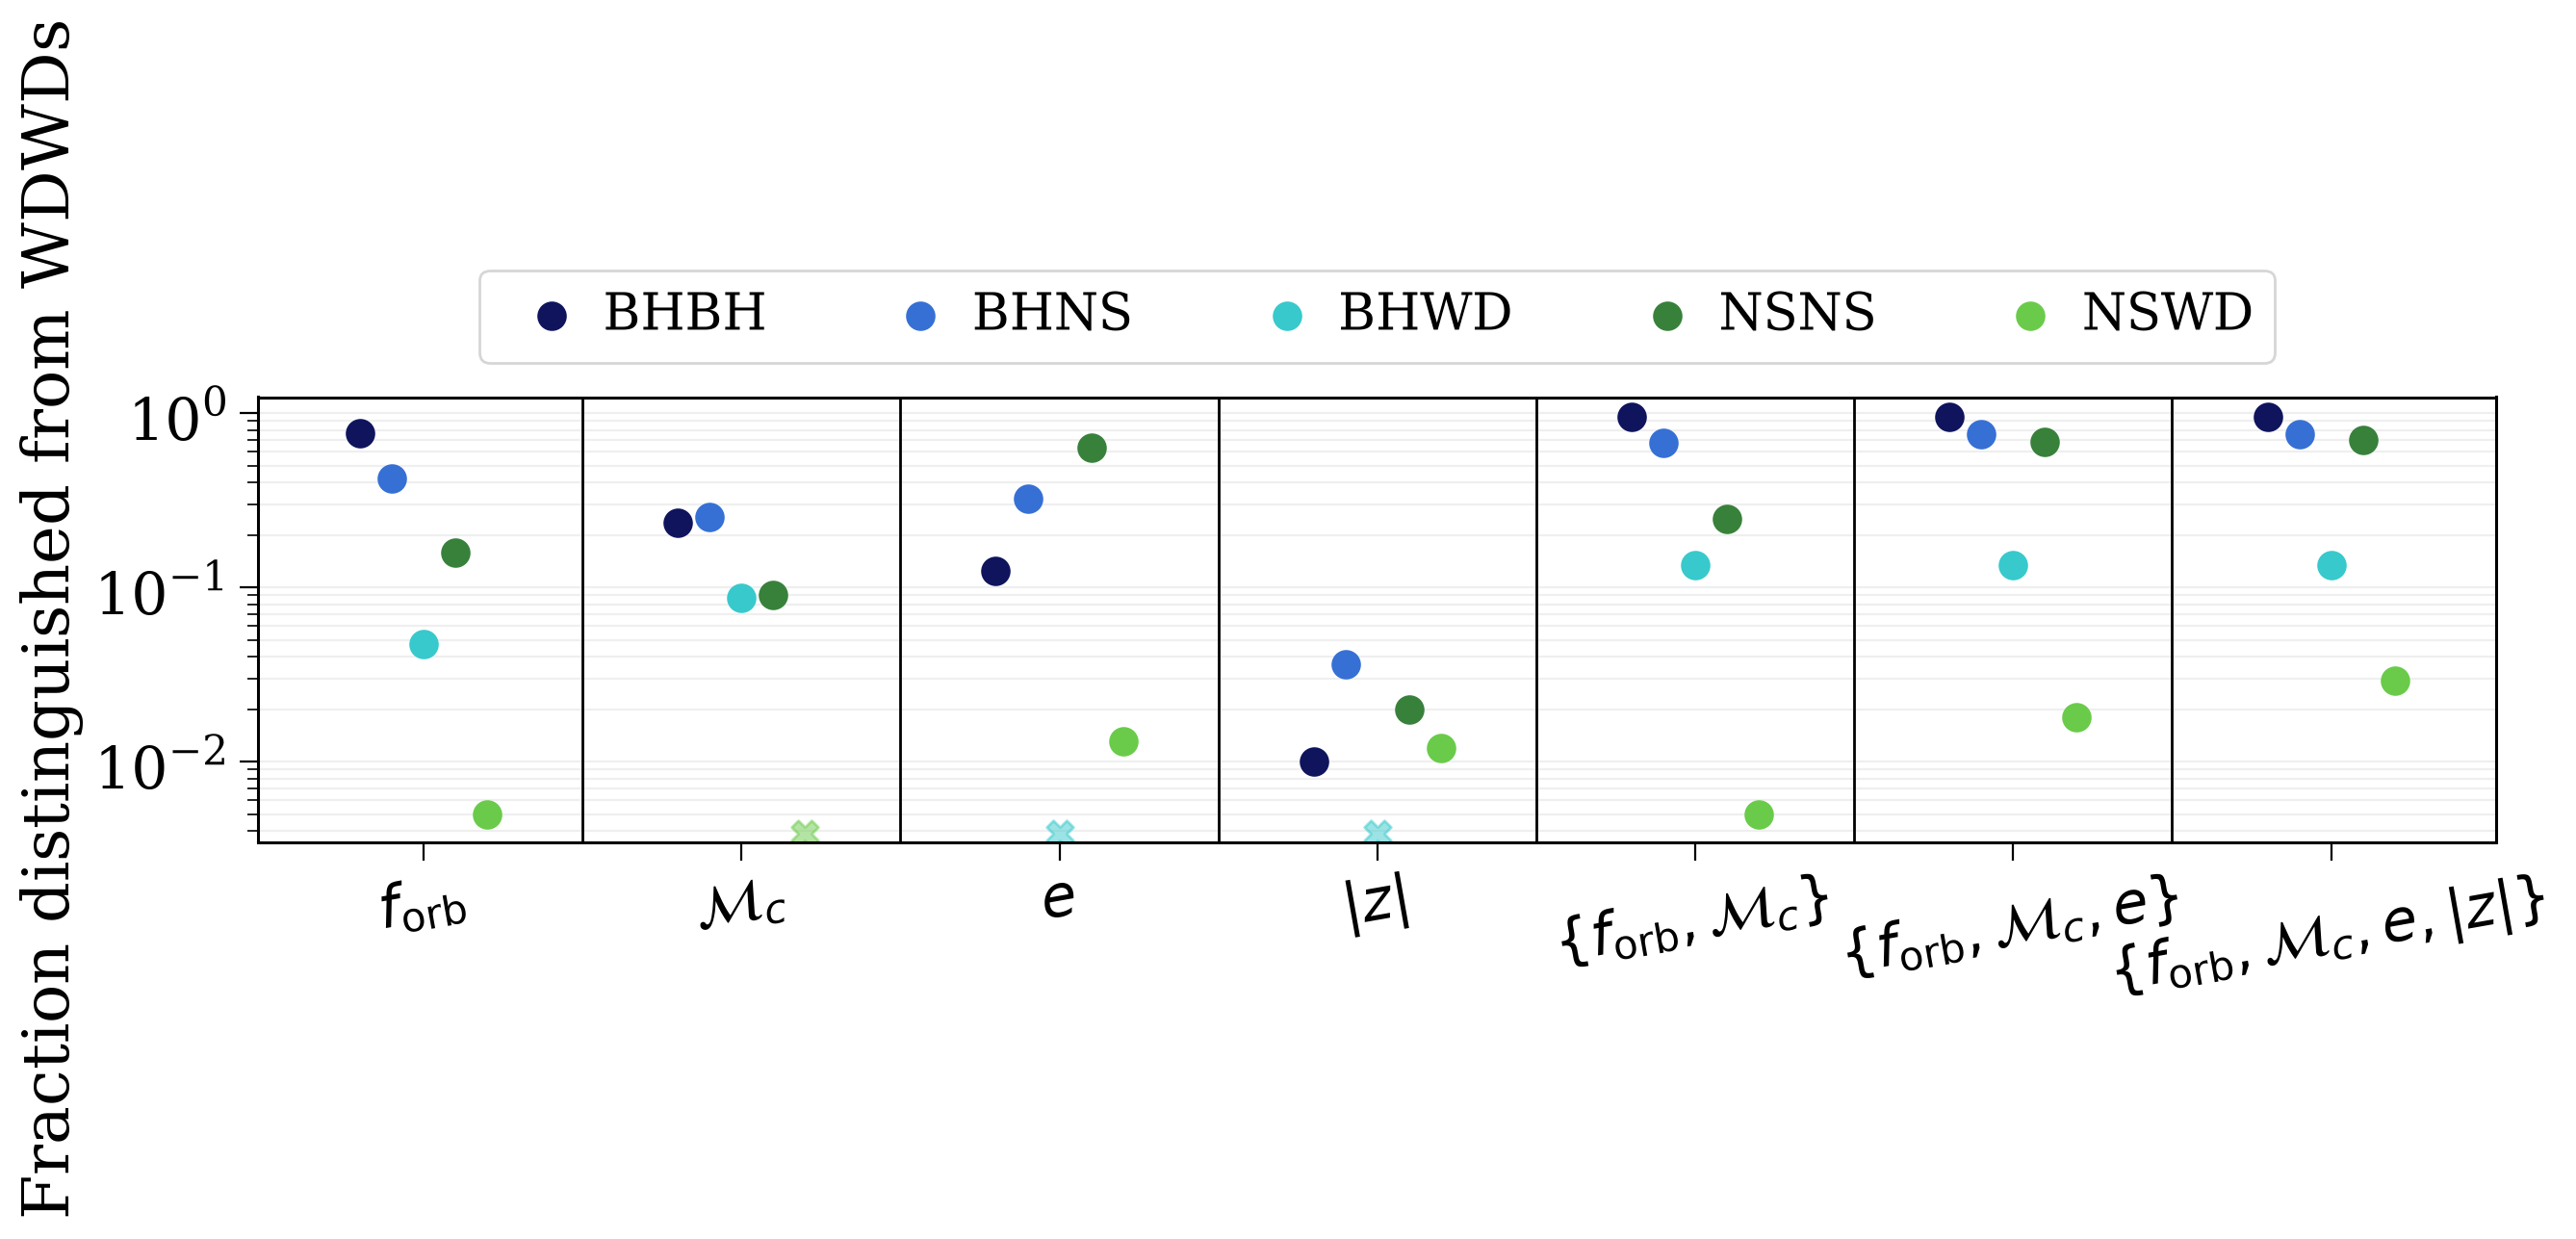

In [94]:
def plot_wdwd_distinguishers(distinguishers, col_labels=[r"$f_{\rm orb}$", r"$\mathcal{M}_c$", r"$e$", r"$|z|$",
                                                         r"$\{f_{\rm orb}, \mathcal{M}_c\}$", r"$\{f_{\rm orb}, \mathcal{M}_c, e\}$",
                                                         r"$\{f_{\rm orb}, \mathcal{M}_c, e, |z|\}$"]):
    fig, ax = plt.subplots(figsize=(15, 3))

    x_vals = np.arange(len(distinguishers.columns))
    x_offset = 0.1

    zeros = []

    for i, col in enumerate(distinguishers.columns):
        for j, dco_type in enumerate(const.DCO_TYPES):
            x_offseted = x_vals[i] + (j - 2) * x_offset
            ax.scatter(x_offseted, distinguishers[col][dco_type], color=const.DCO_COLOURS[dco_type], s=100, label=dco_type if i == 0 else None)
            if distinguishers[col][dco_type] == 0:
                zeros.append((x_offseted, dco_type))

    ax.set_xticks(x_vals)
    ax.set_xticklabels(distinguishers.columns if col_labels is None else col_labels, rotation=10)
    ax.set_ylabel("Fraction distinguished from WDWDs")
    # ax.set_ylim(0, 1)

    ax.set_yscale("log")

    ax.legend(loc='lower center', ncol=len(const.DCO_TYPES), fontsize=0.8*fs, bbox_to_anchor=(0.5, 1.02), handletextpad=0.0)

    ax.grid(which="both", alpha=0.2, axis='y')

    for x in x_vals[:-1]:
        ax.axvline(x + 0.5, color='k', ls="-", lw=1)

    # put grid below the points
    ax.set_axisbelow(True)

    og_ymin, og_ymax = ax.get_ylim()

    if len(zeros) > 0:
        for x, dco_type in zeros:
            ax.scatter(x, og_ymin, color=const.DCO_COLOURS[dco_type], s=100, marker="X", alpha=0.5)

    ax.set_ylim((og_ymin * 0.9, og_ymax))

    return fig, ax

plot_wdwd_distinguishers(distinguishers)

(<Figure size 1500x2450 with 7 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >,
        <Axes: ylabel='Fraction distinguished from WDWDs'>, <Axes: >,
        <Axes: >, <Axes: >], dtype=object))

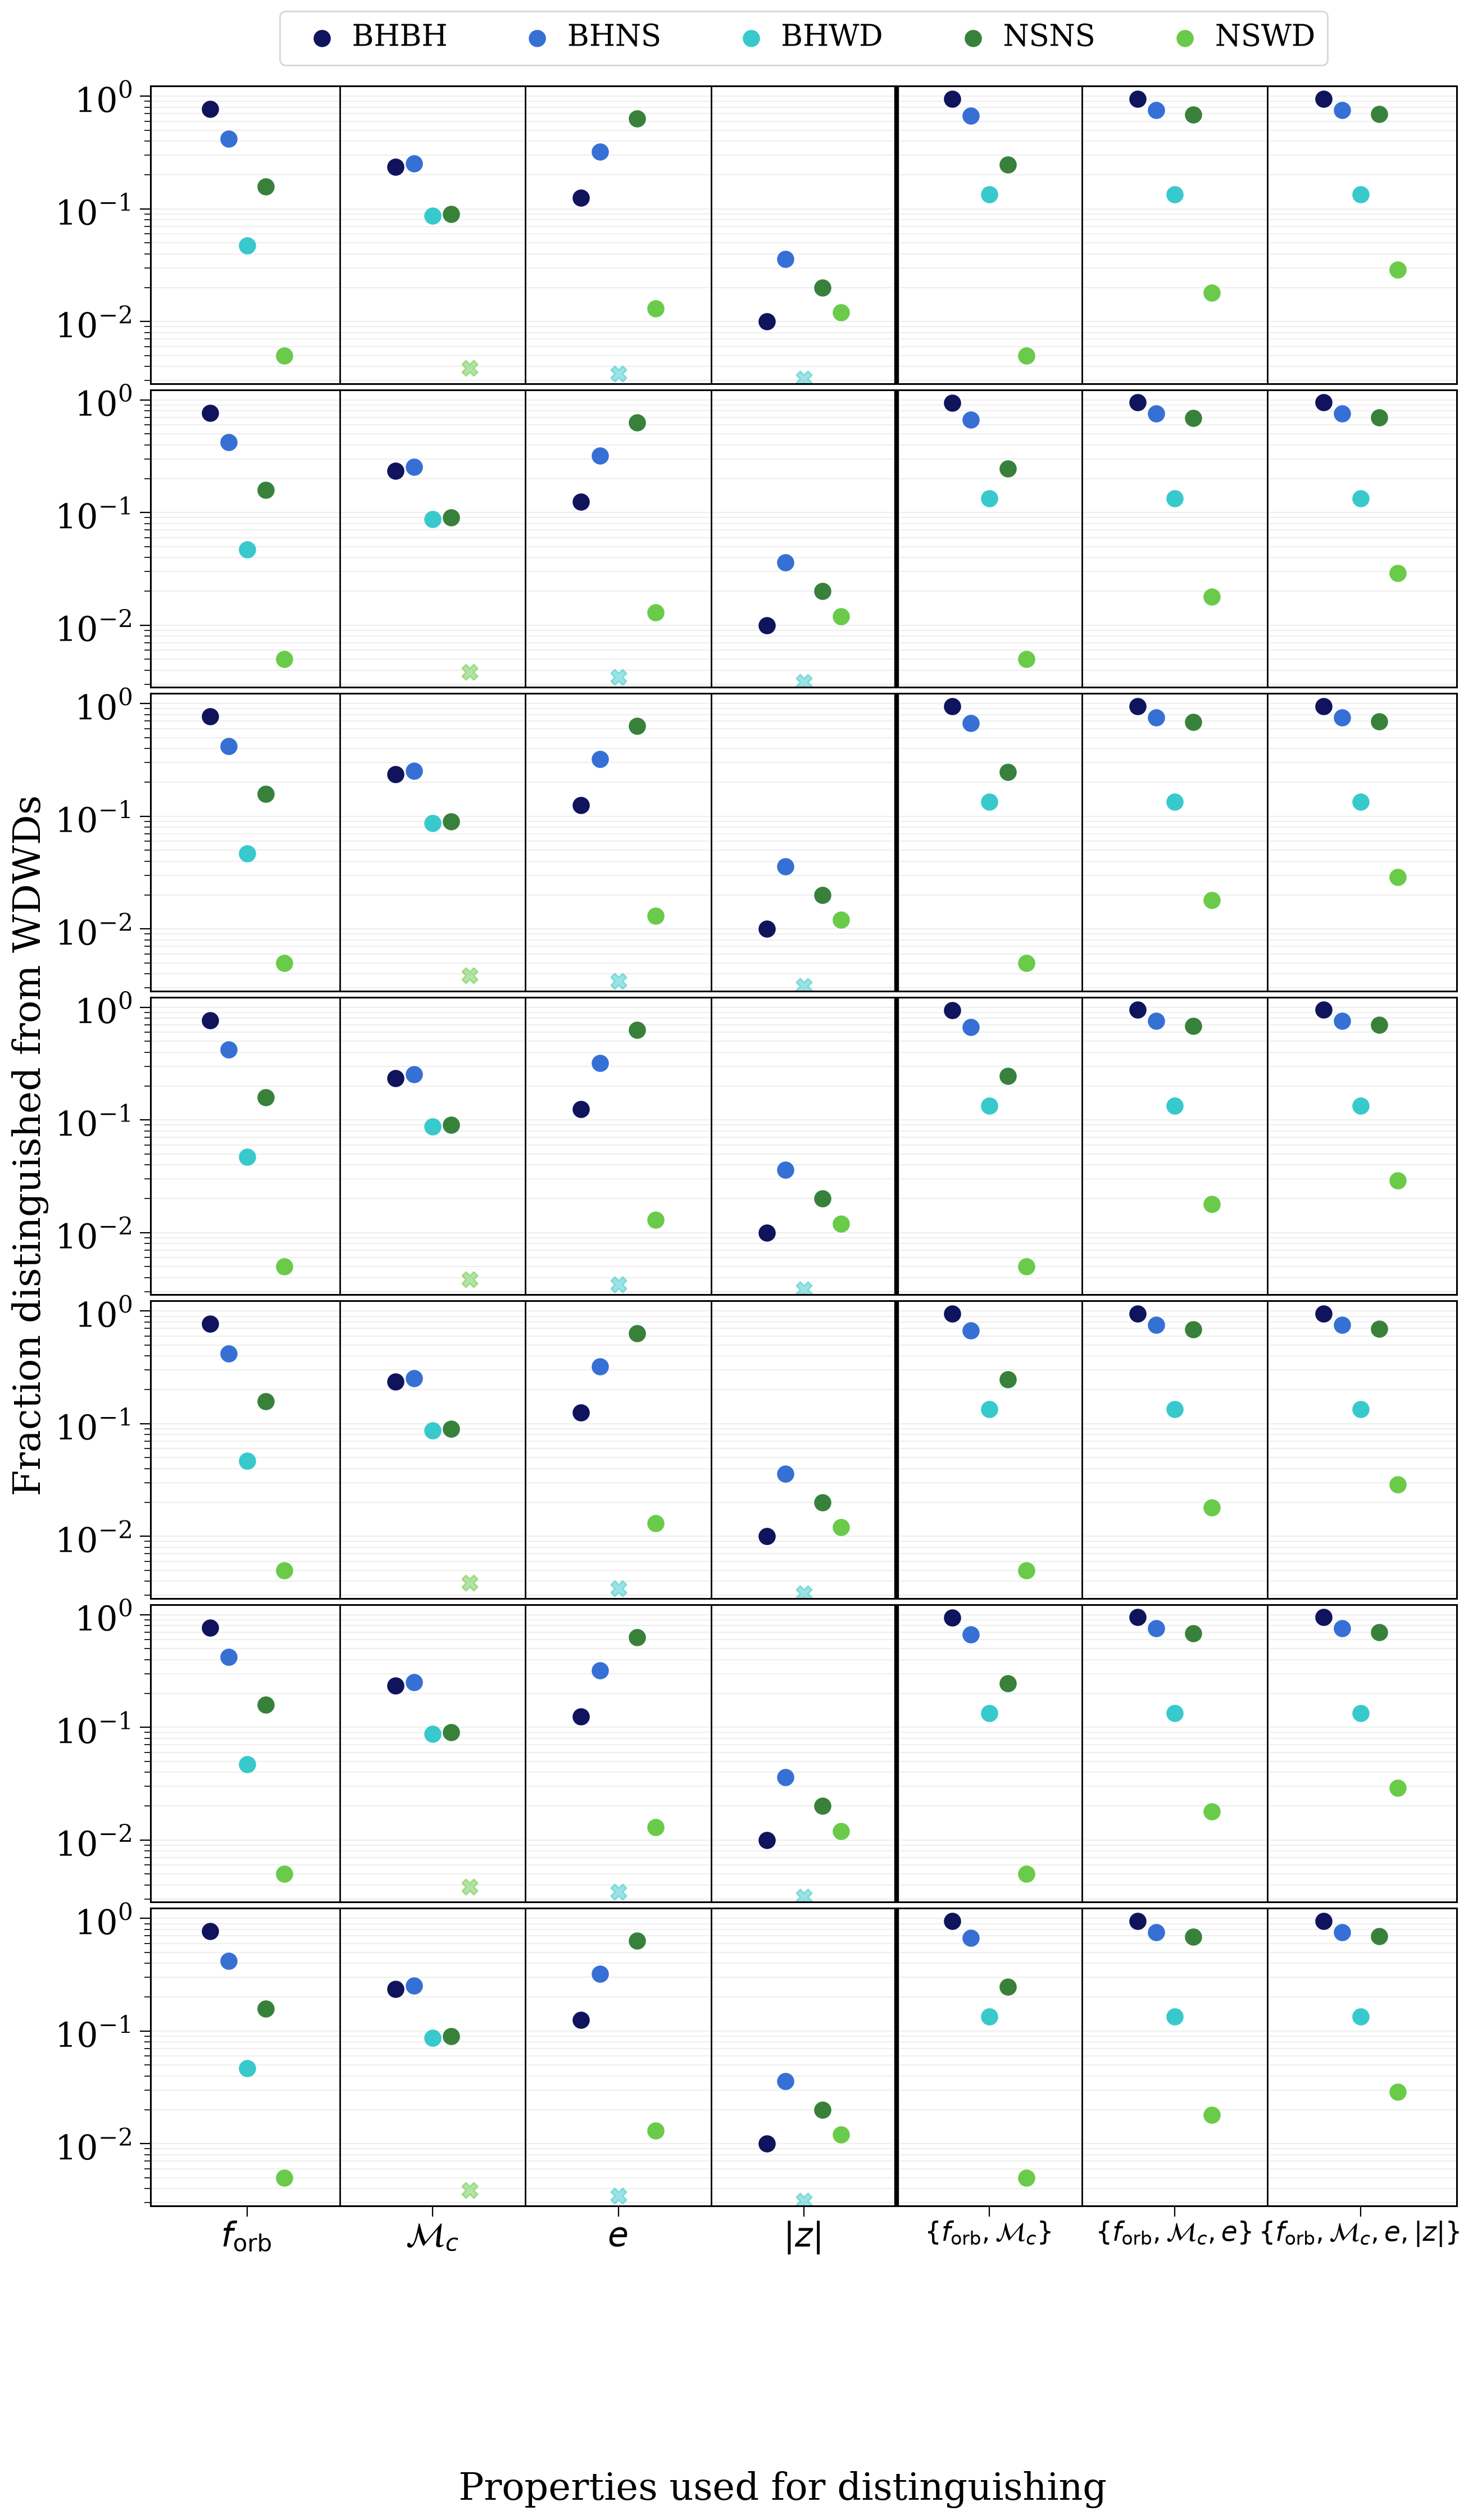

In [93]:
def plot_wdwd_distinguishers(distinguishers, col_labels=[r"$f_{\rm orb}$", r"$\mathcal{M}_c$", r"$e$", r"$|z|$",
                                                         r"$\{f_{\rm orb}, \mathcal{M}_c\}$", r"$\{f_{\rm orb}, \mathcal{M}_c, e\}$",
                                                         r"$\{f_{\rm orb}, \mathcal{M}_c, e, |z|\}$"]):
    fig, axes = plt.subplots(7, 1, figsize=(15, 3.5 * 7))
    
    fig.subplots_adjust(hspace=0.02)

    x_vals = np.arange(len(distinguishers.columns))
    x_offset = 0.1

    zeros = []

    for i, col in enumerate(distinguishers.columns):
        for j, dco_type in enumerate(const.DCO_TYPES):
            x_offseted = x_vals[i] + (j - 2) * x_offset

            for ax in axes:
                ax.scatter(x_offseted, distinguishers[col][dco_type], color=const.DCO_COLOURS[dco_type], s=100, label=dco_type if i == 0 else None)
            if distinguishers[col][dco_type] == 0:
                zeros.append((x_offseted, dco_type))

    for ax in axes:
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_yscale("log")
        ax.grid(which="both", alpha=0.2, axis='y')
        ax.set_axisbelow(True)

        for x in x_vals[:-1]:
            ax.axvline(x + 0.5, color='k', ls="-", lw=3 if x == 3 else 1)
    

    axes[-1].set_xticks(x_vals)

    if col_labels is None:
        col_labels = distinguishers.columns

    for i, l in zip(x_vals, col_labels):
        axes[-1].annotate(l, xy=(i, -0.05), xycoords=("data", "axes fraction"), ha='center', va="top", fontsize=0.9*fs if i < 4 else 0.7 * fs,
                          rotation=0 if i < 4 else 0)

    axes[3].set_ylabel("Fraction distinguished from WDWDs")
    # ax.set_ylim(0, 1)

    axes[0].legend(loc='lower center', ncol=len(const.DCO_TYPES), fontsize=0.8*fs, bbox_to_anchor=(0.5, 1.02), handletextpad=0.0)

    
    fig.supxlabel("Properties used for distinguishing", fontsize=fs, y=0.0)
    

    # put grid below the points

    

    if len(zeros) > 0:
        for x, dco_type in zeros:
            for ax in axes:
                og_ymin, og_ymax = ax.get_ylim()
                ax.scatter(x, og_ymin, color=const.DCO_COLOURS[dco_type], s=100, marker="X", alpha=0.5)
                ax.set_ylim((og_ymin * 0.9, og_ymax))

    return fig, axes

plot_wdwd_distinguishers(distinguishers)

In [ ]:
for dco_type in const.DCO_TYPES:
    print(dco_type)
    w = lisa_4yr_pops[dco_type].initC["weights"]

    # compute the fraction of sources that are too massive to be WDs after accounting for uncertainties in m_c
    max_wd_chirp_mass = lw.utils.chirp_mass(1.44 * u.Msun, 1.44 * u.Msun)
    too_massive = lisa_sources[dco_type].m_c - unc_data[dco_type]["delta_m_c_over_m_c"] * lisa_sources[dco_type].m_c > max_wd_chirp_mass
    print(f"  {w[too_massive].sum() / w.sum():1.2f} of sources are too massive to be WDs")

    # compute the fraction that are too low frequency to be WDs
    min_WD_f_orb = 3e-4 * u.Hz
    too_low_freq = lisa_sources[dco_type].f_orb < min_WD_f_orb
    print(f"  {w[too_low_freq].sum() / w.sum():1.2f} of sources are too low frequency to be WDs")

    # which ones have measurable eccentricity
    measureable_eccentricity_opt = lisa_sources[dco_type].ecc > 0.01
    measureable_eccentricity_pess = unc_data[dco_type]["snr_uncertainty"] < 0.5

    at_least_two_harmonics = unc_data[dco_type]["detectable_harmonics"] > 1
    print(f"  {w[measureable_eccentricity_opt].sum() / w.sum():1.2f} of sources have measureable eccentricity according to Nishizawa+2016")
    print(f"  {w[at_least_two_harmonics].sum() / w.sum():1.2f} of sources have at least two detectable harmonics")

    # far from plane
    far_from_plane = np.abs(lisa_4yr_pops[dco_type].final_pos[:, 2]) - unc_data[dco_type]["sigma_z"] > height_where_exceeds_wdwds[dco_type] * u.kpc
    print(f"  {w[far_from_plane].sum() / w.sum():1.2f} of sources are far enough above the plane to be more likely to be non-WD according to the WDWD distribution")

    f_all = w[too_massive | too_low_freq | at_least_two_harmonics | far_from_plane].sum() / w.sum()
    print(f"  --------------\n  {w[too_massive | too_low_freq | at_least_two_harmonics].sum() / w.sum():1.2f} of {dco_type}s match at least one of the above criteria for being a non-WD DCO")
    print(f"  --------------\n  {f_all:1.2f} of {dco_type}s ({f_all * counts[dco_type]:.0f}) match at least one of the above criteria for being a non-WD DCO")
    print("  --------------")

BHBH
  0.24 of sources are too massive to be WDs
  0.77 of sources are too low frequency to be WDs
  0.64 of sources have measureable eccentricity according to Nishizawa+2016
  0.06 of sources have at least two detectable harmonics
  0.01 of sources are far enough above the plane to be more likely to be non-WD according to the WDWD distribution
  --------------
  0.95 of BHBHs match at least one of the above criteria for being a non-WD DCO
  --------------
  0.95 of BHBHs (40) match at least one of the above criteria for being a non-WD DCO
  --------------
BHNS
  0.25 of sources are too massive to be WDs
  0.42 of sources are too low frequency to be WDs
  0.84 of sources have measureable eccentricity according to Nishizawa+2016
  0.14 of sources have at least two detectable harmonics
  0.04 of sources are far enough above the plane to be more likely to be non-WD according to the WDWD distribution
  --------------
  0.69 of BHNSs match at least one of the above criteria for being a non-

# Old

(0.0, 1.0)

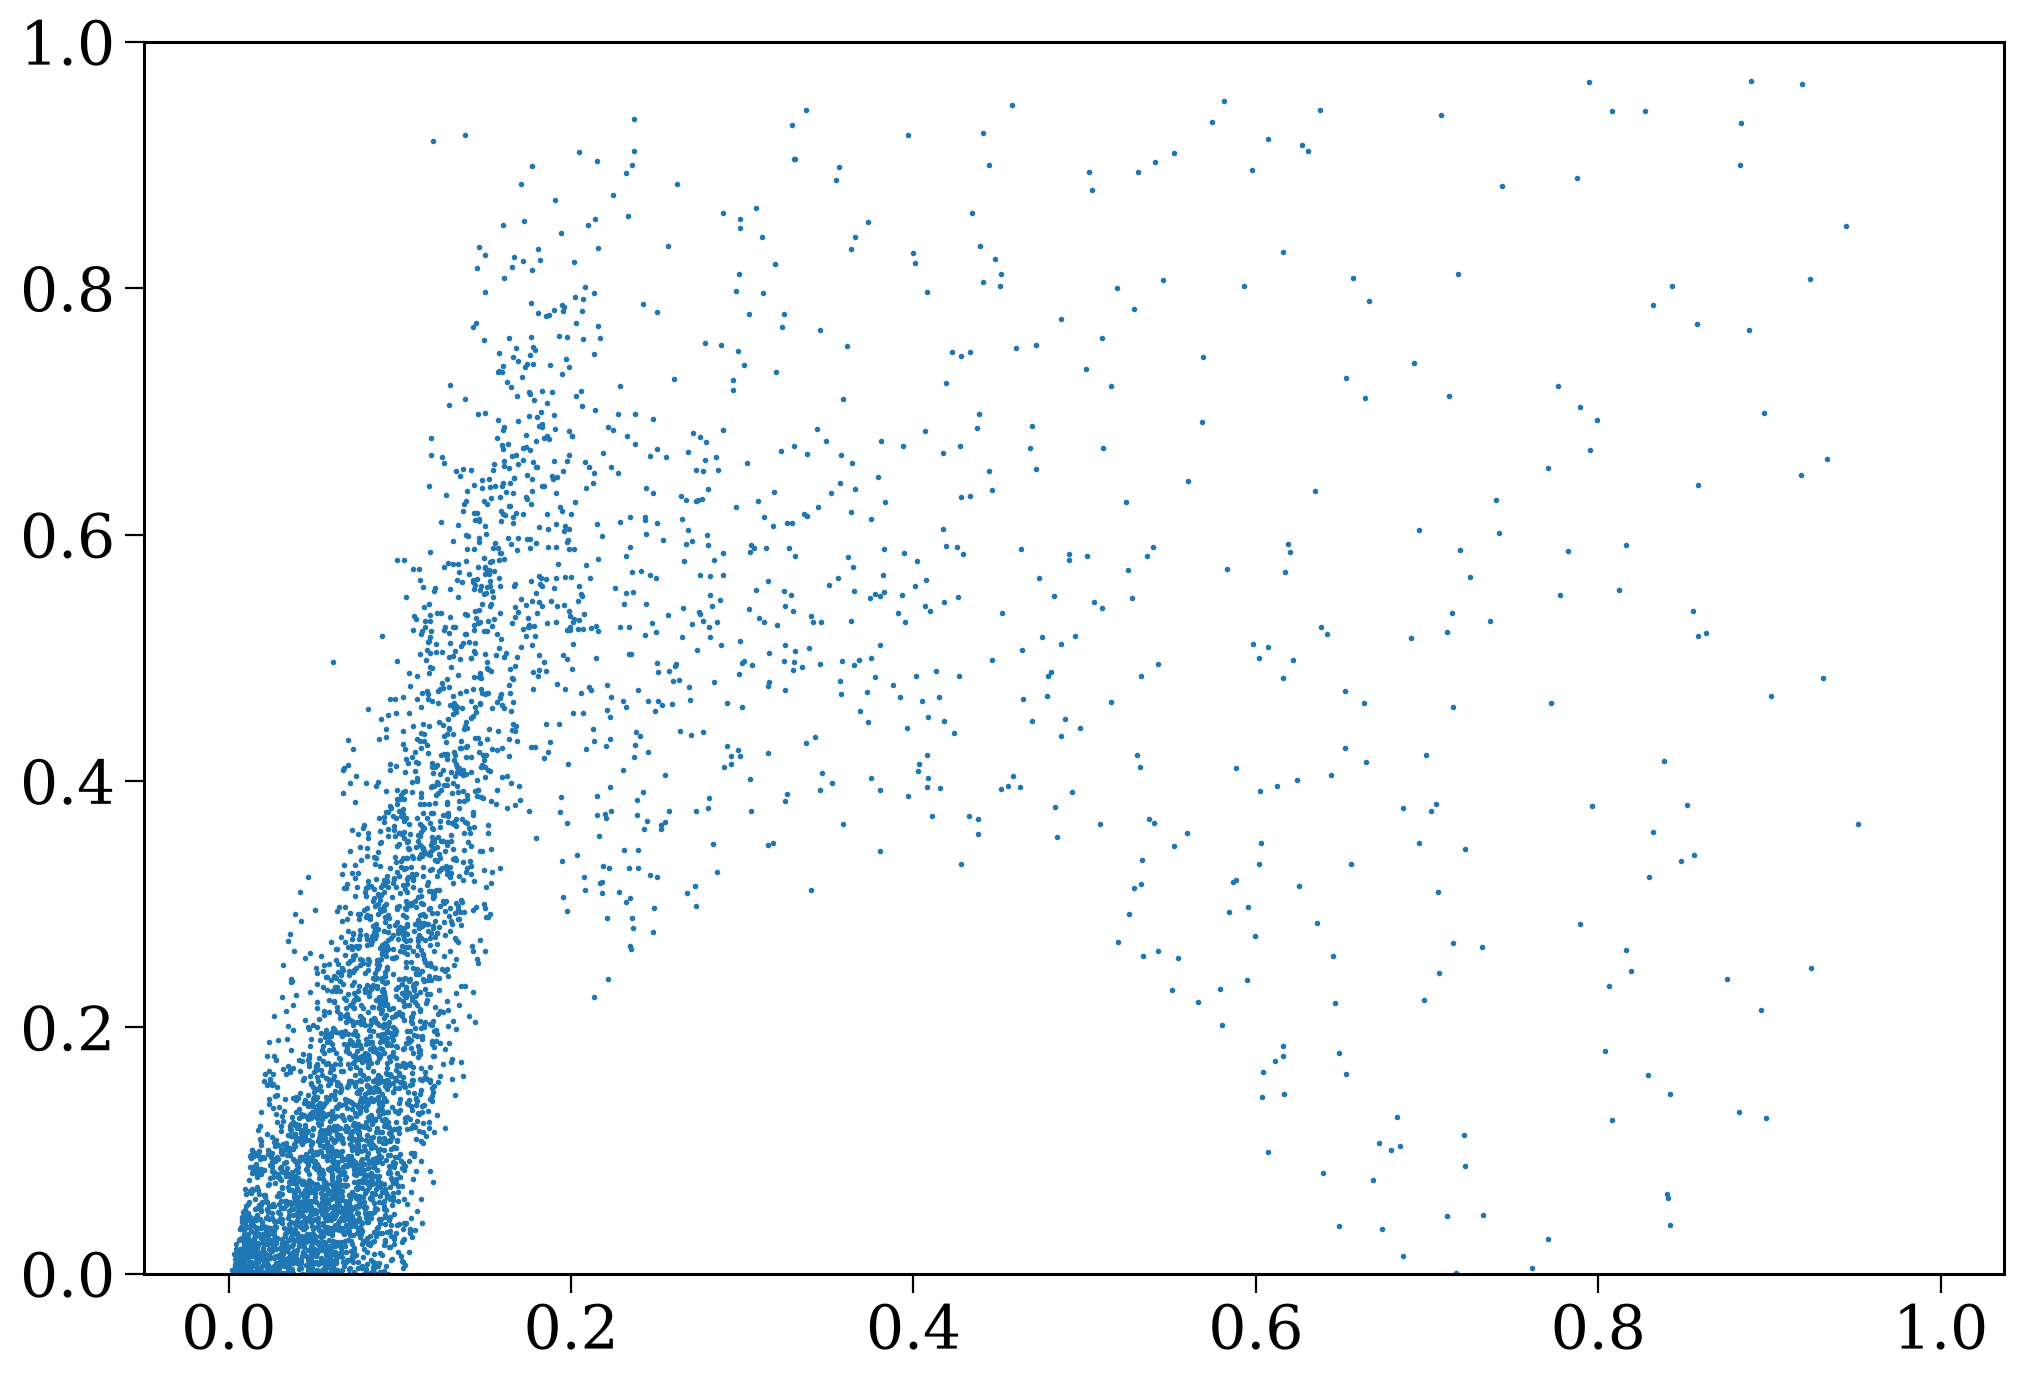

In [ ]:
plt.scatter(lisa_sources["BHBH"].ecc, (unc_data["BHBH"]["snr_ratio"] - unc_data["BHBH"]["snr_uncertainty"]), s=1)
plt.ylim(0, 1)

In [47]:
def nishizawa_uncertainty(dist, m_c, ecc):
    eps0 = 2.2e-6
    eps0=1e-5
    gamma_m = 2.19
    gamma_e = 1.5
    return (eps0 * (dist / (400 * u.Mpc)) * (30 * u.Msun / m_c)** gamma_m * (0.1 / ecc)**gamma_e).decompose()

Text(0, 0.5, '$\\Delta e / e$')

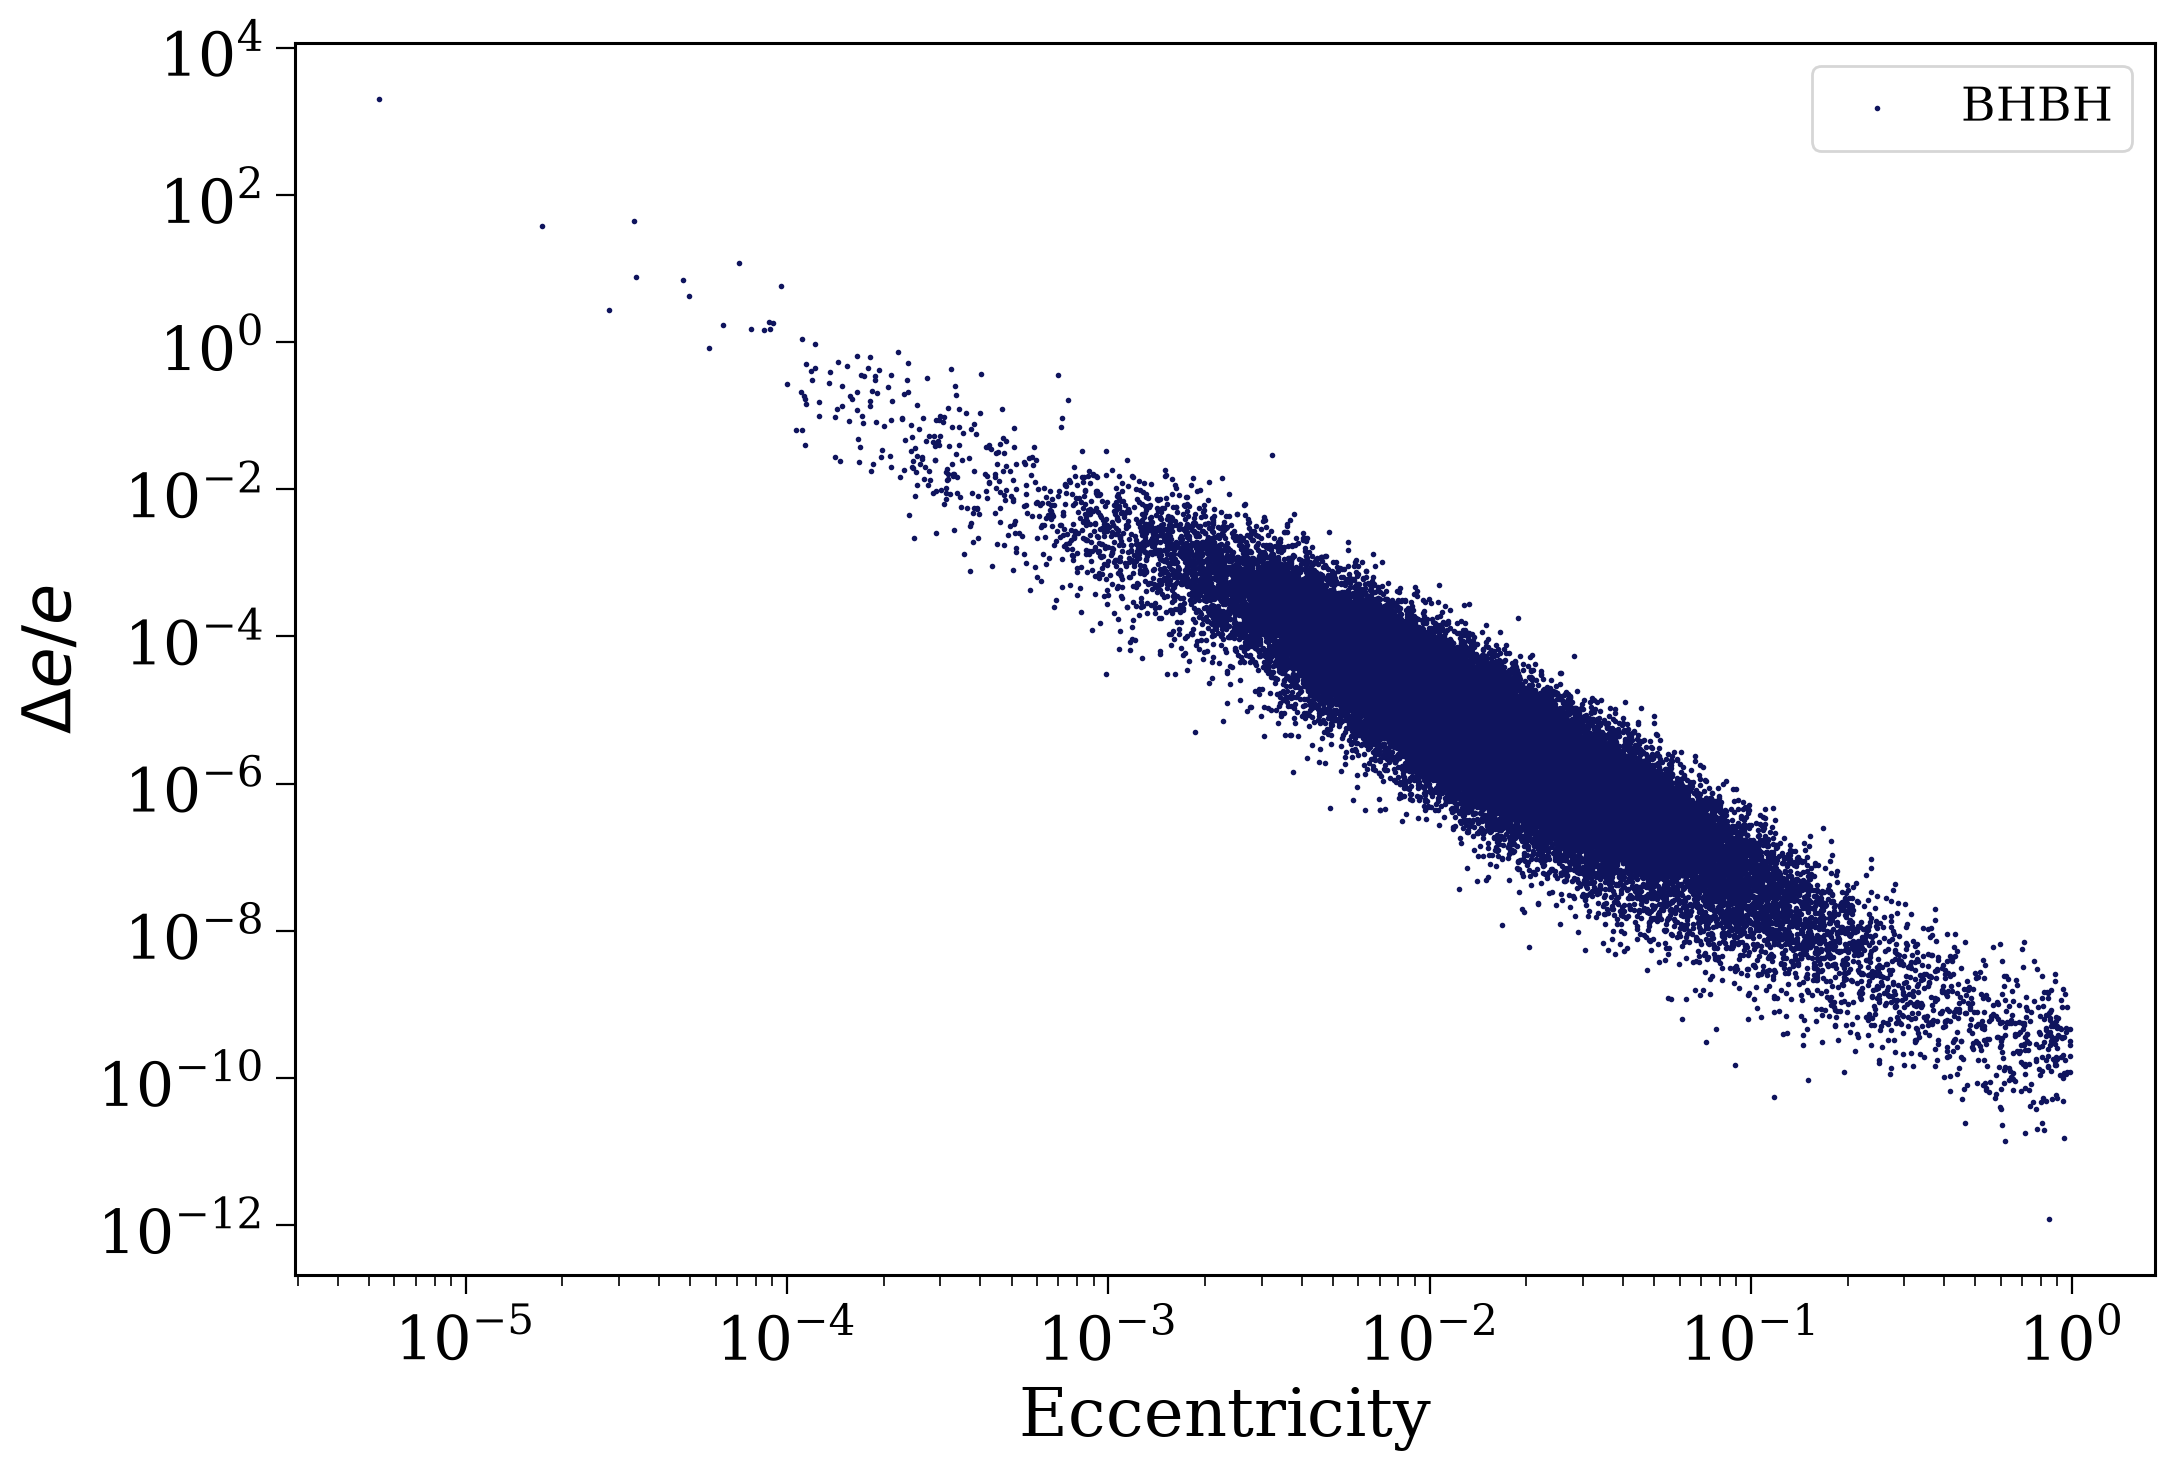

In [ ]:
dco_type = "BHBH"
plt.scatter(lisa_sources[dco_type].ecc, nishizawa_uncertainty(lisa_sources[dco_type].dist, lisa_sources[dco_type].m_c, lisa_sources[dco_type].ecc) / lisa_sources[dco_type].ecc, s=1, c=const.DCO_COLOURS[dco_type], label=dco_type)
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.xlabel("Eccentricity")
plt.ylabel(r"$\Delta e / e$")

(0.0, 2.0)

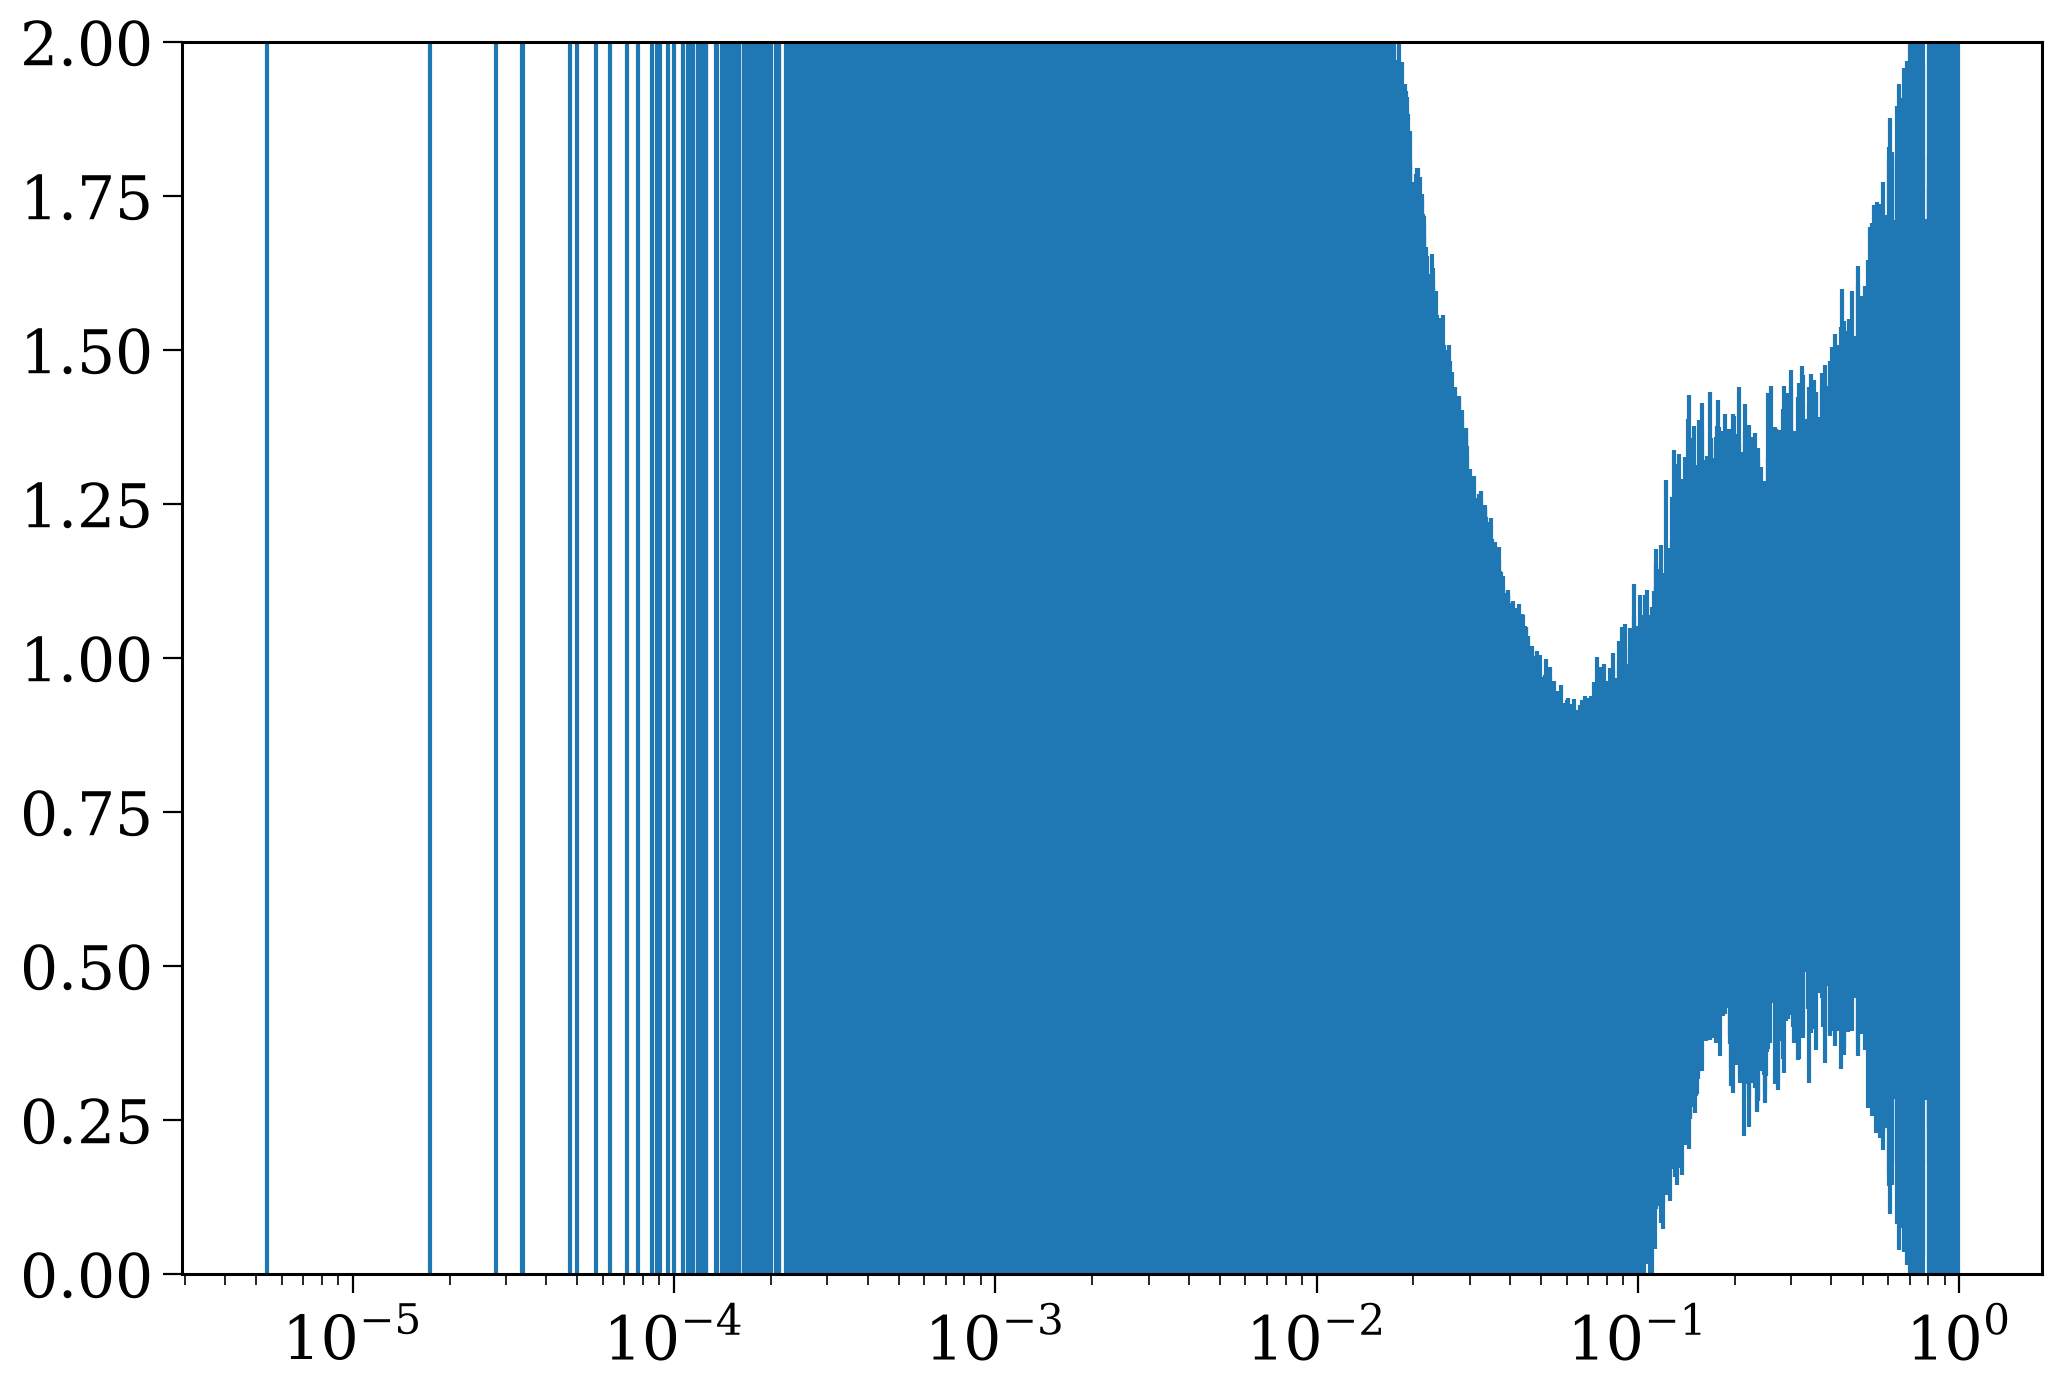

In [ ]:
plt.errorbar(lisa_sources["BHBH"].ecc, unc_data["BHBH"]["snr_ratio"], yerr=unc_data["BHBH"]["snr_uncertainty"], linestyle="none")
plt.xscale("log")
plt.ylim(0, 2)

BHBH
BHNS
BHWD


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7487: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7488: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: It looks like the provided 'range' is not valid or the sample is empty.

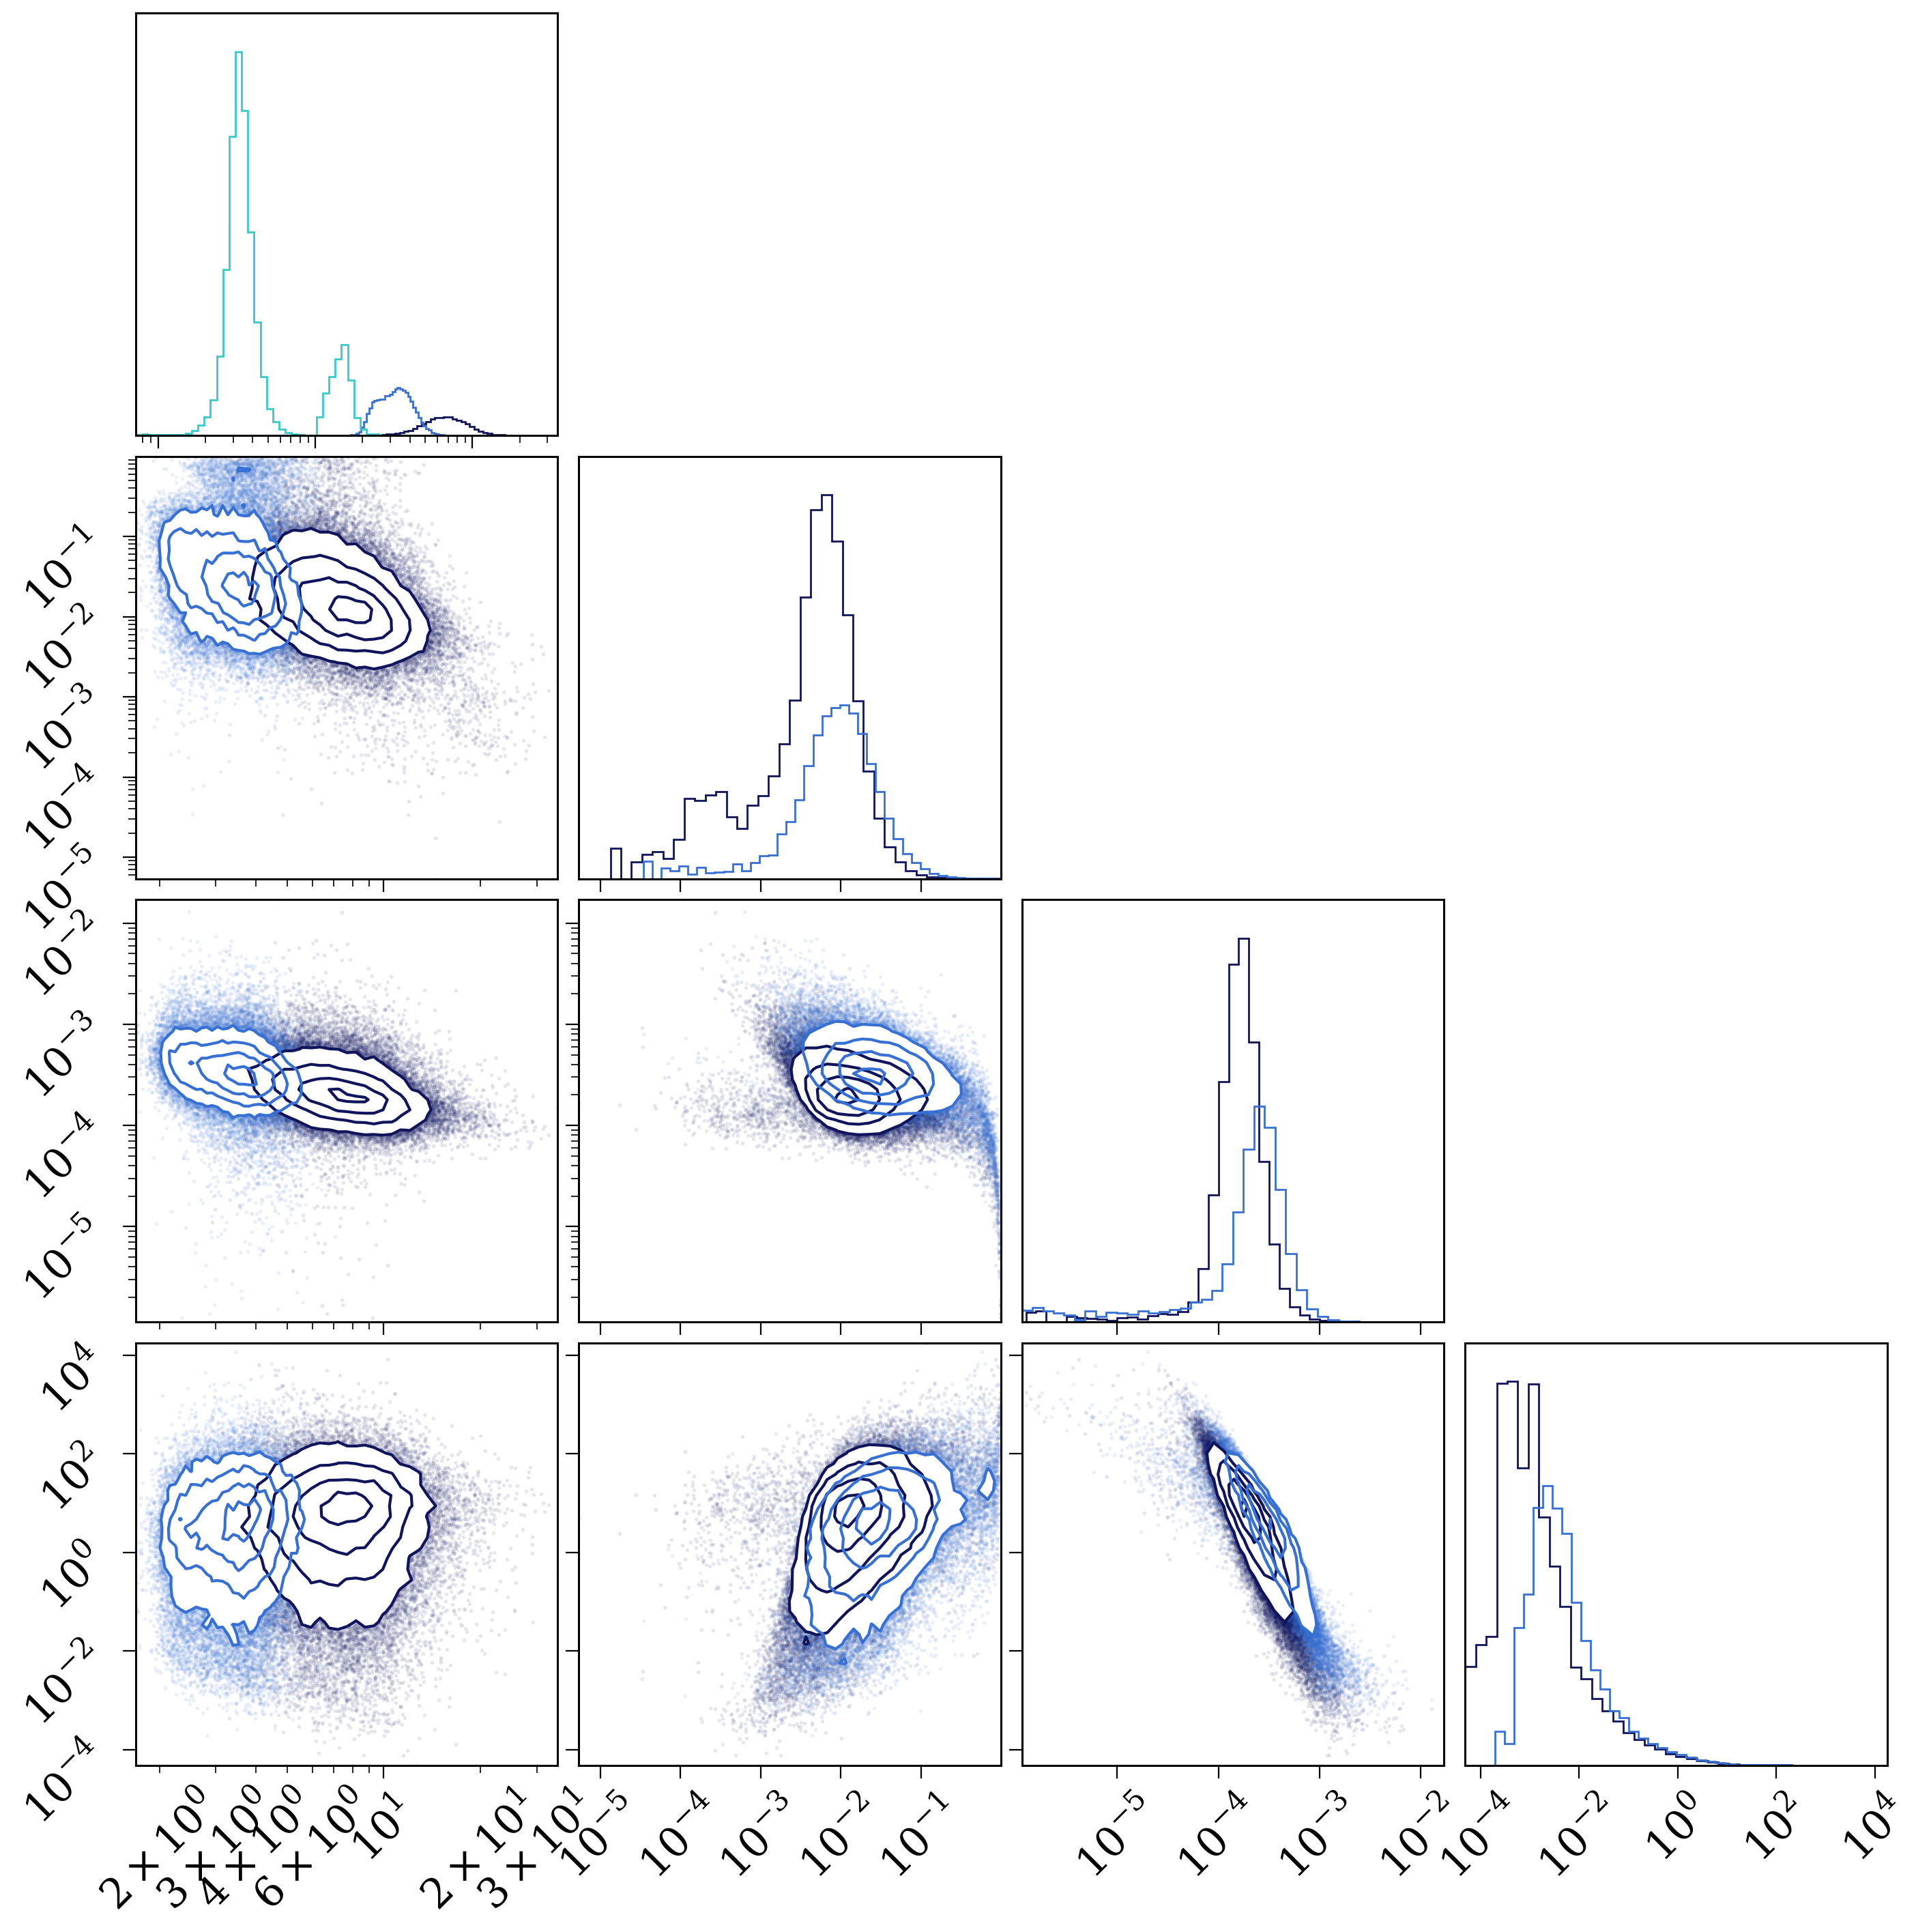

In [ ]:
fig = plt.figure(figsize=(15, 15))

for dco_type in const.DCO_TYPES:
    print(dco_type)
    corner.corner(
        np.vstack([
            lisa_sources[dco_type].m_c.value,
            lisa_sources[dco_type].ecc if dco_type != "BHWD" else np.full(len(lisa_sources[dco_type].ecc), np.nan),
            lisa_sources[dco_type].f_orb.value,
            unc_data[dco_type]["delta_m_c_over_m_c"].value,
        ]).T,
        # range=[
        #     (0.1, 30),
        #     (1e-4, 1),
        #     (1e-5, 1e-2),
        #     (1e-8, 1e1)
        # ],
        axes_scale="log",
        color=const.DCO_COLOURS[dco_type],
        bins=40,
        fig=fig,
        plot_datapoints=True,
        plot_density=False,
        hist_kwargs={"density": True}
    )
    # break

plt.show()

In [17]:
unc_data["BHBH"]

{'snr_uncertainty': array([2.29055275, 0.31059587, 1.35273674, ..., 0.90499006, 1.37498169,
        0.60371407], shape=(50559,)),
 'snr_ratio': array([0.05418354, 0.48661857, 0.11054922, ..., 0.09291536, 0.08643689,
        0.16276274], shape=(50559,)),
 'detectable_harmonics': array([1, 2, 1, ..., 1, 1, 1], shape=(50559,)),
 'max_harmonics': array([2, 2, 2, ..., 2, 2, 2], shape=(50559,)),
 'delta_m_c_over_m_c': <Quantity [ 3.7822038 ,  3.10091156, 12.86159703, ..., 10.38988222,
            13.53569636,  9.86730712]>,
 'sigma_theta': <Quantity [15.5589149 ,  8.84638047, 18.08667187, ..., 14.66362682,
            18.21846068, 13.13509514] deg>,
 'delta_d_over_d': <Quantity [ 2.76188269,  2.37337838,  9.78716014, ...,  7.95365036,
            10.3424394 ,  7.56514724]>}

False
0.13079713385697186


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


False
0.4206441630107513
False
0.6452624672302932
False
0.8458384277820769
False
0.9298974520796098


[(0.0, 0.6256219710865115)]

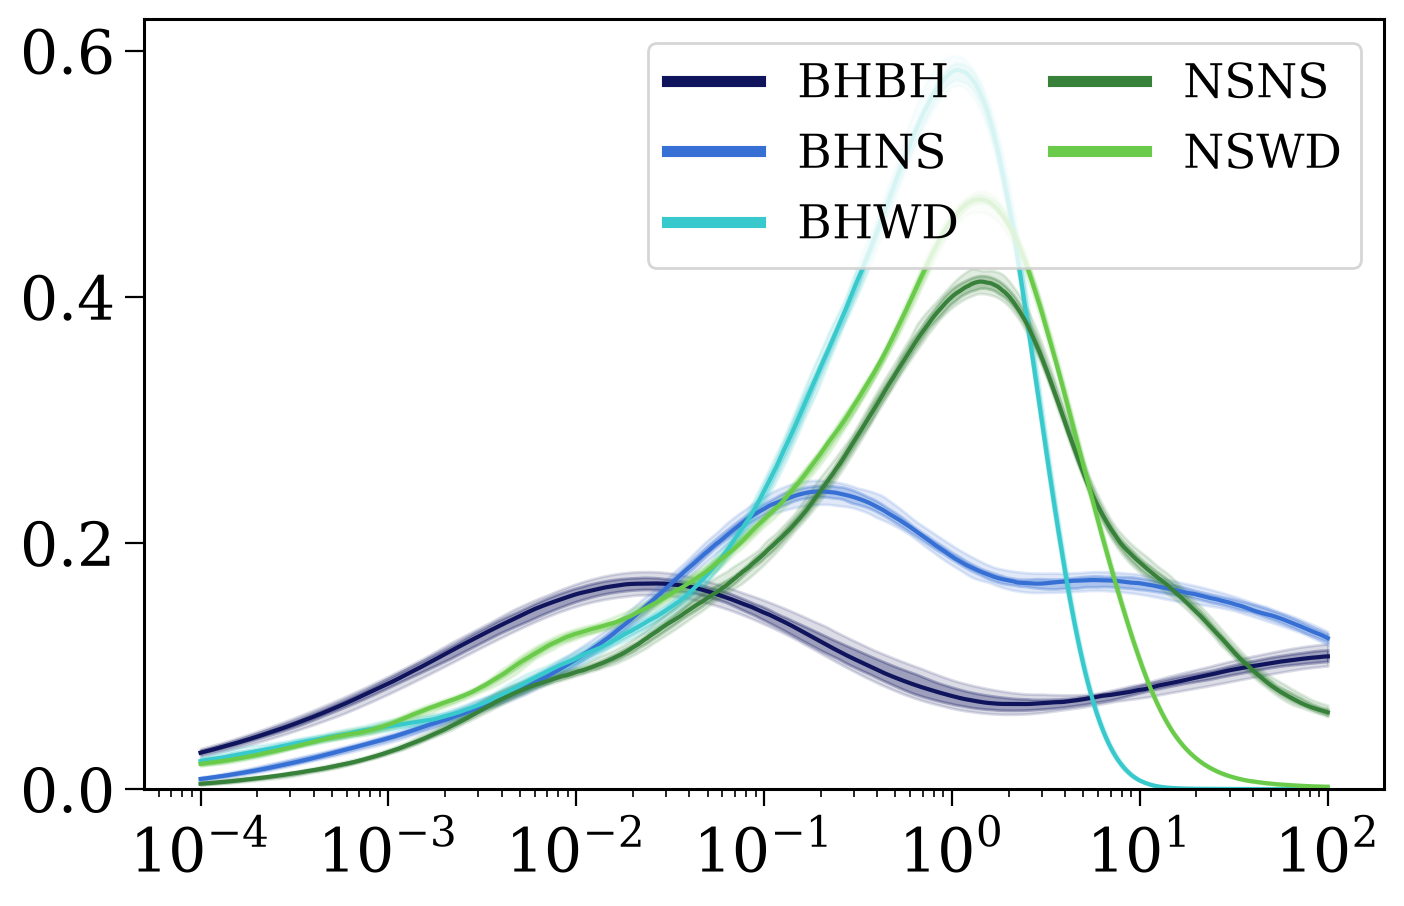

In [ ]:
reload(plotting)
reload(unc)

fig, ax = plt.subplots(figsize=(8, 5))

for dco_type in const.DCO_TYPES:
    s = detectable_sources[dco_type][detectable_pops[dco_type].bpp["snr_lisa_4yr_final_pos"] > 7]
    w = lisa_4yr_pops[dco_type].initC["weights"]
    snr_uncertainty, snr_ratio, detectable_harmonics, max_harmonics = unc.get_ecc_uncertainty_stats(s, harmonic_threshold=2)
    print(np.isnan(snr_uncertainty).any())
    sigma_m_c = unc.get_m_c_uncertainty(
        s.f_orb,
        lw.utils.fn_dot(s.m_c, s.f_orb, s.ecc, n=1),
        s.ecc,
        snr_uncertainty,
        s.snr,
        4 * u.yr
    )
    mask = np.isfinite(np.log10(sigma_m_c))
    print(np.sum(w[mask]) / np.sum(w))
    # plt.hist(np.log10(s.m_c.value), bins=np.linspace(np.log10(0.3), np.log10(30), 100), weights=w, label=dco_type, histtype="step", lw=2.5, color=const.DCO_COLOURS[dco_type], density=True)
    plotting.bootstrapped_kde_fast(
        variable=np.log10(sigma_m_c[mask]), weights=w.values[mask], ax=ax, x_min=-4, x_max=2, bootstraps=50, x_count=500, bw_adjust=1, color=const.DCO_COLOURS[dco_type], label=dco_type
    )



plotting.fake_log_axis(ax, axis="x")

handles, labels = ax.get_legend_handles_labels()
handles = [copy(h) for h in handles]
for h in handles:
    h.set_linewidth(4)
ax.legend(handles, labels, loc="upper right", ncol=2)

ax.set(
    # xlabel=r"Chirp mass, $\log_{10}(\mathcal{M}_c / {\rm M_\odot})$",
    # ylabel=r"${\rm d}N / {\rm d}\log_{10}(\mathcal{M}_c / {\rm M_\odot})$",
    # xlim=(-4, 0),
    ylim=(0, None)
)

# plt.savefig("../plots/m_chirp_lisa.pdf", bbox_inches="tight")

In [276]:
import uncertainties as unc
snr_uncertainty, snr_ratio, detectable_harmonics, max_harmonics = unc.get_ecc_uncertainty_stats(sources, harmonic_threshold=2)
min_ratio = np.clip(snr_ratio - snr_uncertainty, 0, None)

NameError: name 'sources' is not defined

In [73]:
sigma_m_c = unc.get_m_c_uncertainty(
    sources.f_orb,
    lw.utils.fn_dot(sources.m_c, sources.f_orb, sources.ecc, n=1),
    sources.ecc,
    snr_uncertainty,
    sources.snr,
    4 * u.yr
)
sky_localisation = unc.sky_localisation(
    sources.snr,
    sources.f_orb * 2,
)

In [54]:
(sigma_m_c < 1).sum() / len(sources)

np.float64(0.2820031144177769)

In [81]:
theta = np.arctan(np.abs(pop.final_pos[:, 2]) / sources.dist).to(u.deg)
sigma_theta = sky_localisation / theta

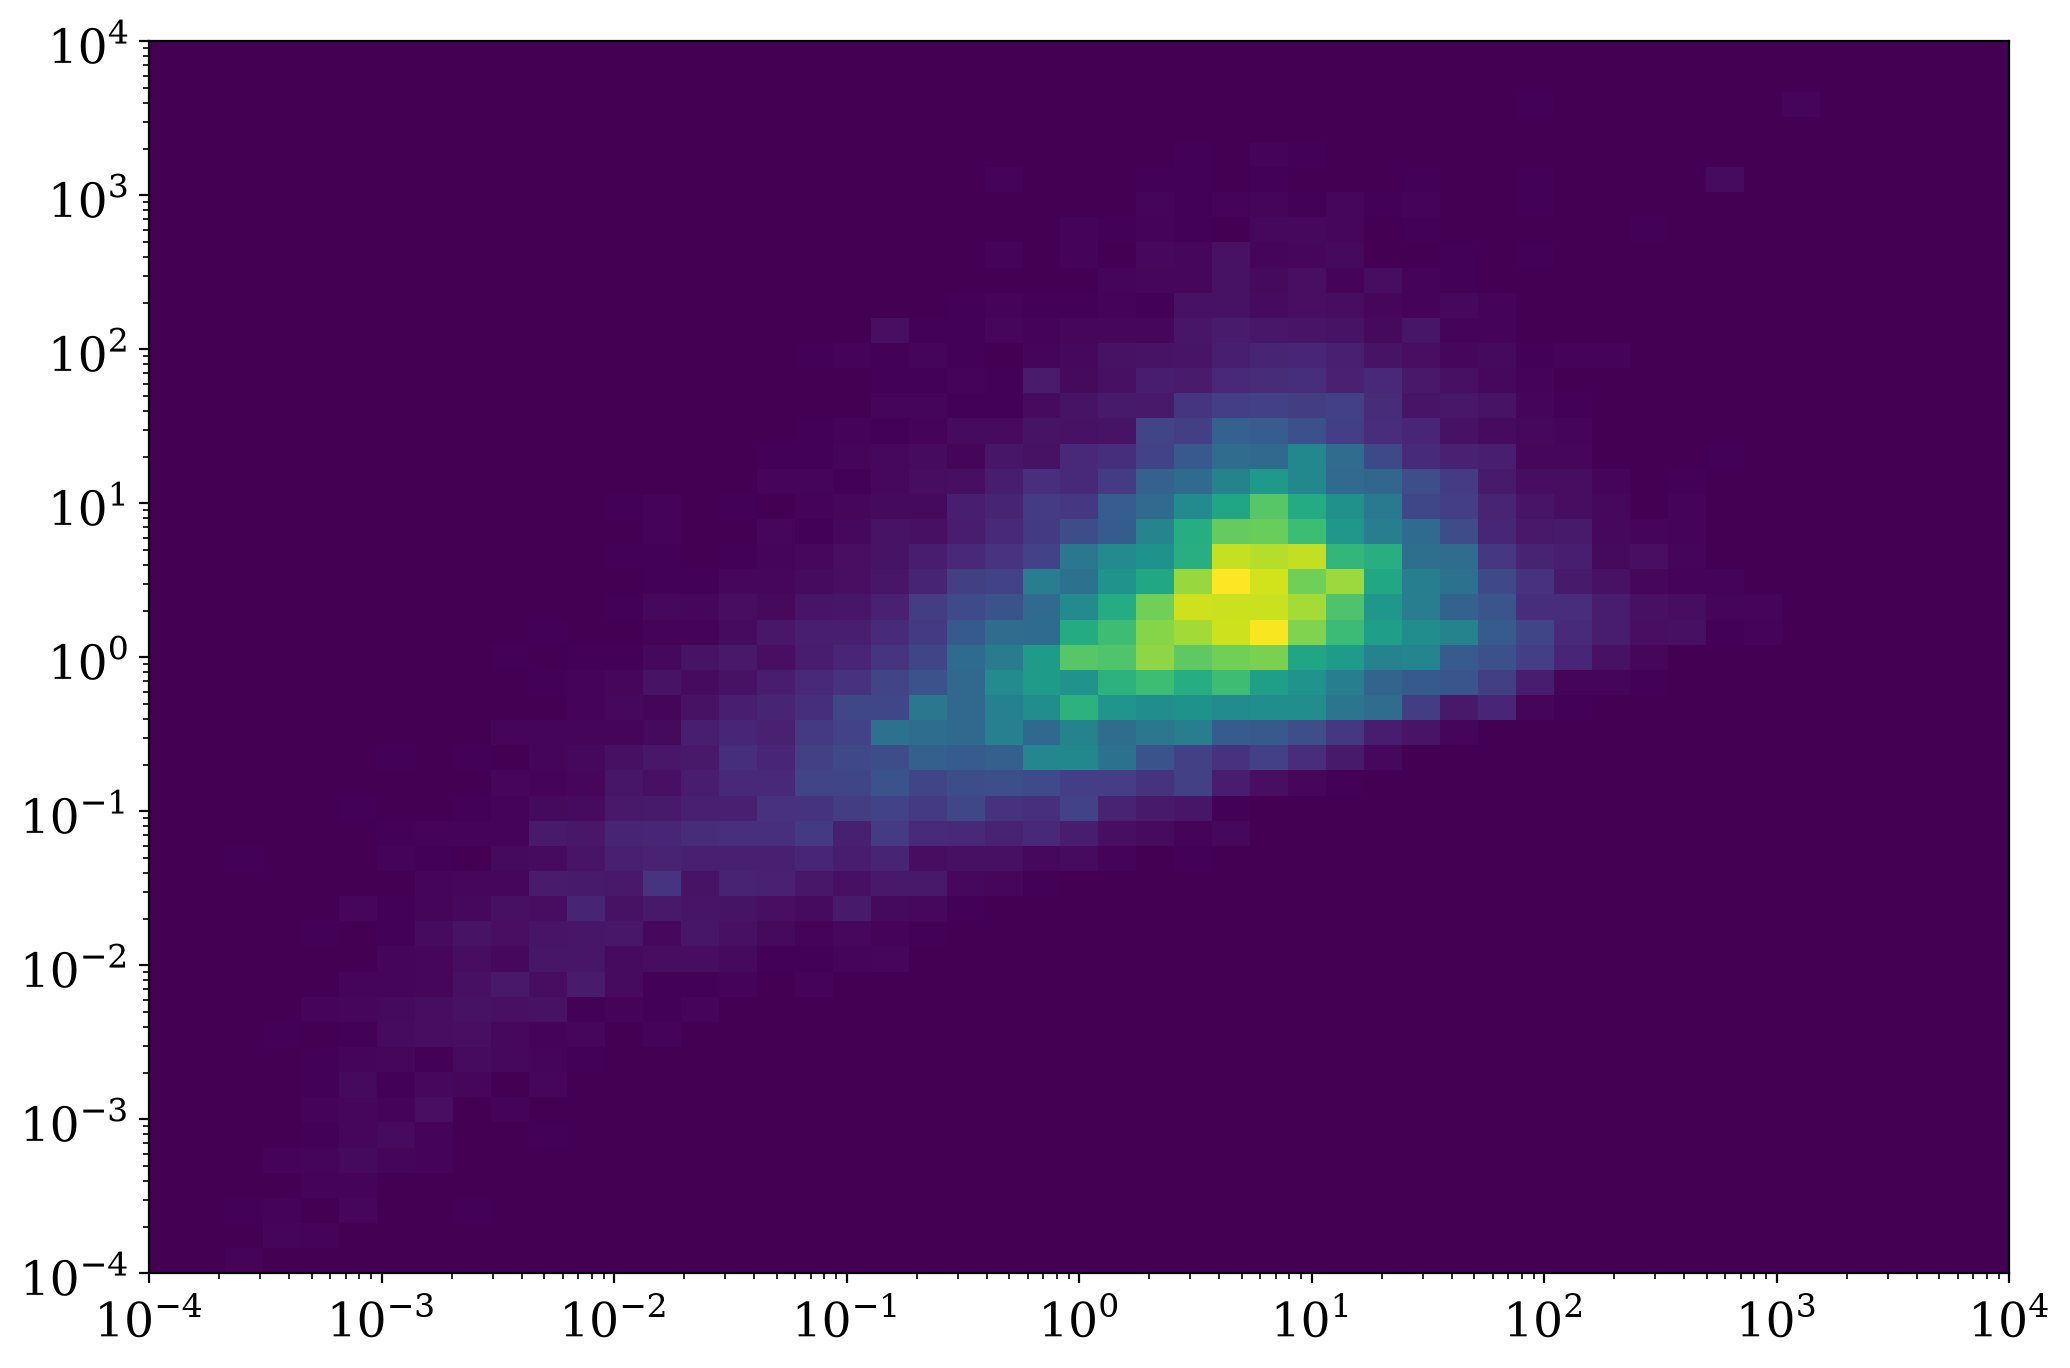

In [109]:
fig, ax = plt.subplots()

# ax.scatter(sigma_m_c, sigma_theta, s=10 * pop.initC["weights"])
ax.hist2d(
    sigma_m_c, sigma_theta, weights=pop.initC["weights"],
    bins=(np.logspace(-4, 4, 50), np.logspace(-4, 4, 50)),
)

ax.set(
    xscale="log", yscale="log"
)

plt.show()

In [92]:
massive = (sources.m_c - sigma_m_c * sources.m_c) > 1.2 * u.Msun
np.sum(pop.initC["weights"][massive]) / np.sum(pop.initC["weights"])

np.float64(0.26309124575862025)

In [93]:
away_from_plane = np.arcsin(1 * u.kpc / sources.dist) - sky_localisation > 0 * u.deg
np.sum(pop.initC["weights"][away_from_plane]) / np.sum(pop.initC["weights"])

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in arcsin
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)



np.float64(0.35030998842773653)

[None, None]

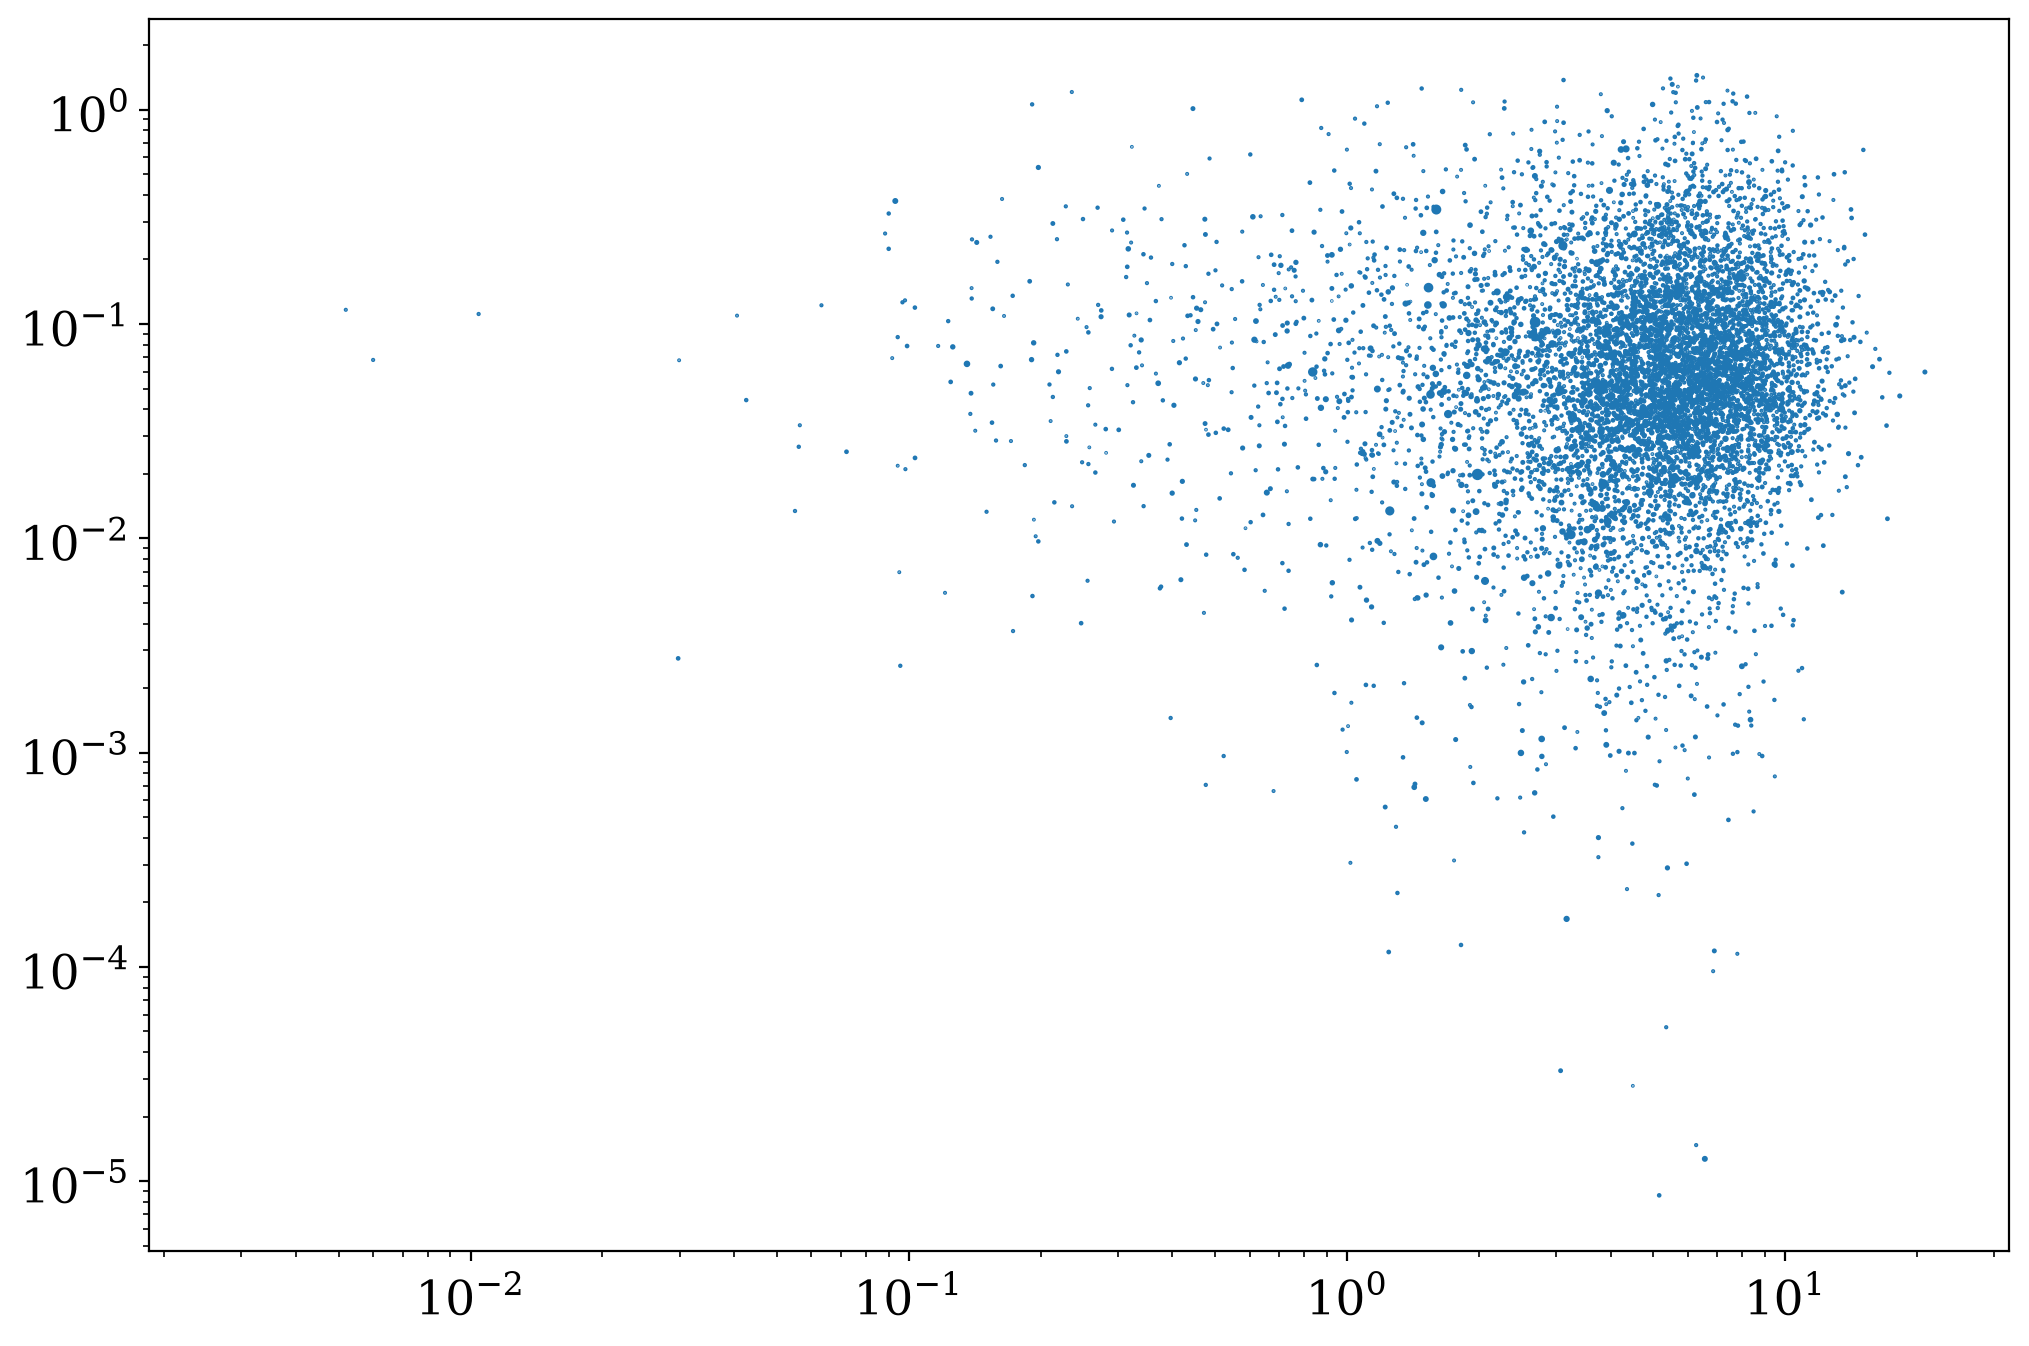

In [94]:
fig, ax = plt.subplots()

ax.scatter(sources.m_c - sigma_m_c * sources.m_c - 1.2 * u.Msun, np.arcsin(1 * u.kpc / sources.dist) - sky_localisation, s=10 * pop.initC["weights"])

ax.set(
    xscale="log", yscale="log"
)

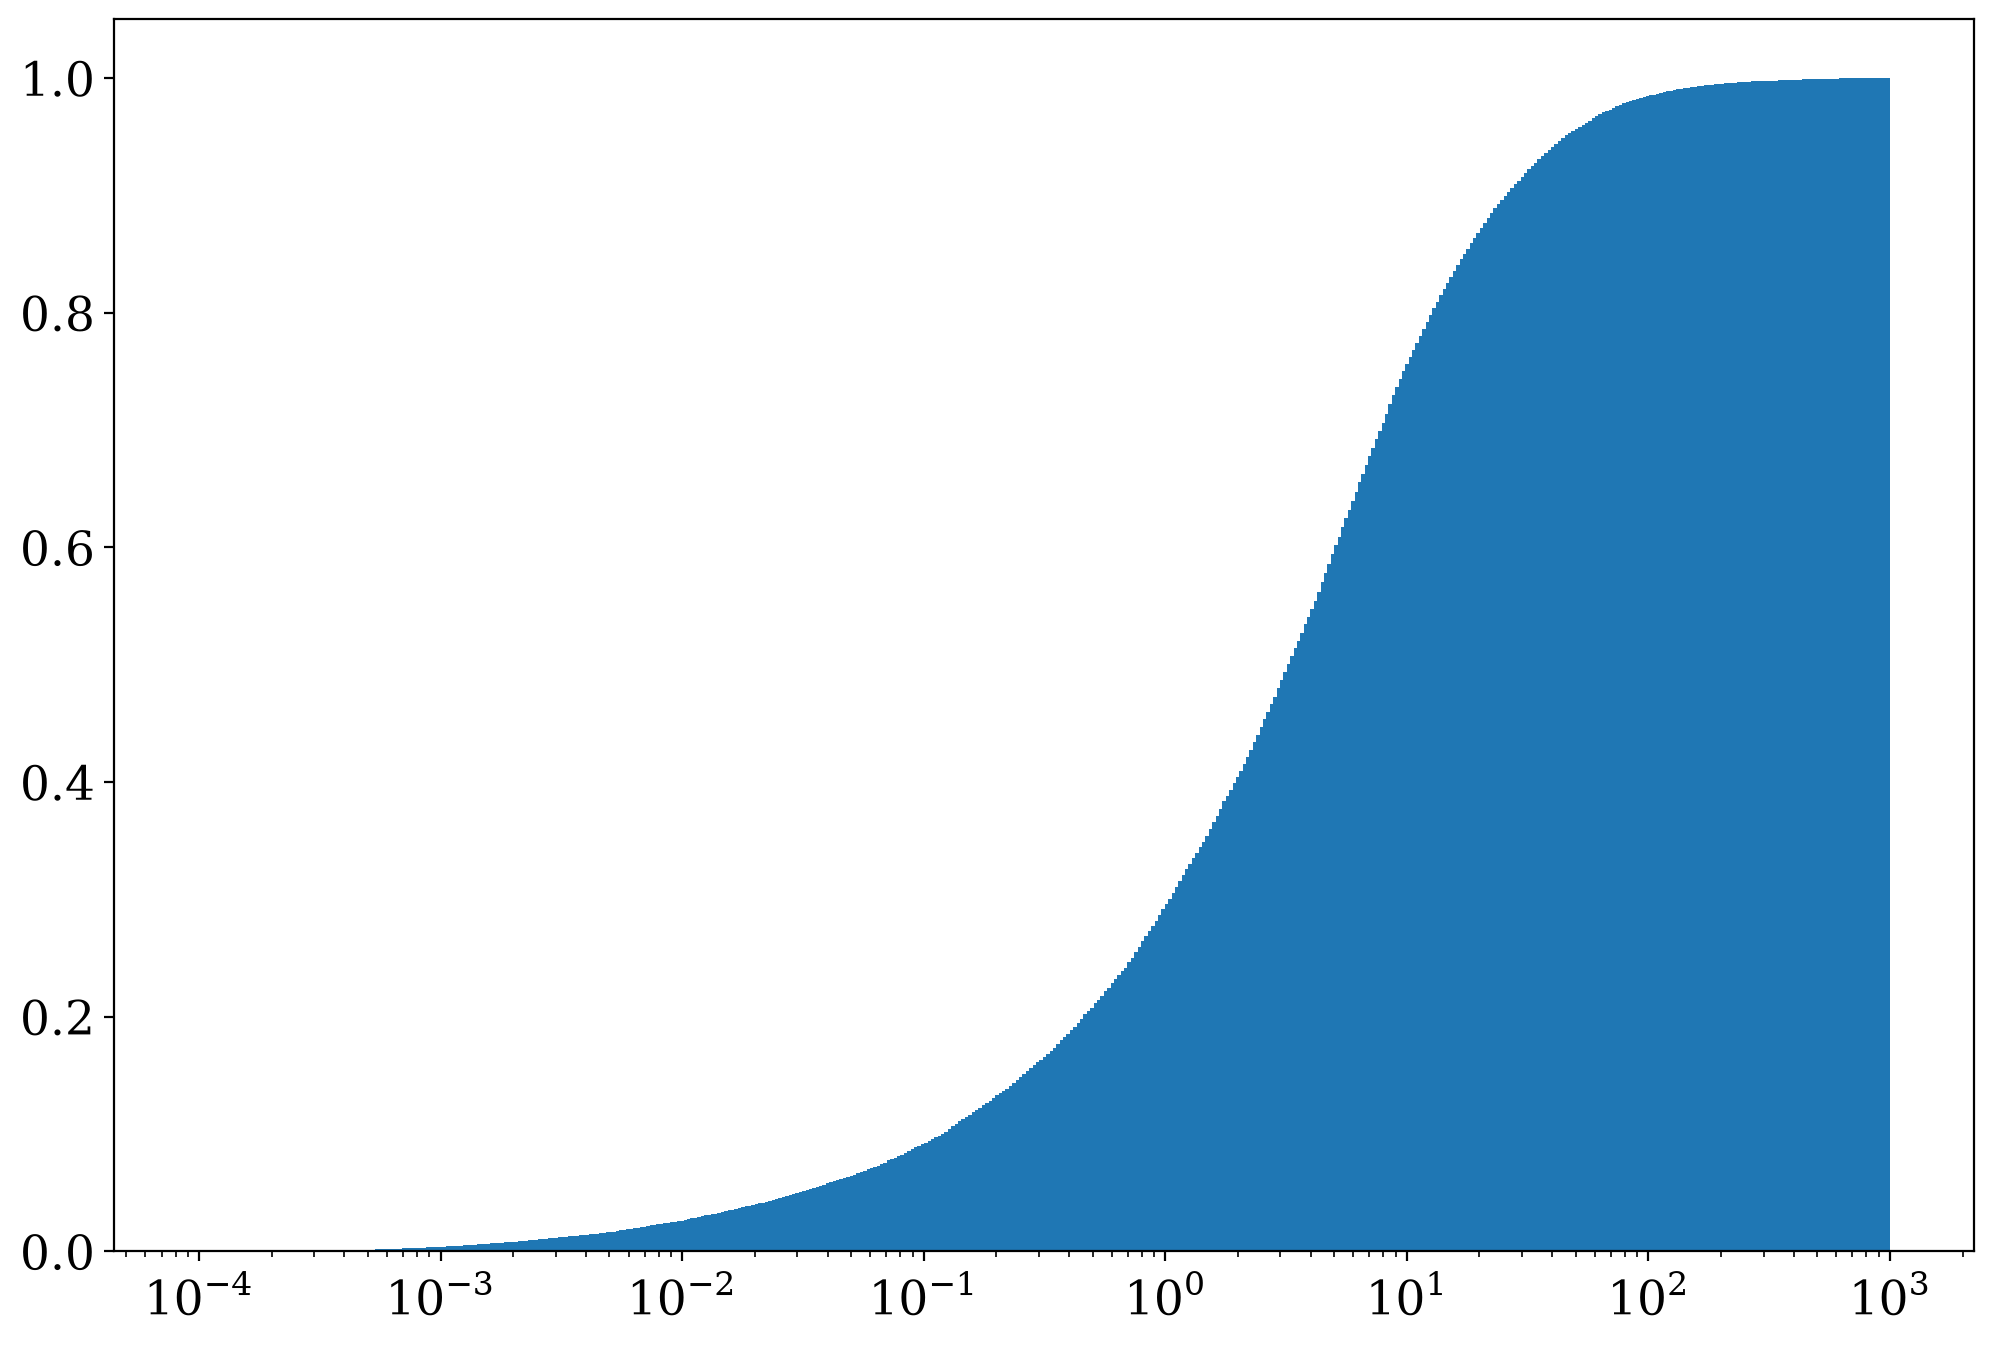

In [56]:
plt.hist(sigma_m_c, cumulative=True, bins=np.logspace(-4, 3, 500), density=True, weights=pop.initC["weights"])
plt.xscale("log")

In [45]:
ranges = [(0, 1), (1e-3, 1), (0.01, 1), (0.1, 1)]
for lo, hi in ranges:
    in_range = min_ratio[(min_ratio >= lo) & (min_ratio <= hi)]
    in_range_dh = detectable_harmonics[(min_ratio >= lo) & (min_ratio <= hi)]
    in_range_weights = pop.initC["weights"][(min_ratio >= lo) & (min_ratio <= hi)]
    print(np.sum(in_range_weights[((in_range > 1e-2) & (in_range_dh >= 2))]) / np.sum(in_range_weights) * 100)

2.348066994123517
94.6580839559977
100.0
100.0


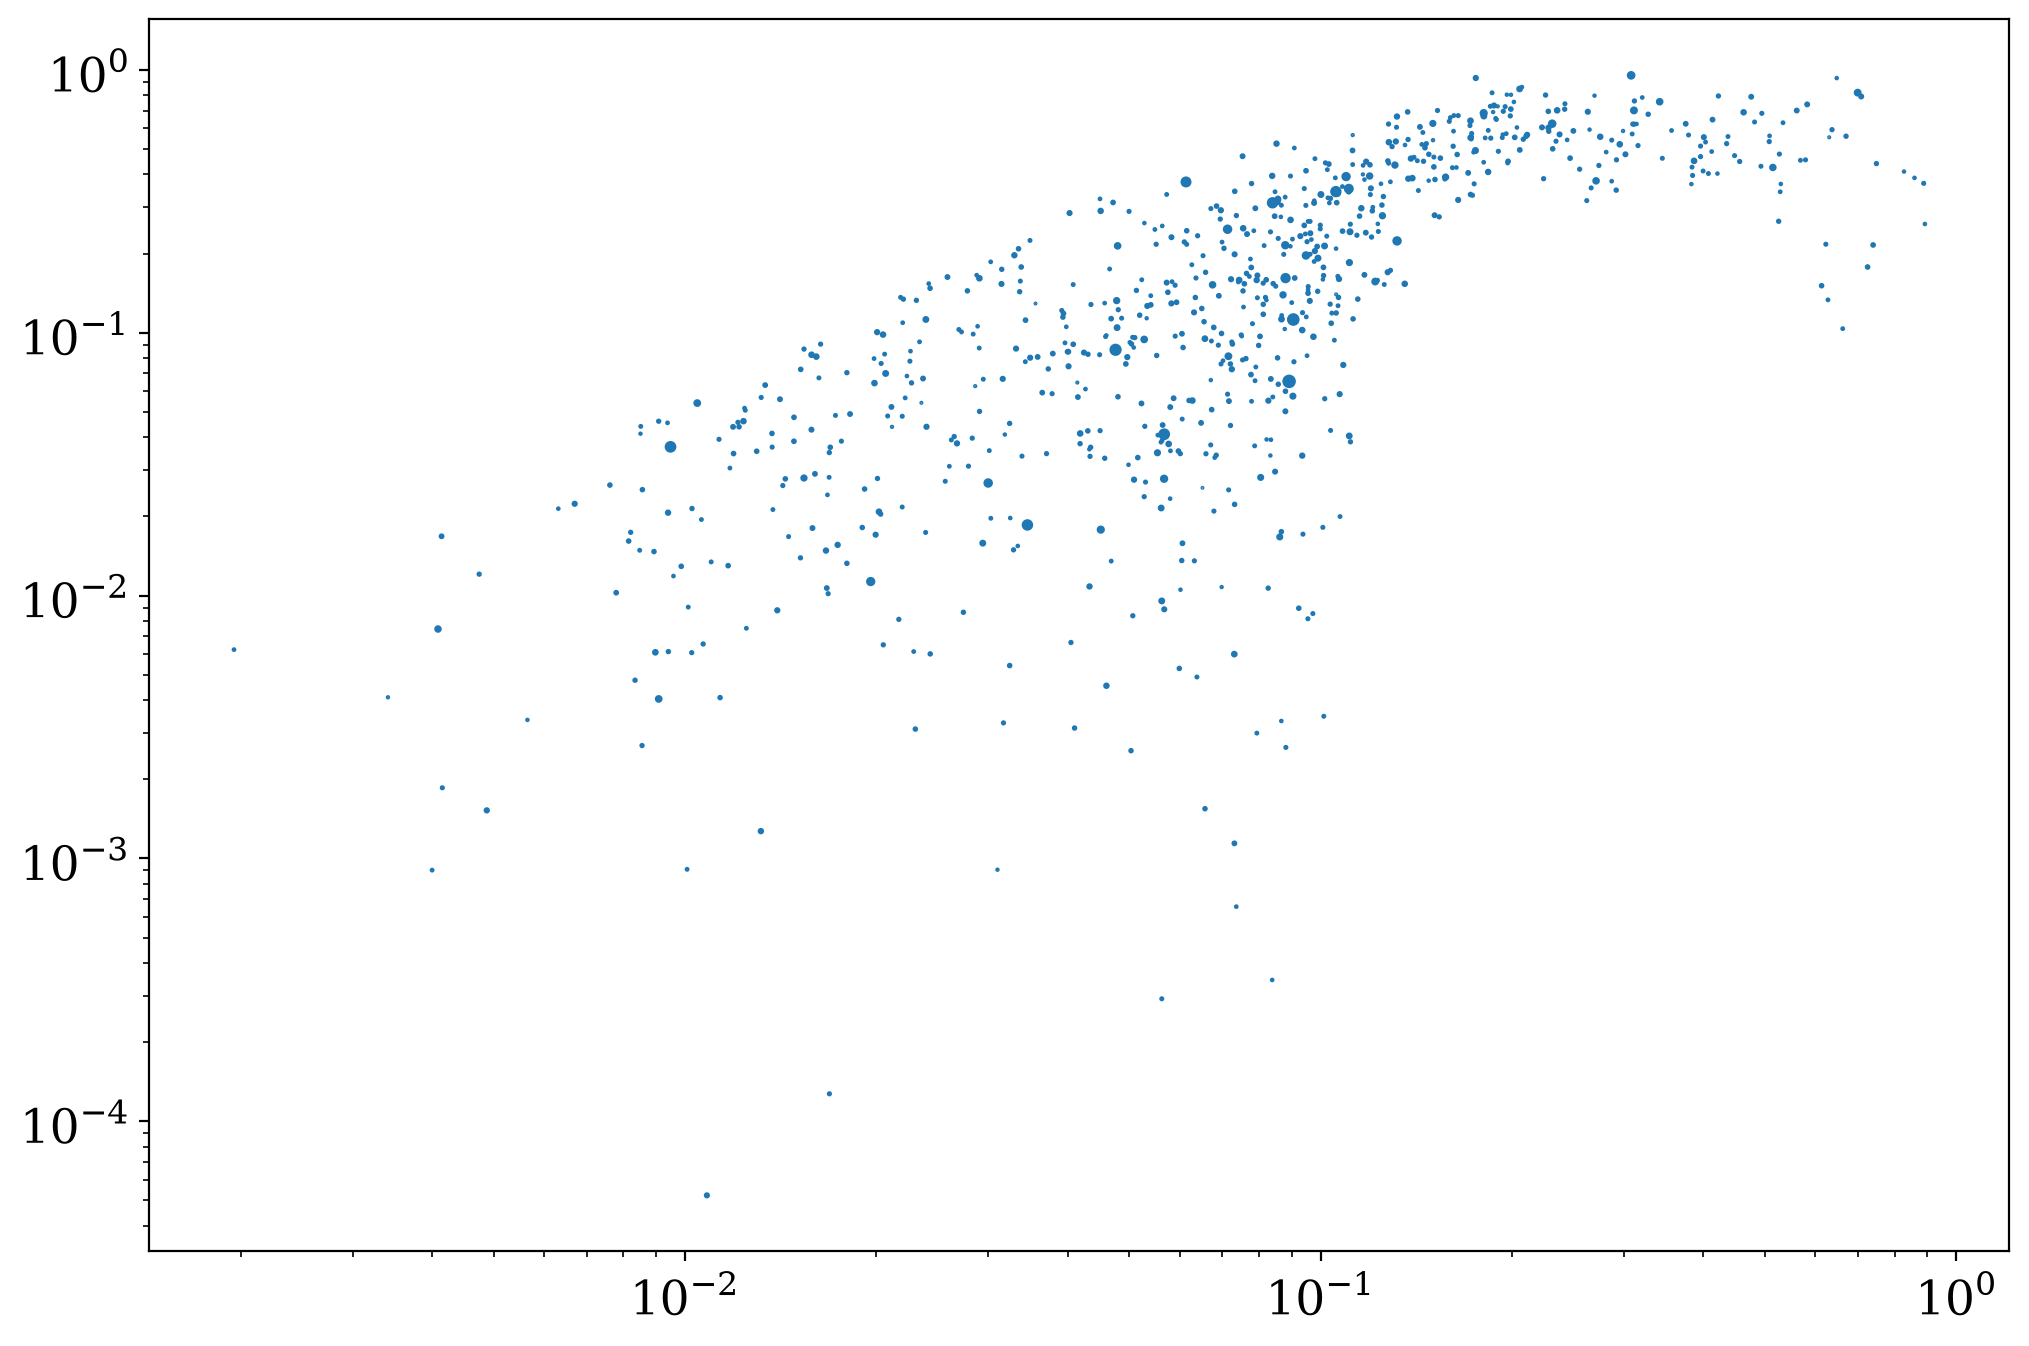

In [157]:
plt.scatter(sources.ecc[min_ratio > 0], min_ratio[min_ratio > 0], s=20 * pop.initC["weights"][min_ratio > 0])
plt.xscale("log")
plt.yscale("log")

In [133]:
snr_ratio - snr_uncertainty > 0.01

array([False, False, False, ..., False, False, False], shape=(40457,))

In [130]:
snr_uncertainty

array([2.00081009, 0.67625843, 0.48317602, ..., 1.15830565, 0.90784628,
       2.5251525 ], shape=(40457,))

In [122]:
np.unique(detectable_harmonics, return_counts=True)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  18,  20,  21,  24,  25,  26,  29,  30,  31,
         32,  34,  35,  38,  39,  40,  77,  86,  94, 104, 111, 119, 122,
        438]),
 array([    4, 26397, 13387,   423,   102,    35,    18,    14,    13,
           21,     1,     1,     1,     1,     2,     3,     2,     3,
            4,     1,     1,     2,     2,     1,     1,     1,     1,
            2,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     2,     1]))

(array([1.51398157e+03, 2.00997843e+02, 4.33131828e+01, 1.57982183e+01,
        9.42439195e+00, 3.98070171e+00, 1.95968241e+00, 1.15113174e+00,
        1.40141247e+00, 7.82763234e-01, 4.63015850e-01, 7.91387956e-01,
        2.86779855e-01, 3.59012173e-01, 3.28290460e-01, 6.28128792e-01,
        2.28431397e-01, 2.70199173e-02, 2.74214888e-01, 2.35491963e-01,
        1.50444793e-01, 1.05450229e-01, 1.31183932e-01, 9.46356100e-02,
        1.34117795e-01, 2.70476790e-01, 2.87050995e-02, 9.25865902e-02,
        9.86890548e-02, 1.15166773e-01, 1.26995257e-01, 1.96843180e-01,
        7.08816876e-02, 7.05811872e-02, 2.35135248e-01, 1.56670347e-01,
        9.65398553e-02, 3.48772758e-02, 0.00000000e+00, 0.00000000e+00,
        1.99241923e-01, 0.00000000e+00, 2.23142217e-02, 2.82655911e-01,
        3.60970219e-01, 0.00000000e+00, 0.00000000e+00, 6.31949301e-01,
        1.74192475e-01]),
 array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
        0.10204082, 0.12244898, 0.14285714

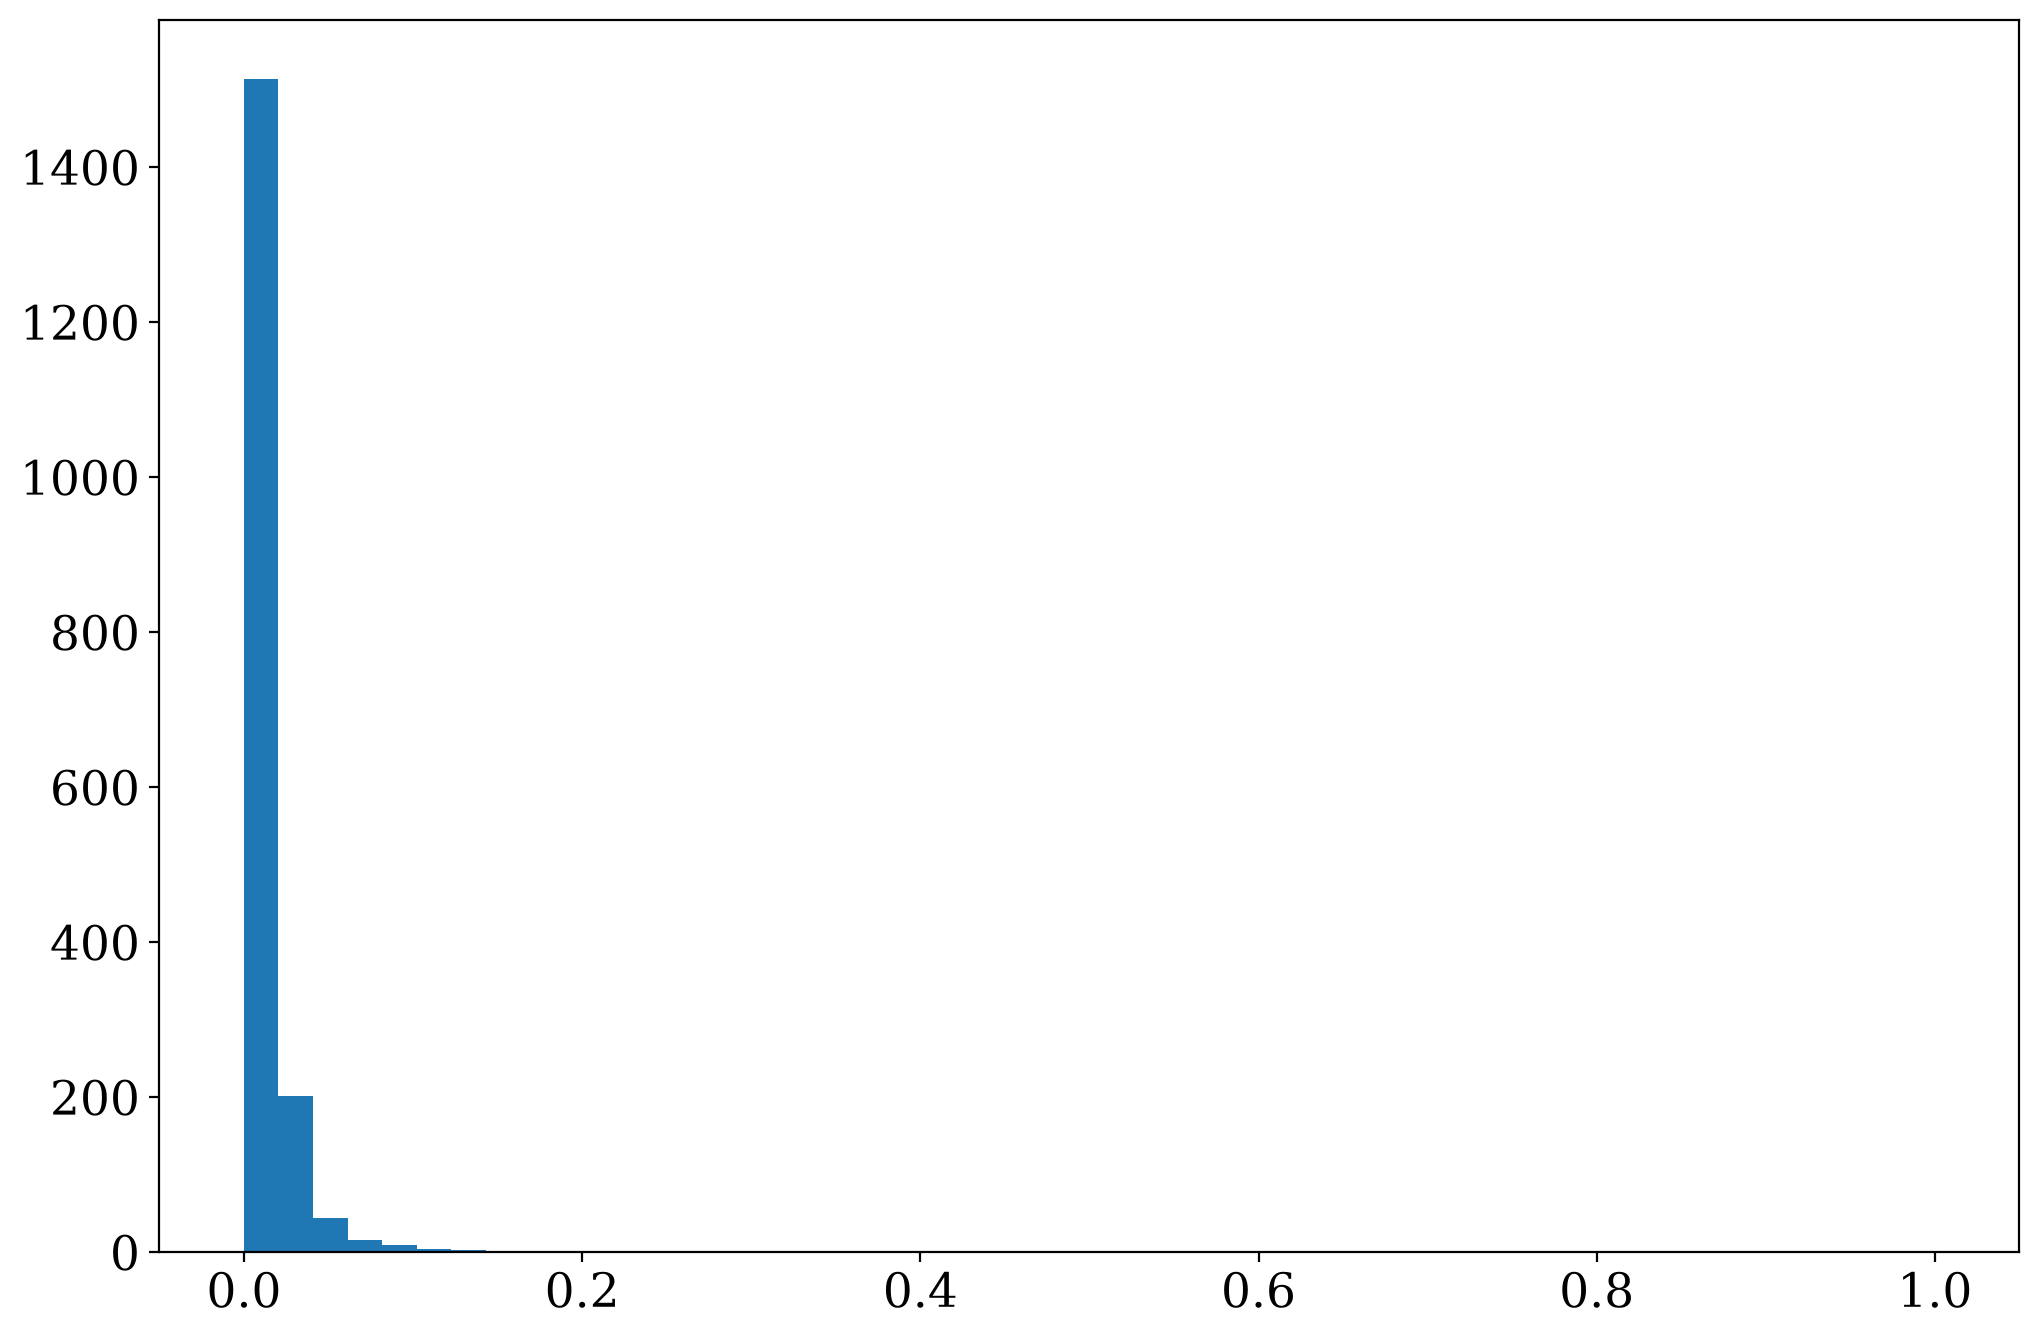

In [129]:
plt.hist(sources.ecc, weights=pop.initC["weights"], bins=np.linspace(0, 1, 50))

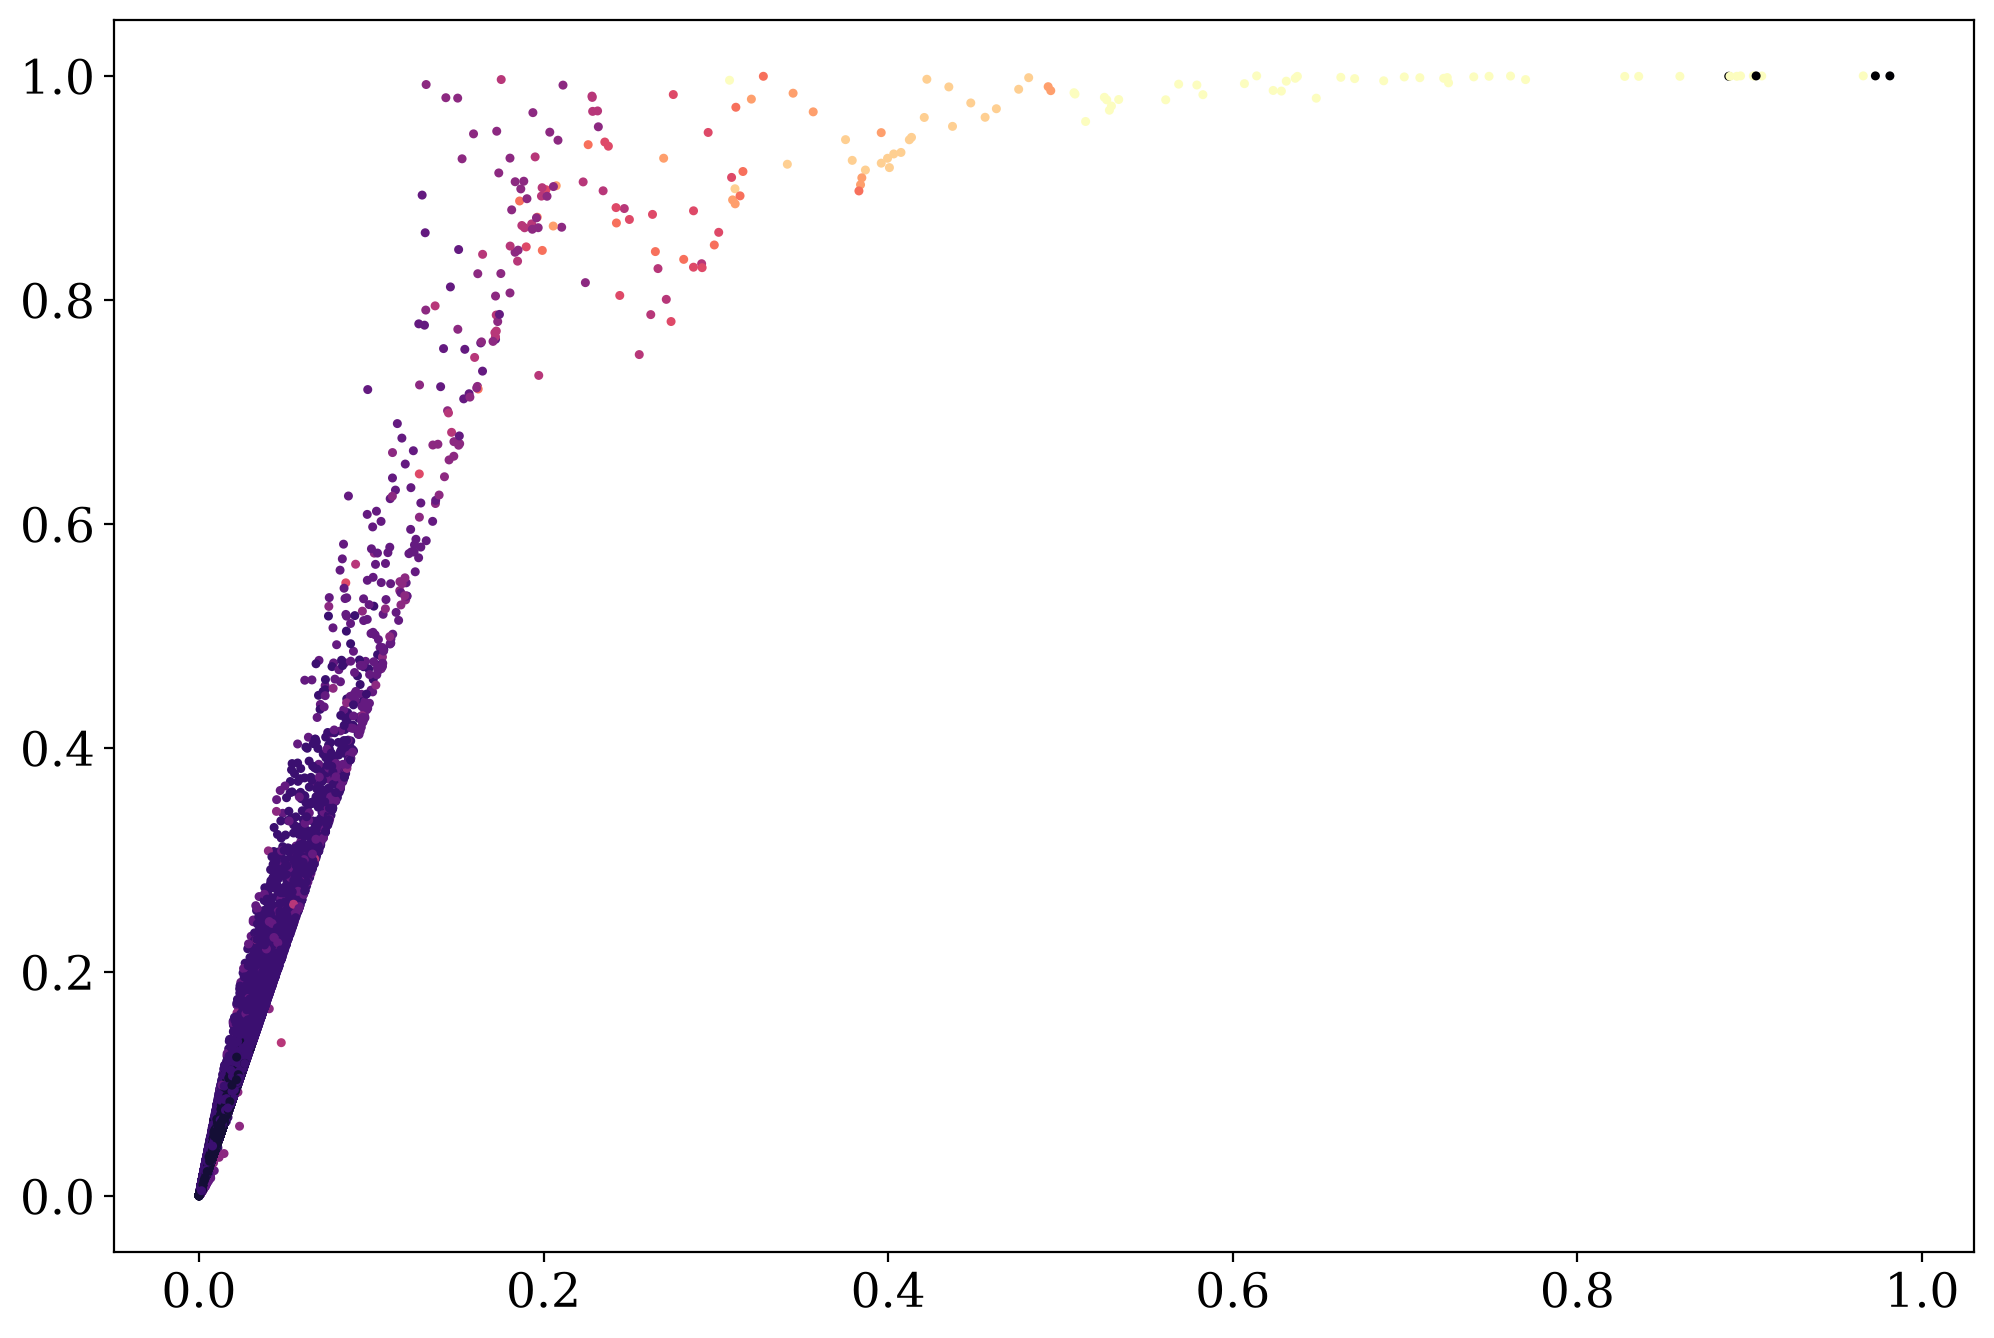

In [125]:
plt.scatter(sources.ecc, p_ecc, c=detectable_harmonics, vmin=0, vmax=10, cmap="magma", s=5)